# IoT Network Intrusion Detection — CNN-LSTM IDS on CICIoT2023
Reproduction of **Gueriani & Kheddar, _Enhancing IoT Security with CNN and LSTM-Based Intrusion Detection Systems_, IEEE PAIS 2024** (DOI 10.1109/PAIS62114.2024.10541178).

Team: Aayushman (231CS105), Ashutosh Kumar (231CS113), Sahil Mengji (231CS151)

Goal: **reproduce and validate** the paper's ~98.42 % accuracy (not novelty).

> **This notebook does not retrain anything.** Training was done by the staged pipeline (`main.py --stage prepare,train,baselines,cv,compare,edge`, see README). Here we load the cached, already split and scaled arrays from `outputs/cache/` and the saved model from `outputs/models/`, re-predict the held-out test set to check that the stored metrics are reproducible, and walk through every figure and table.
>
> To retrain inside the notebook (e.g. on Colab), run the optional cell in section 1 — it calls the same stages.

## 0. Setup
Colab: Runtime → Change runtime type → GPU, upload/clone the project folder and `%cd` into it. Locally on Windows use WSL2 (TensorFlow ≥ 2.11 has no native-Windows GPU build).

In [1]:
import json, os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, Markdown, display
OUT = Path('outputs')
def show(*names):
    for n in names:
        p = OUT / 'figures' / f'{n}.png'
        display(Image(filename=str(p), width=900)) if p.exists() else print('missing:', p)
print(os.getcwd())

/mnt/c/Users/ayush/Desktop/Coding/IDS/iot_ids_cnn_lstm


## 1. Optional: (re)build everything
Skipped by default. Each stage is skipped if its outputs already exist; `--force` redoes it. Training resumes from the last epoch if interrupted.

In [2]:
RUN_PIPELINE = False
if RUN_PIPELINE:
    import main
    main.main(['--stage', 'prepare,train,baselines,cv,compare,edge', '--sample', '1400000'])

## 2. Configuration and run info
Every hyper-parameter is in `config.py`, tagged `[paper]` or `[assumed]`. Only the paper's accuracy (98.42 %) is used as a reference; other paper metrics are left as `None` until checked against the published paper.

In [3]:
from config import Config, PAPER_RESULTS
cfg = Config()
results = json.loads((OUT / 'metrics' / 'results.json').read_text())
print('Paper reference:', {k: v for k, v in PAPER_RESULTS.items() if v is not None})
pd.Series(results['run_info']).to_frame('value')

Paper reference: {'accuracy': 98.42}


,value
synthetic,False
dataset_release,original 2023 release (46 features)
data_dir,/mnt/c/Users/ayush/Desktop/Coding/IDS/iot_ids_...
task,binary
seed,42
sample_rows_requested,1400000
population_rows,7845673
rows_sampled,1399311
rows_after_cleaning,1225709
duplicates_removed,173602


## 3. Load cached arrays + saved model and re-check the test metrics

In [4]:
import keras
from preprocessing import load_cache
from train import predict_proba, setup_gpu
import evaluate as ev
setup_gpu(cfg)
cfg.sample_rows = results['run_info']['sample_rows_requested']  # cache signature must match
data, meta = load_cache(cfg)          # memory-mapped float32 arrays
print({n: getattr(data, n).shape for n in ('X_train', 'X_val', 'X_test')})
model = keras.models.load_model(OUT / 'models' / 'CNN-LSTM.keras')
proba = predict_proba(model, data.X_test)
m = ev.compute_metrics(np.asarray(data.y_test), proba, data.class_names, cfg.threshold)
stored = results['models']['CNN-LSTM']
for k in ('accuracy', 'f1', 'benign_recall', 'mcc', 'roc_auc'):
    print(f'{k:14s} re-computed {m[k]:.6f}   stored {stored[k]:.6f}')
    assert abs(m[k] - stored[k]) < 1e-4, k
print('Stored metrics reproduced from the saved model.')

{'X_train': (857995, 41), 'X_val': (183857, 41), 'X_test': (183857, 41)}


I0000 00:00:1790647758.011661     596 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


accuracy       re-computed 0.987447   stored 0.987447
f1             re-computed 0.993510   stored 0.993510
benign_recall  re-computed 0.998363   stored 0.998363
mcc            re-computed 0.818370   stored 0.818370
roc_auc        re-computed 0.997749   stored 0.997749
Stored metrics reproduced from the saved model.


## 4. Data exploration (Figs 1–5)
Leakage-safe preprocessing: exact duplicates dropped *before* splitting; inf→NaN; NaN rows dropped (<1 %) or train-median imputed; constant columns found on train only; MinMax scaler, imputer and class weights fitted on train only; stratified 70/15/15 split (`test_leakage.py` asserts this). About 97 % of traffic is malicious (Fig 1), which is why accuracy alone is misleading.

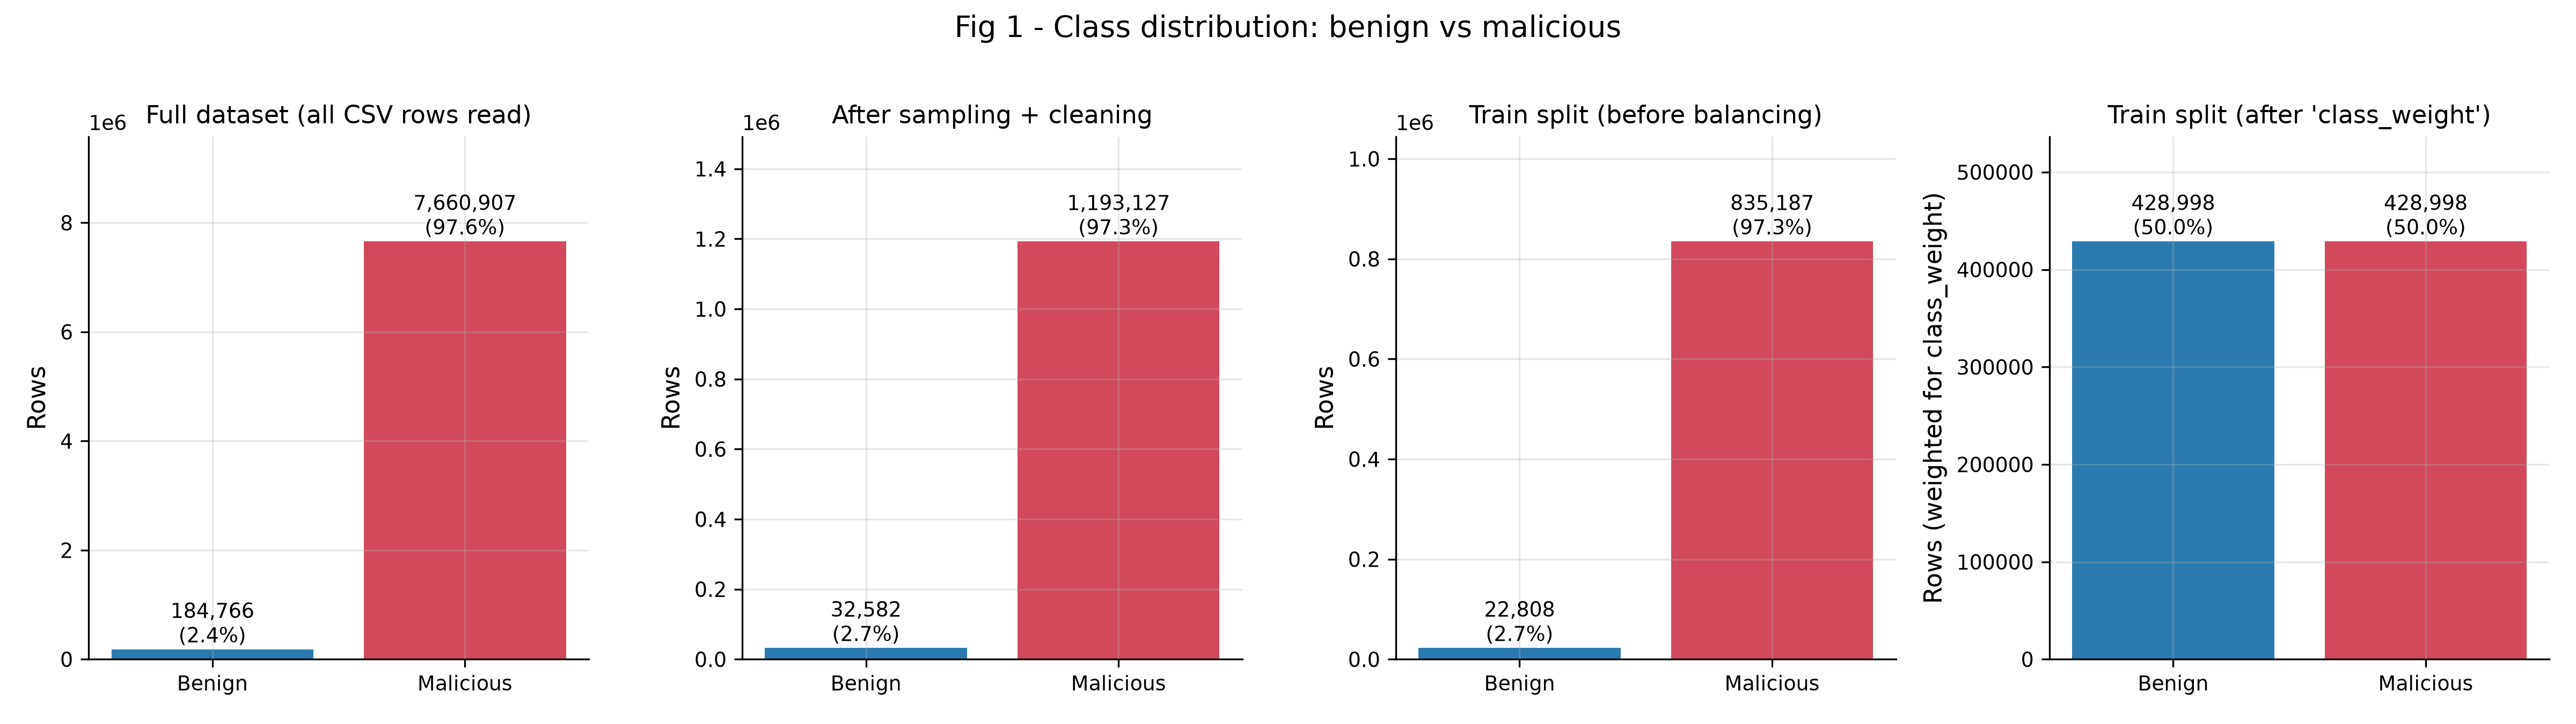

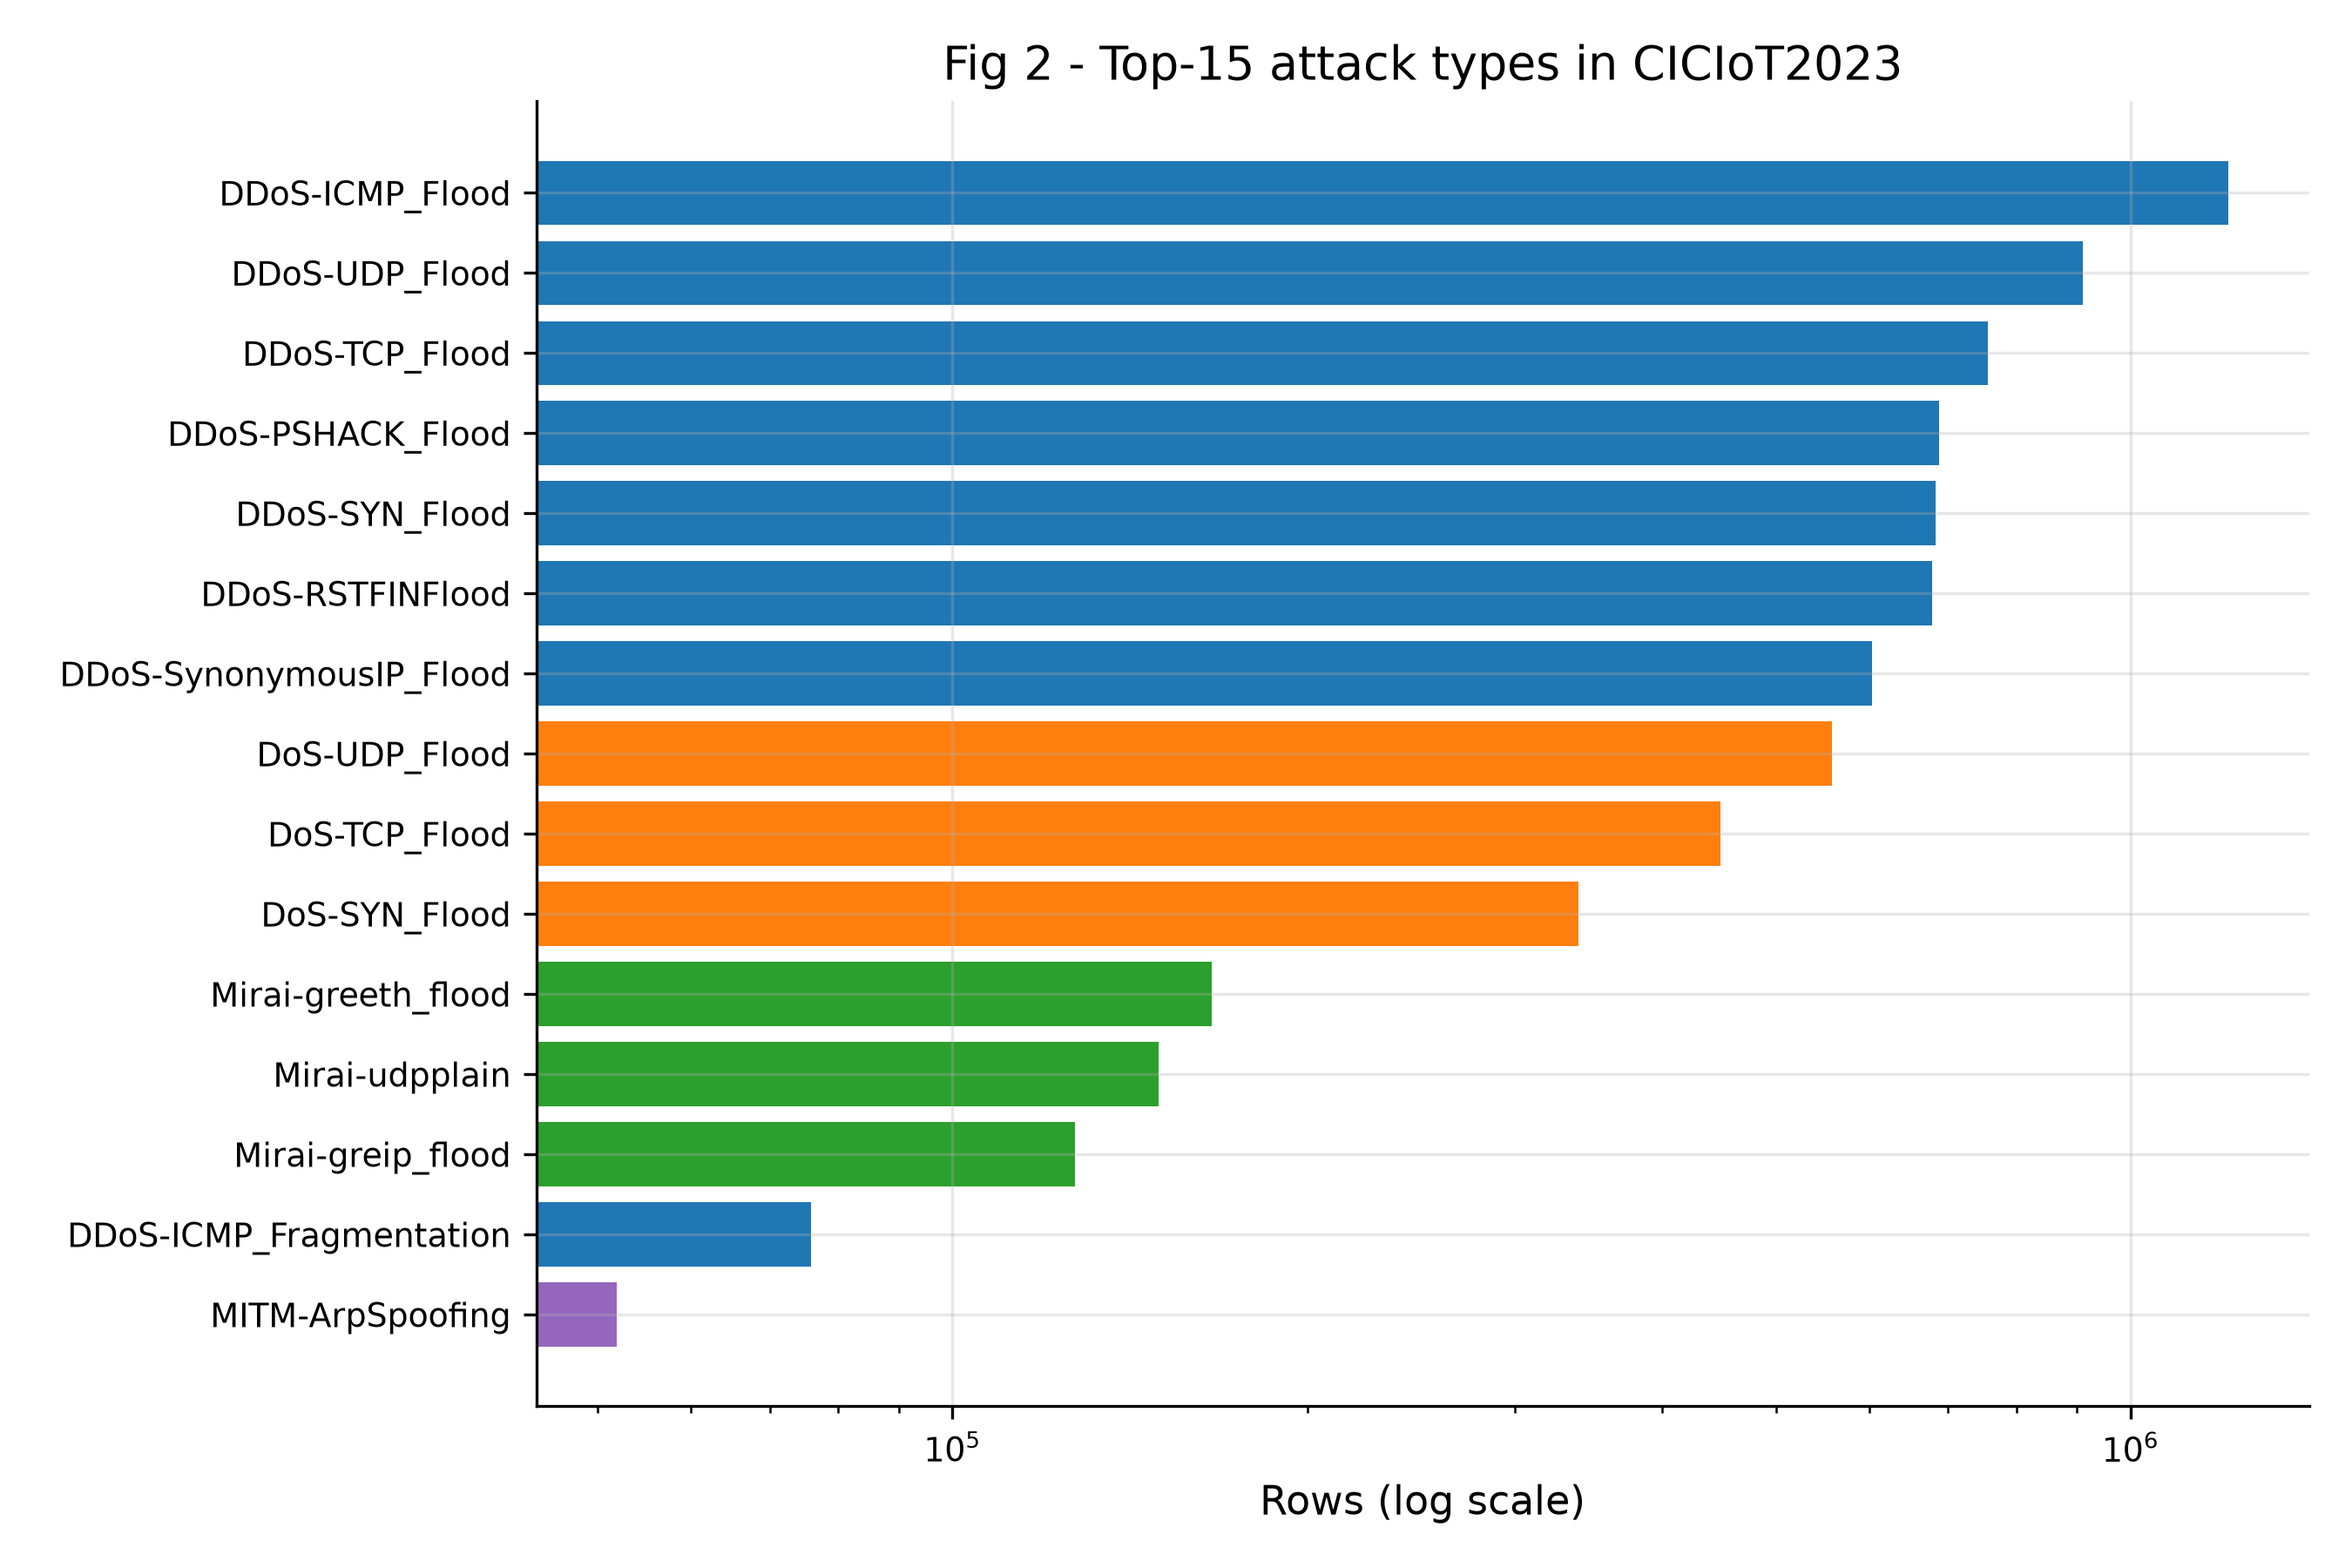

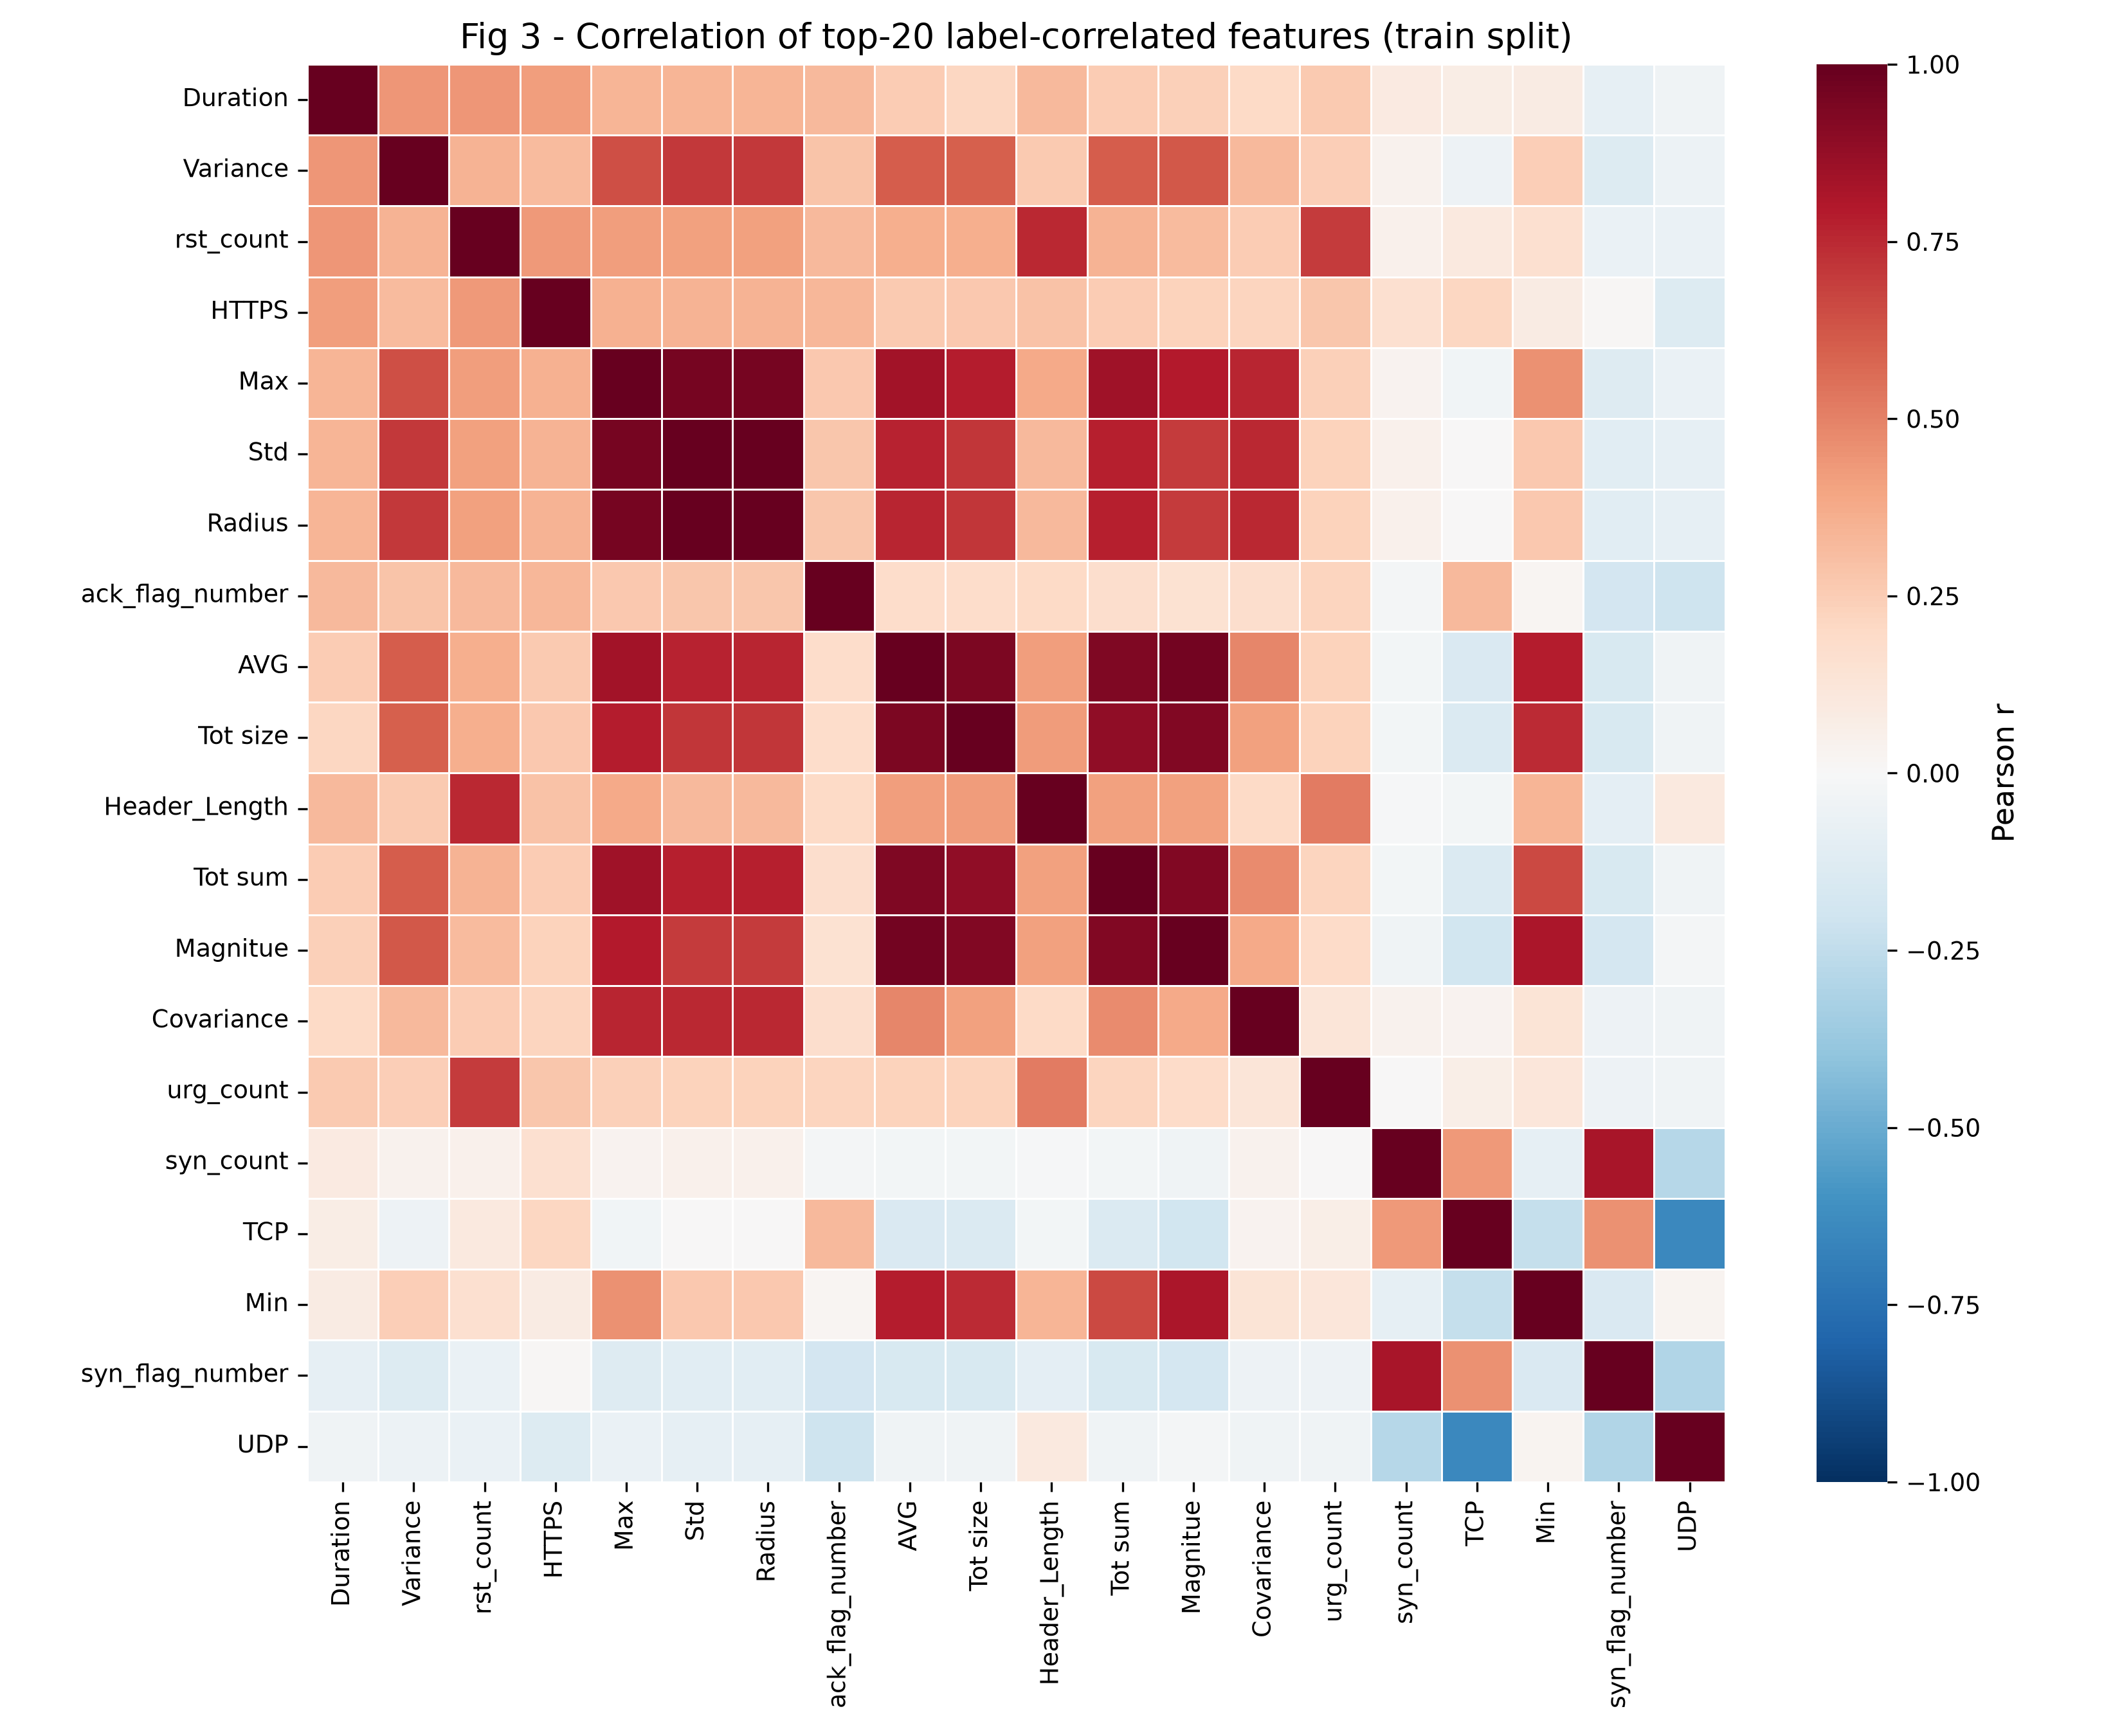

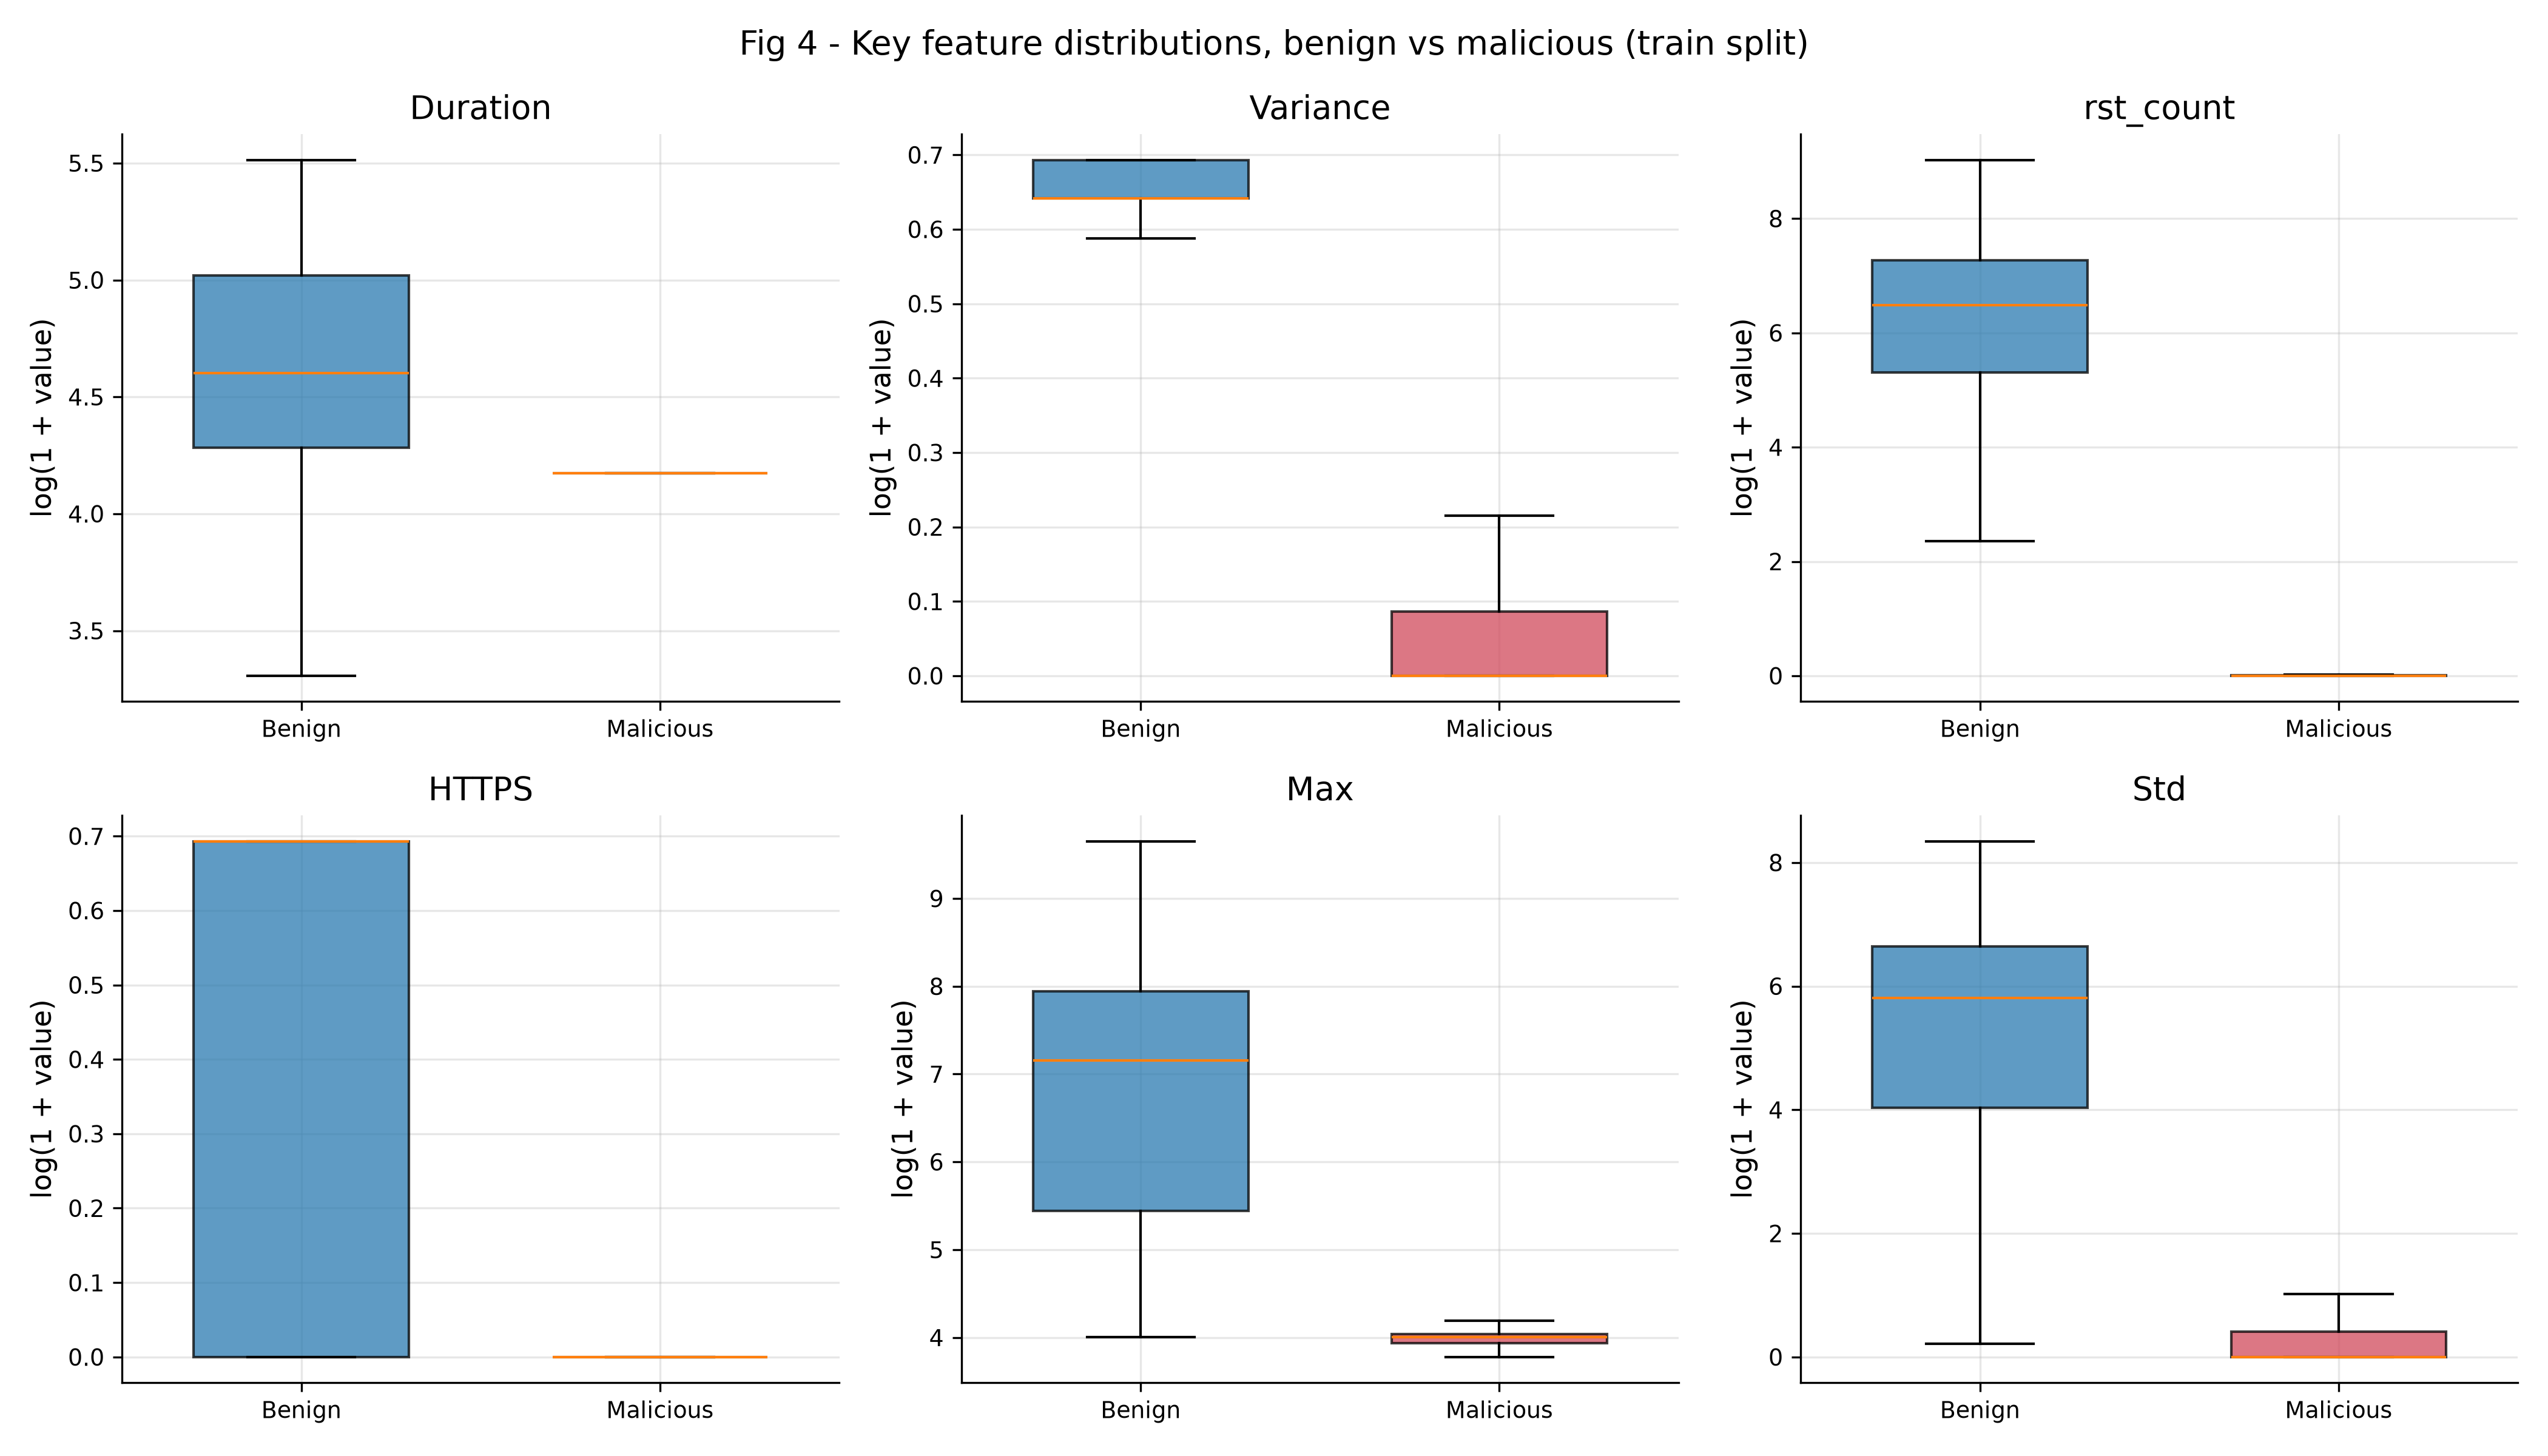

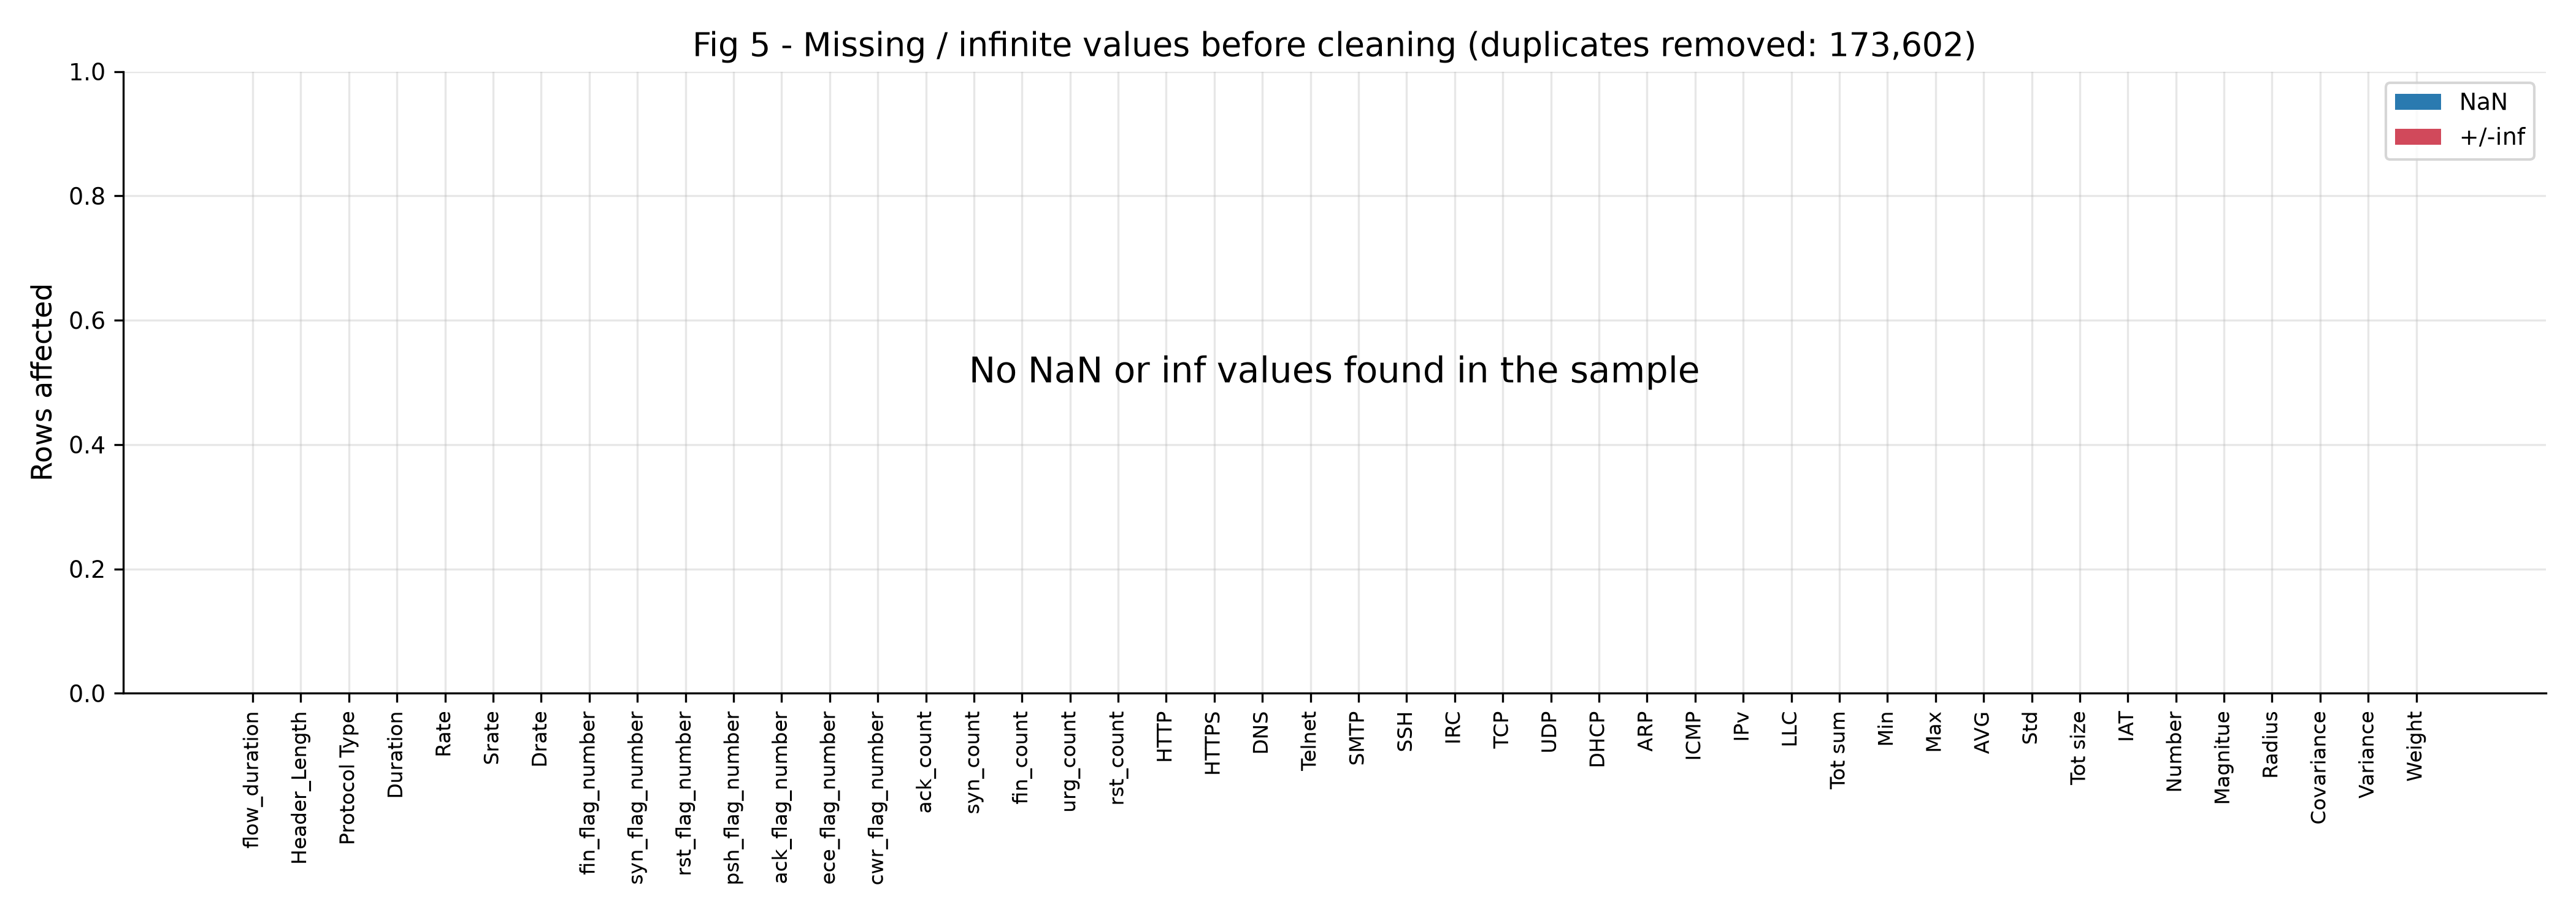

In [5]:
show('01_class_distribution', '02_top15_attack_types', '03_feature_correlation', '04_feature_boxplots', '05_missing_inf_summary')

## 5. Model — CNN-LSTM as drawn in the paper's Fig. 2
Conv1D(64,k3) → BN → AvgPool → Conv1D(64,k3) → AvgPool → Flatten → Dense32 → Dense16, then (a) Dense(2, softmax) and (b) Reshape(16,1) → LSTM(64) → LSTM(64) → Dense(2, sigmoid), concatenated → Dense(2, softmax). Pooling size, activations, batch size and learning rate are assumptions (see README).

In [6]:
print((OUT / 'metrics' / 'model_summary.txt').read_text())

Model: "CNN-LSTM"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━
┃ Layer (type)                   ┃ Output Shape              ┃          Param # 
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━
│ features (InputLayer)          │ (None, 41, 1)             │                0 
├────────────────────────────────┼───────────────────────────┼──────────────────
│ conv1 (Conv1D)                 │ (None, 39, 64)            │              256 
├────────────────────────────────┼───────────────────────────┼──────────────────
│ bn1 (BatchNormalization)       │ (None, 39, 64)            │              256 
├────────────────────────────────┼───────────────────────────┼──────────────────
│ avgpool1 (AveragePooling1D)    │ (None, 19, 64)            │                0 
├────────────────────────────────┼───────────────────────────┼──────────────────
│ conv2 (Conv1D)                 │ (None, 17, 64)            │           12,352 
├─────────

## 6. Training behaviour (Figs 6–8)

In [7]:
pd.read_csv(OUT / 'metrics' / 'history_CNN-LSTM.csv').round(5)

,epoch,accuracy,learning_rate,loss,lr,val_accuracy,val_loss
0,0,0.97262,0.00100,0.12390,0.00100,0.98085,0.07507
1,1,0.98122,0.00100,0.04781,0.00100,0.98081,0.07467
2,2,0.98141,0.00100,0.04624,0.00100,0.98132,0.07236
3,3,0.98114,0.00100,0.04737,0.00100,0.98125,0.07065
4,4,0.98150,0.00100,0.04369,0.00100,0.98119,0.07507
5,5,0.98252,0.00100,0.04180,0.00100,0.98392,0.05769
6,6,0.98346,0.00100,0.04009,0.00100,0.98398,0.06169
7,7,0.98415,0.00100,0.03873,0.00100,0.98297,0.06253
8,8,0.98520,0.00050,0.03561,0.00050,0.98591,0.05016
9,9,0.98564,0.00050,0.03453,0.00050,0.98587,0.05551


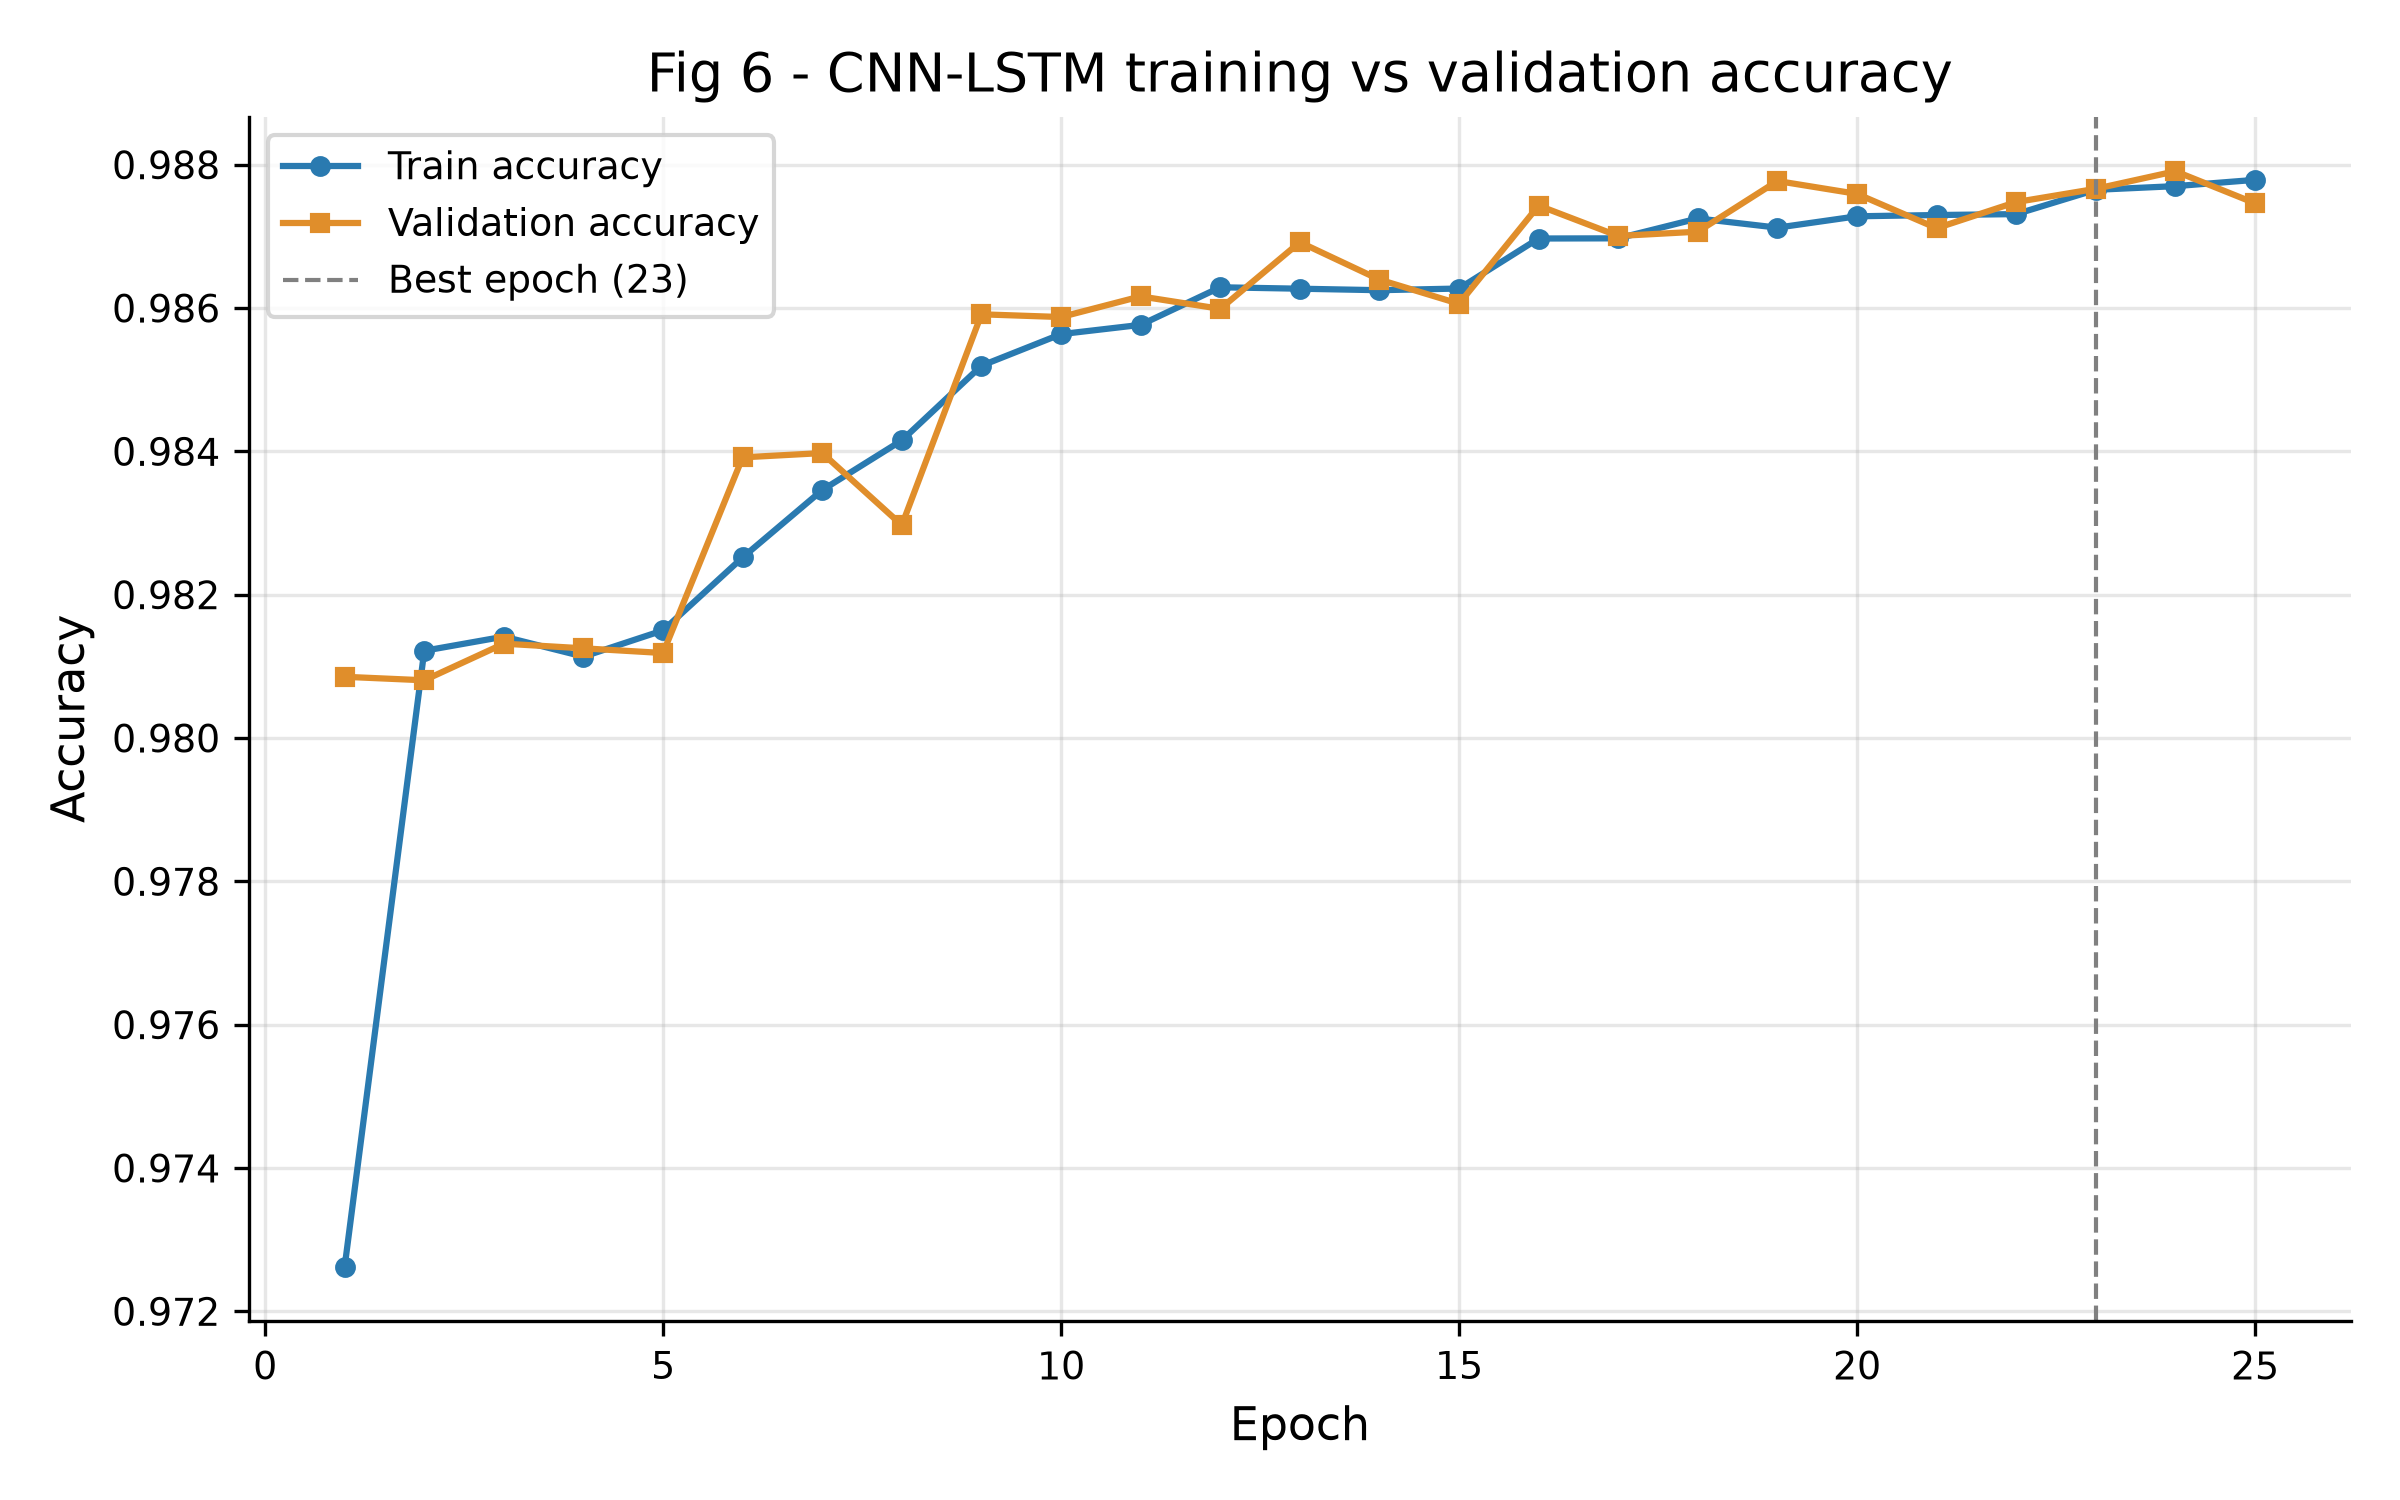

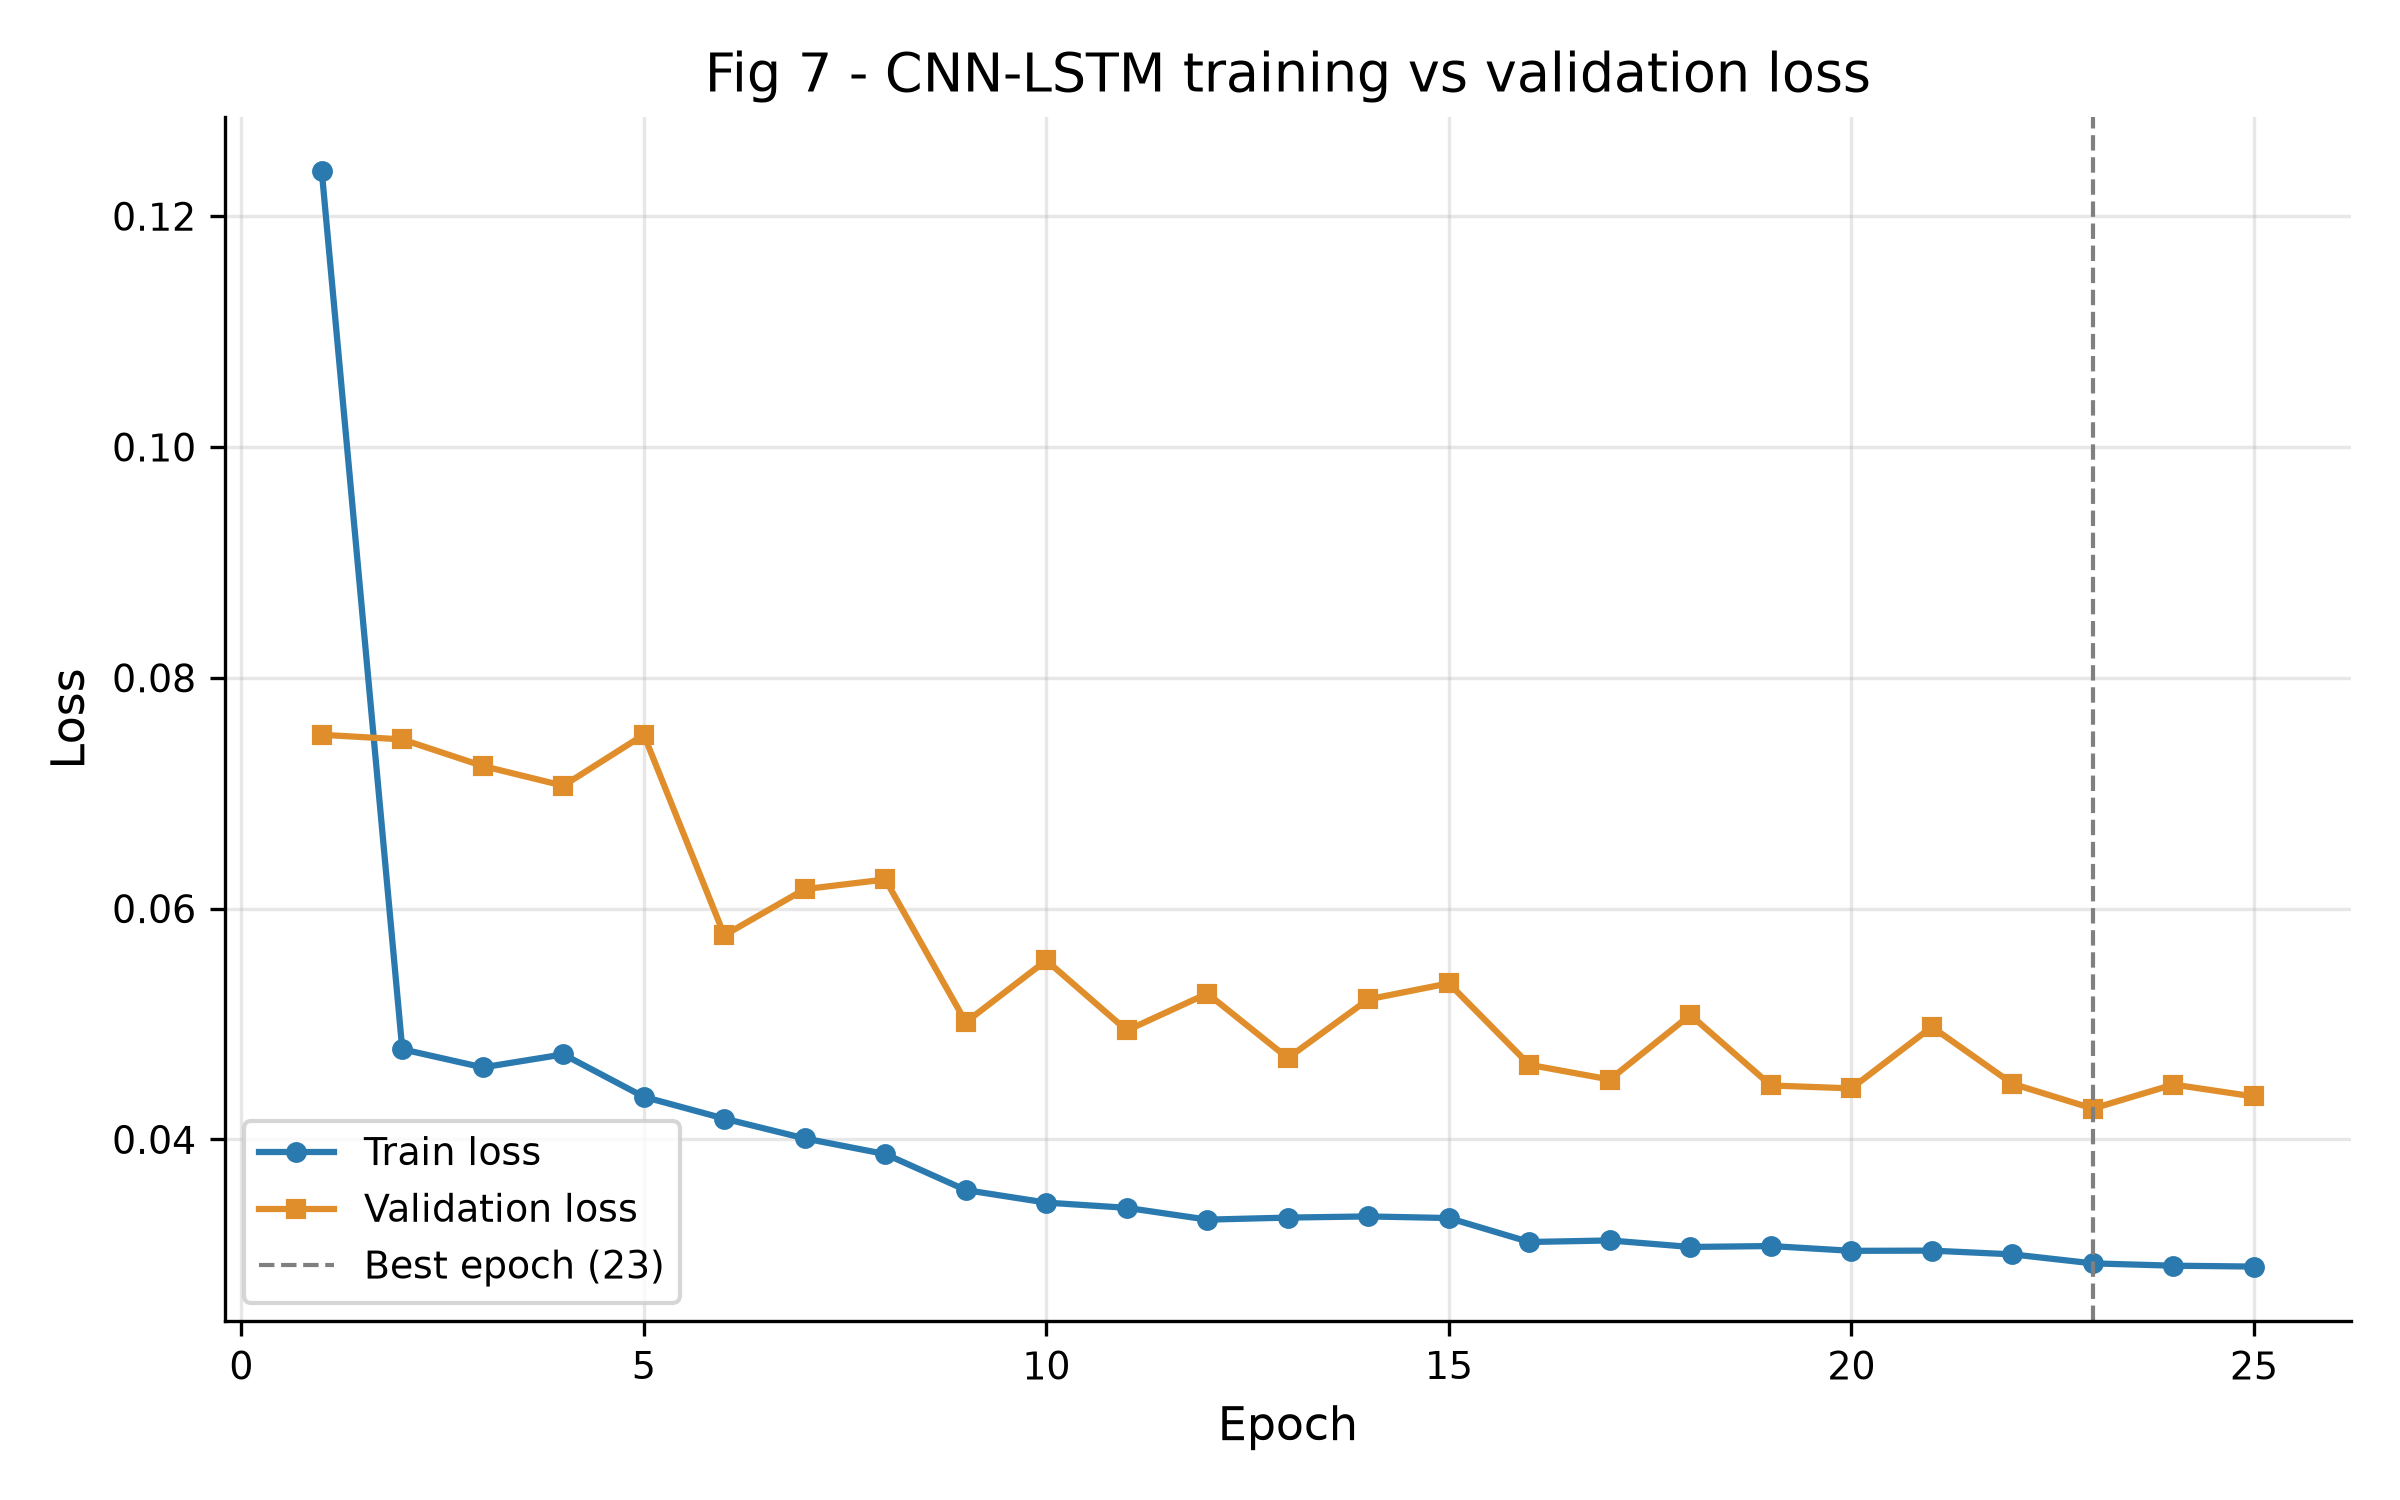

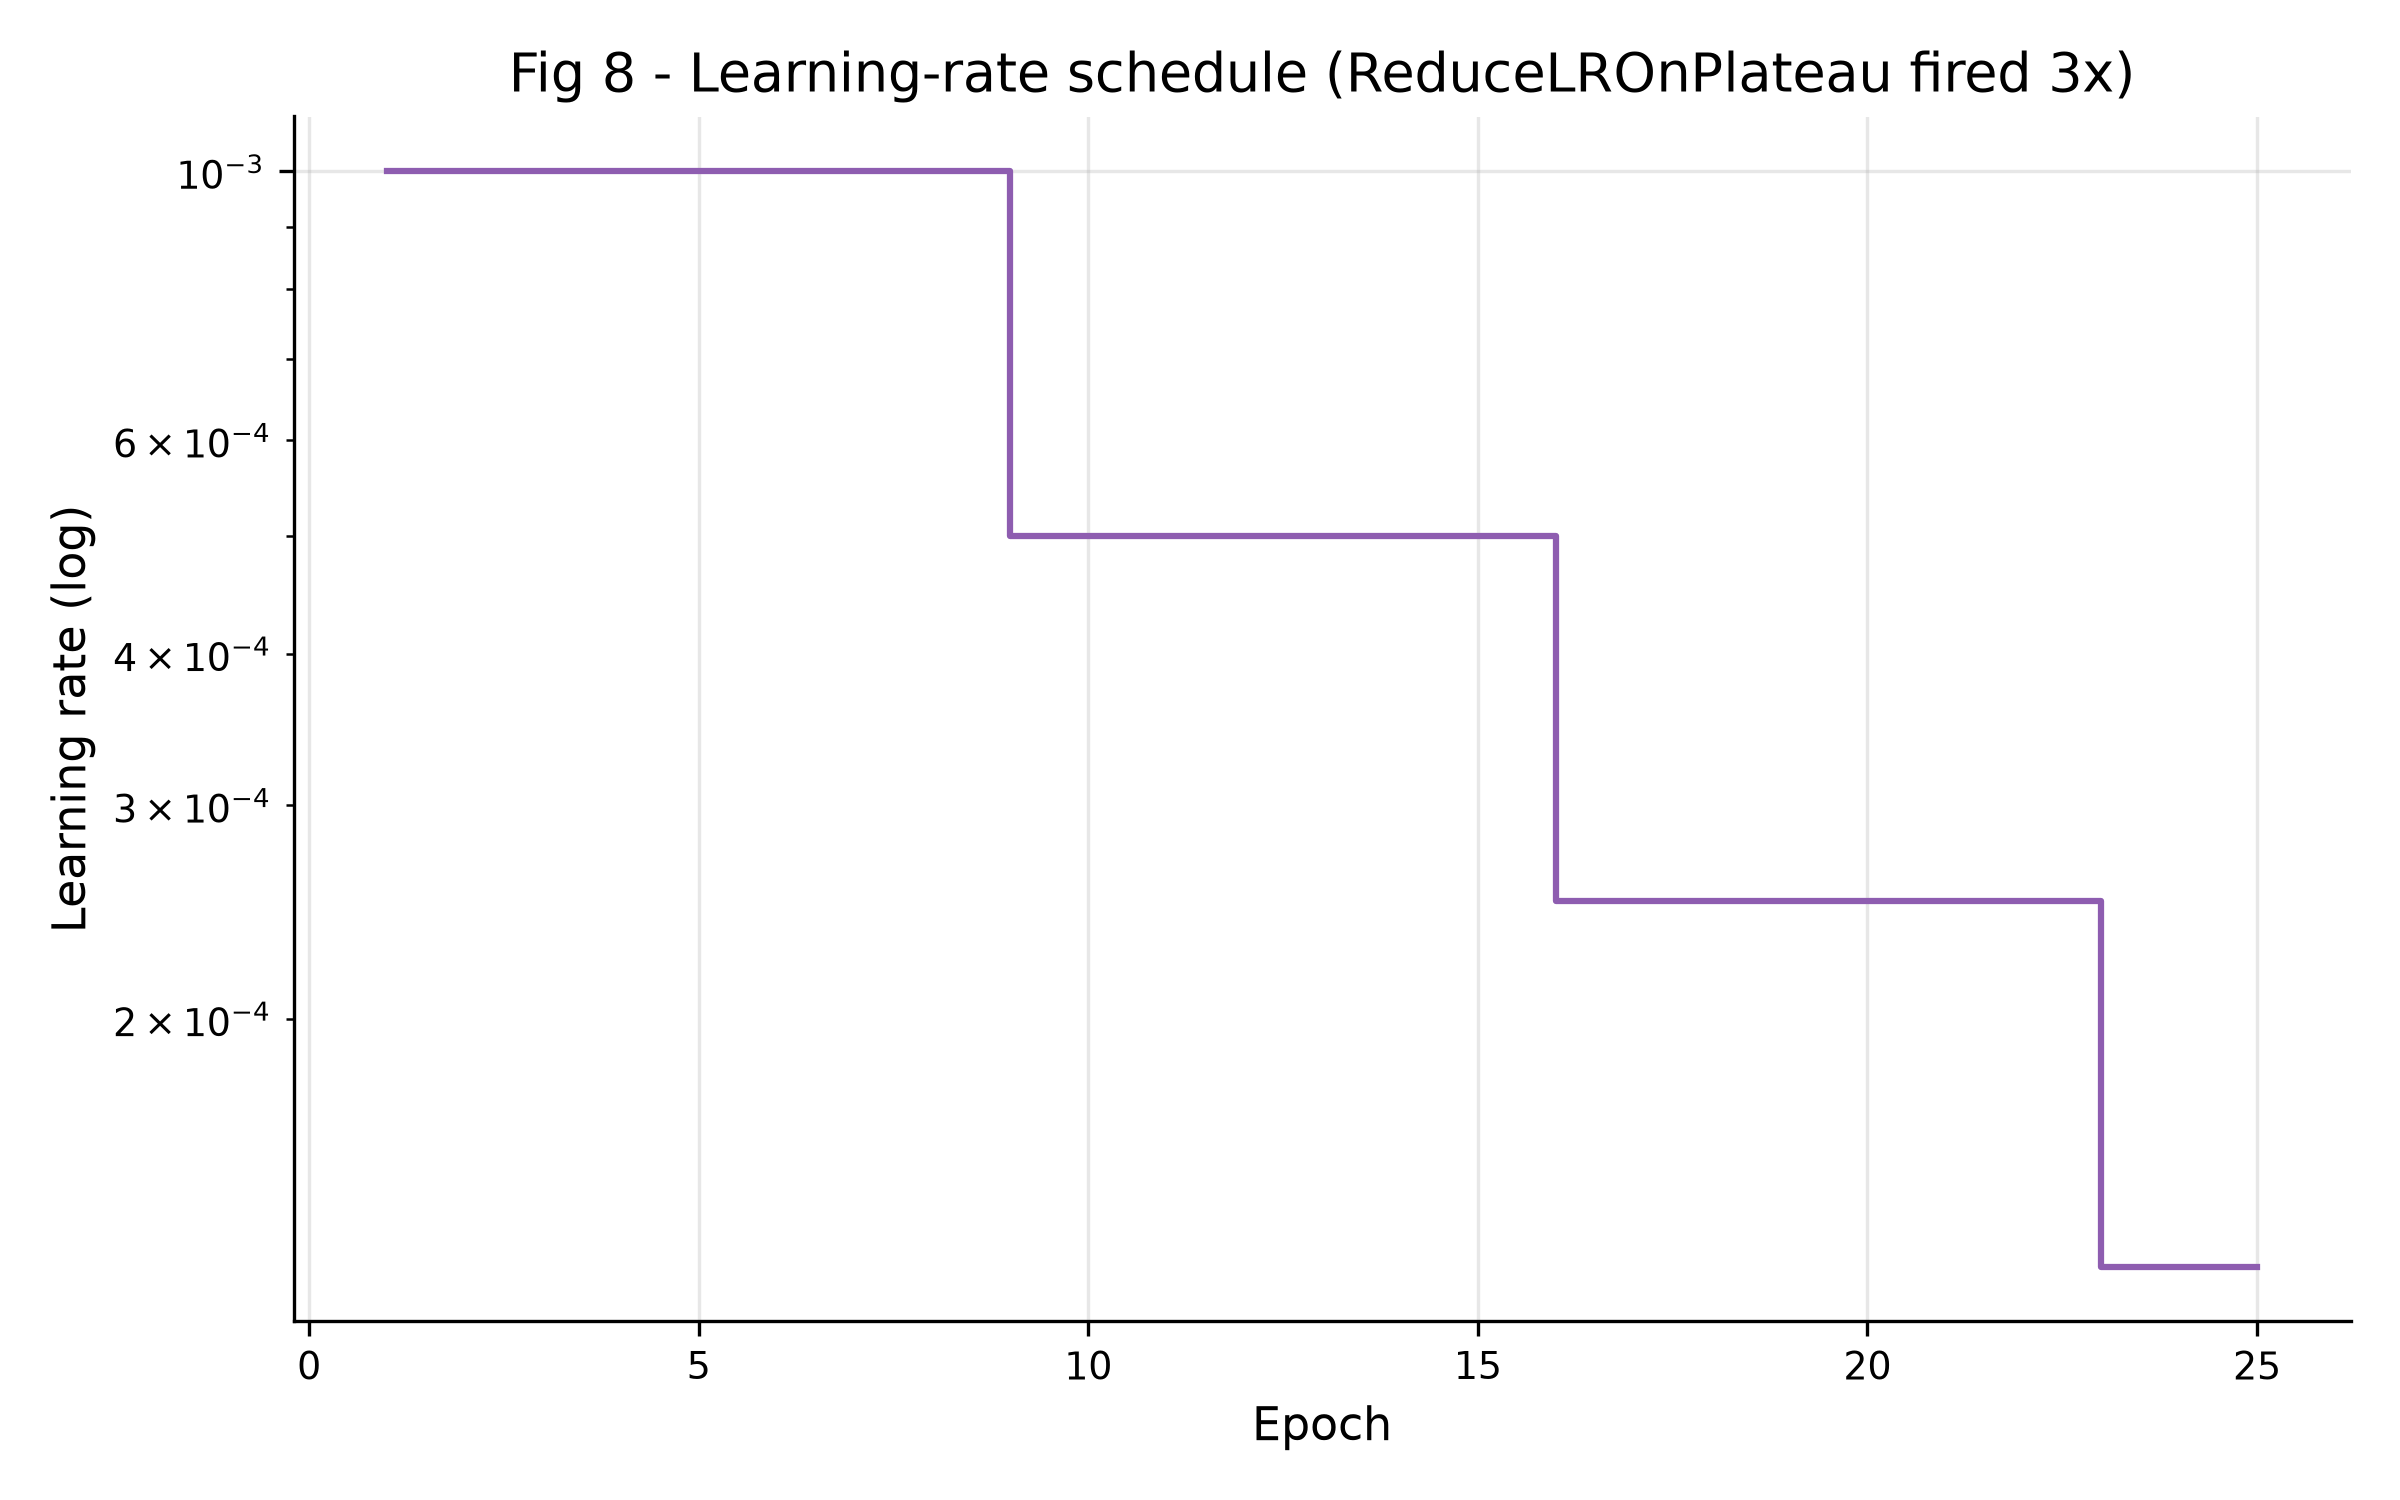

In [8]:
show('06_training_accuracy', '07_training_loss', '08_learning_rate')

## 7. Test-set performance (Figs 9–15)
Positive class = malicious. Because ~97 % of rows are attacks, look at the **benign** metrics, FPR, MCC and PR-AUC, and compare against the *always-malicious* baseline row.

In [9]:
cols = ['accuracy', 'precision', 'recall', 'f1', 'benign_precision', 'benign_recall', 'benign_f1',
        'fpr', 'fnr', 'mcc', 'roc_auc', 'pr_auc', 'tp', 'tn', 'fp', 'fn']
pd.DataFrame(results['models']).T[cols].loc[['CNN-LSTM', ev.MAJORITY]]

,accuracy,precision,recall,f1,benign_precision,benign_recall,benign_f1,fpr,fnr,mcc,roc_auc,pr_auc,tp,tn,fp,fn
CNN-LSTM,0.987447,0.999955,0.987149,0.99351,0.679621,0.998363,0.808719,0.001637,0.012851,0.81837,0.997749,0.999939,176670,4879,8,2300
Majority (always malicious),0.97342,0.97342,1.0,0.986531,0.0,0.0,0.0,1.0,0.0,0.0,0.5,0.97342,178970.0,0.0,4887.0,0.0


In [10]:
print((OUT / 'metrics' / 'classification_report_CNN-LSTM.txt').read_text())

              precision    recall  f1-score   support

      Benign     0.6796    0.9984    0.8087      4887
   Malicious     1.0000    0.9871    0.9935    178970

    accuracy                         0.9874    183857
   macro avg     0.8398    0.9928    0.9011    183857
weighted avg     0.9914    0.9874    0.9886    183857



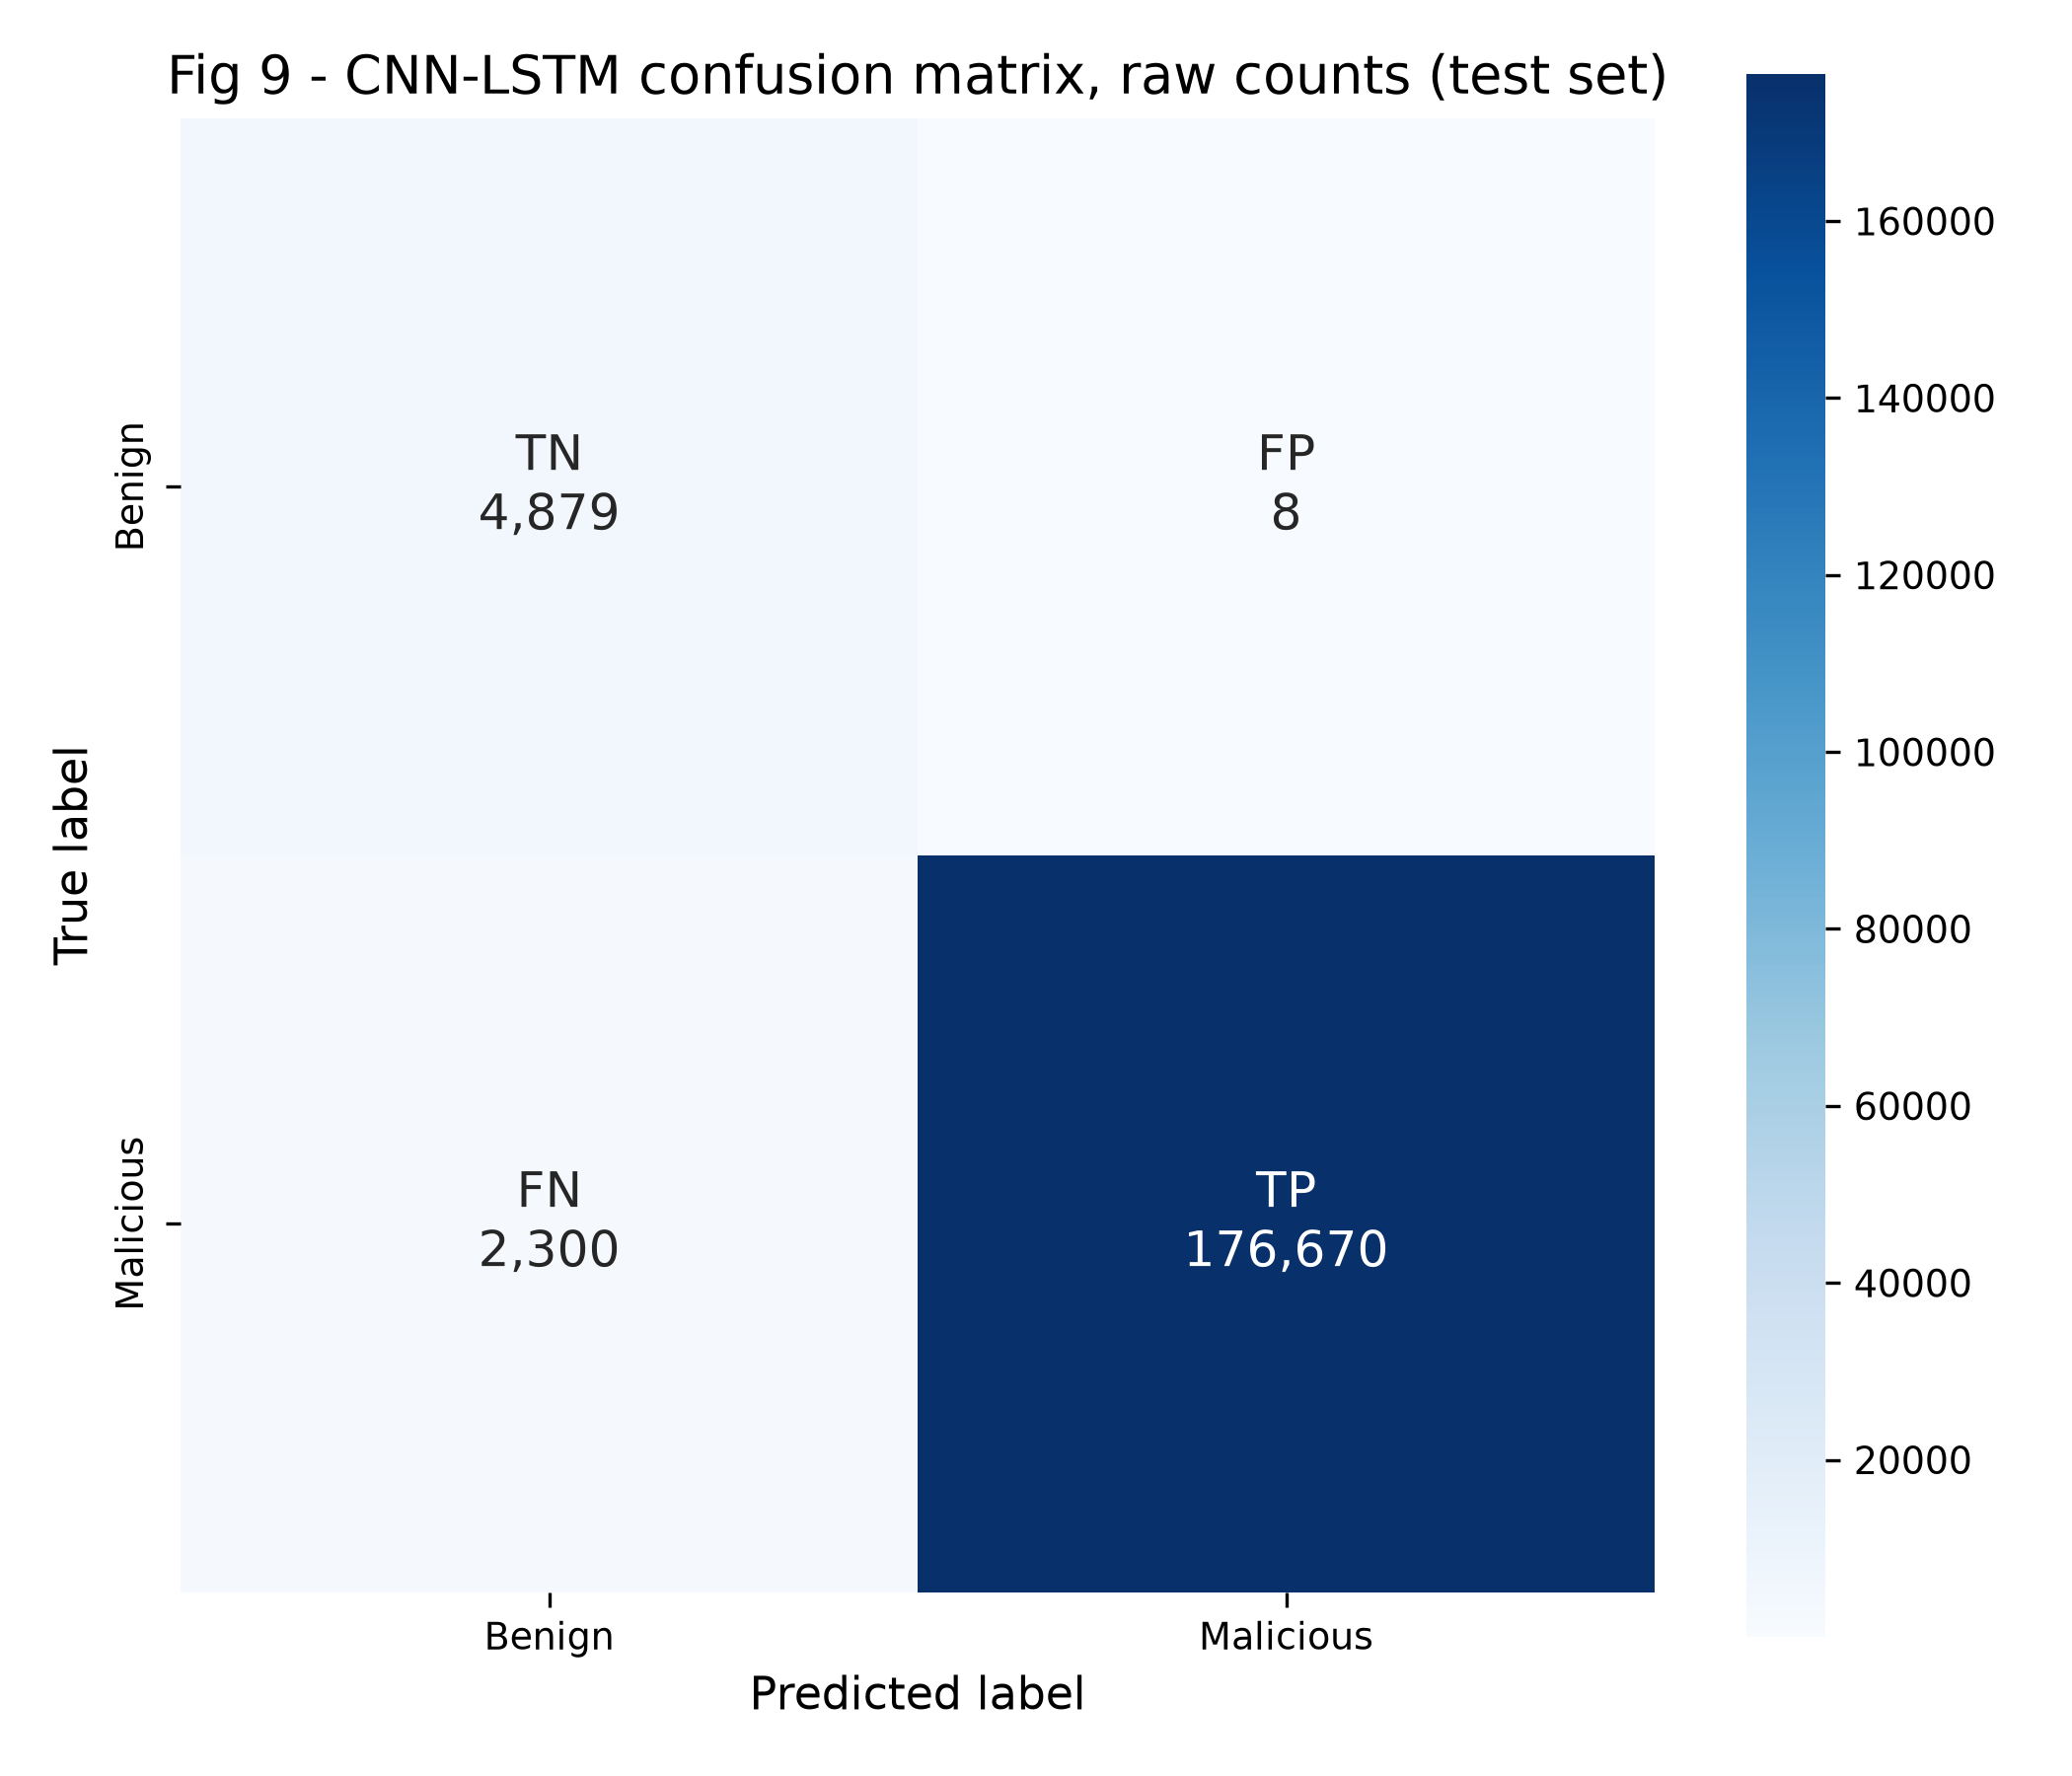

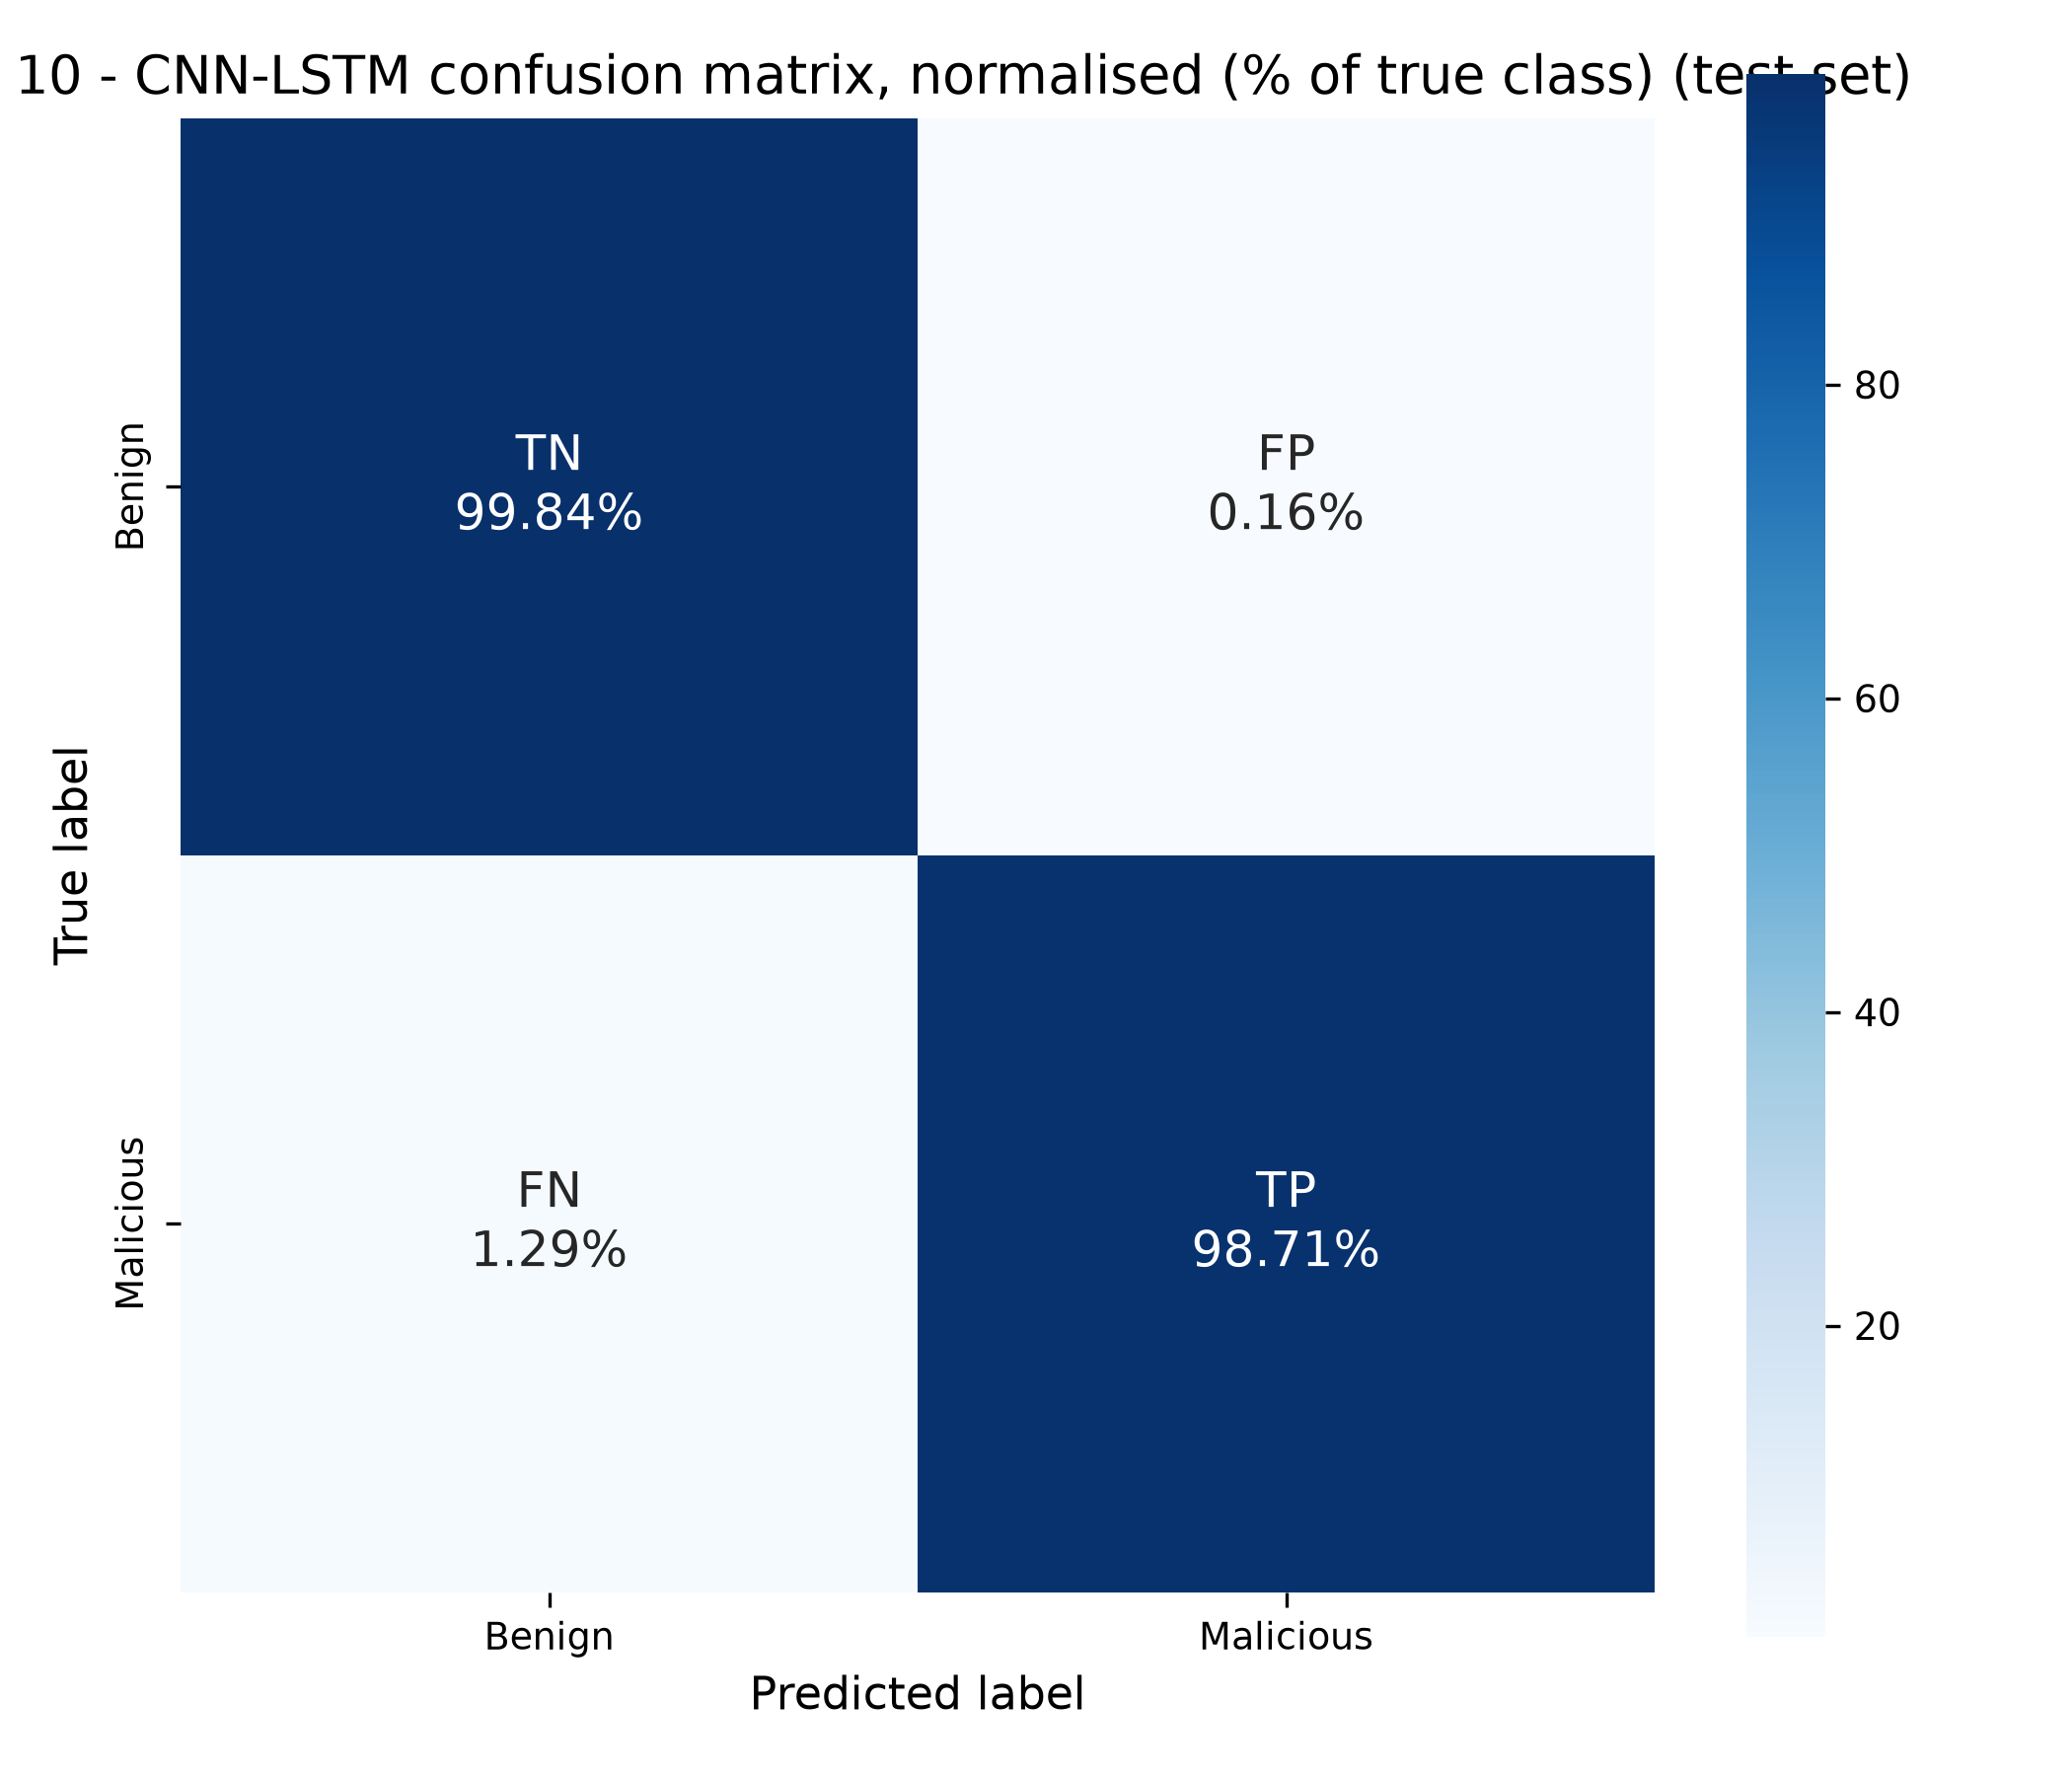

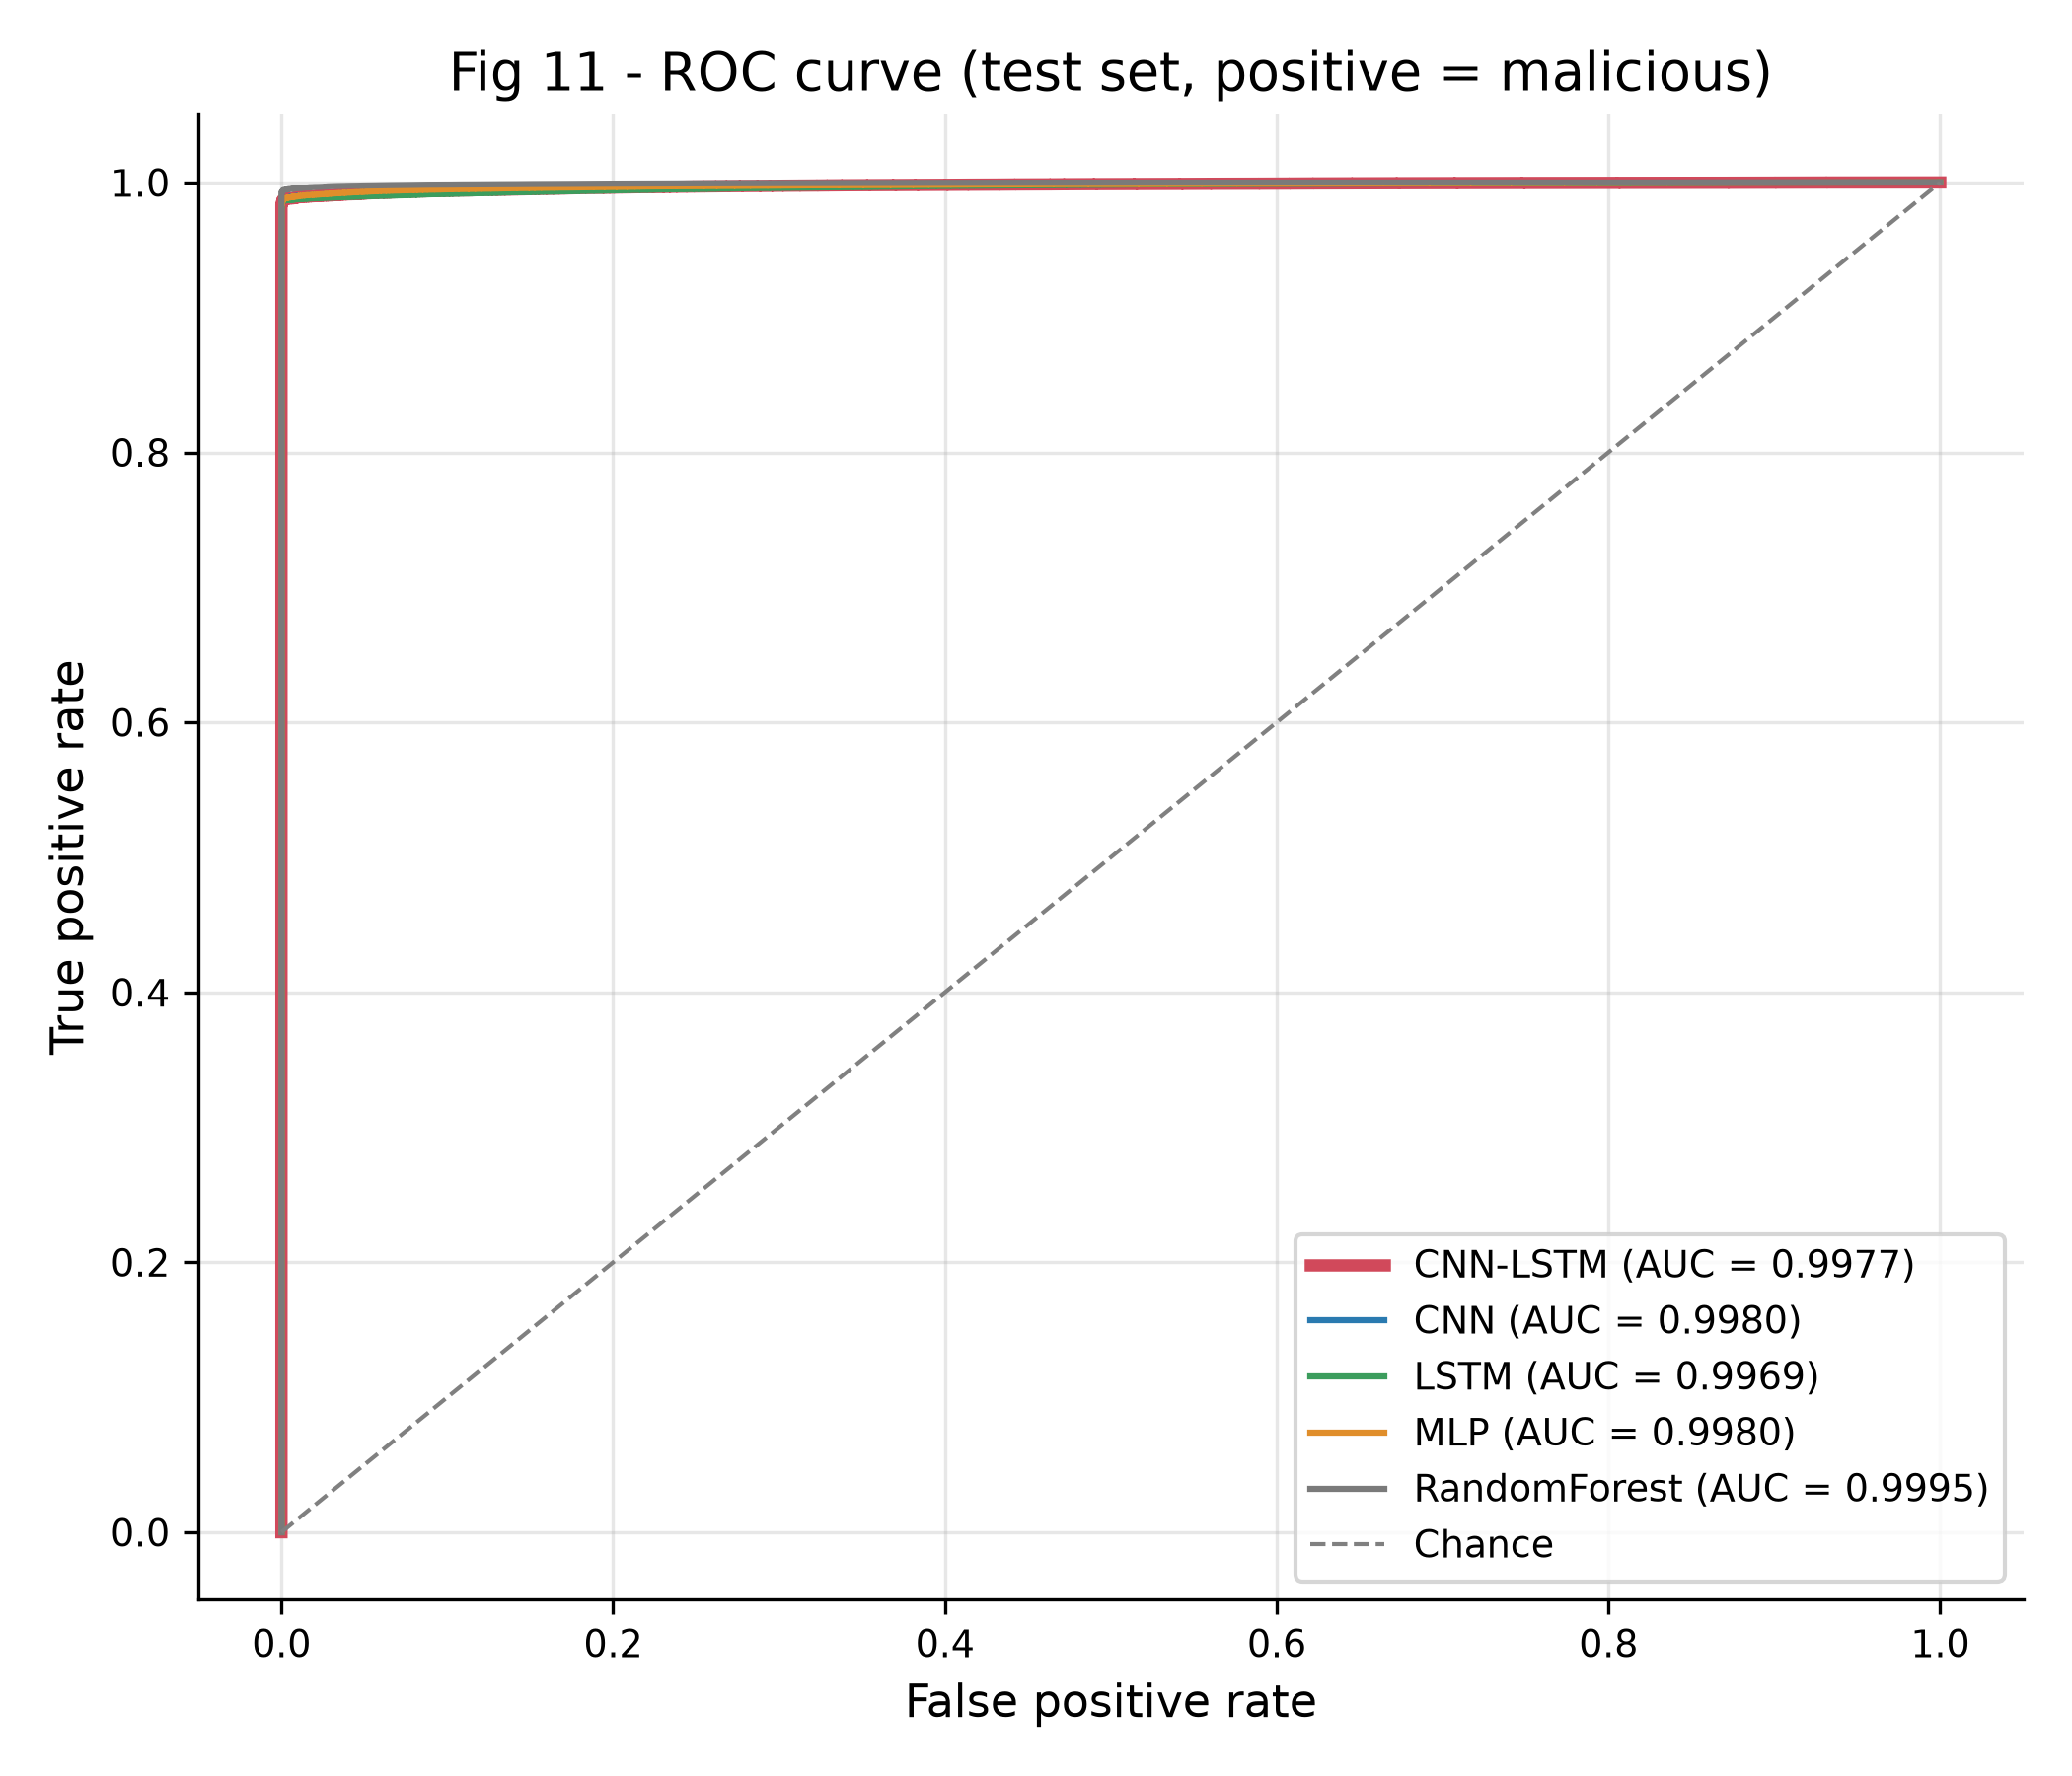

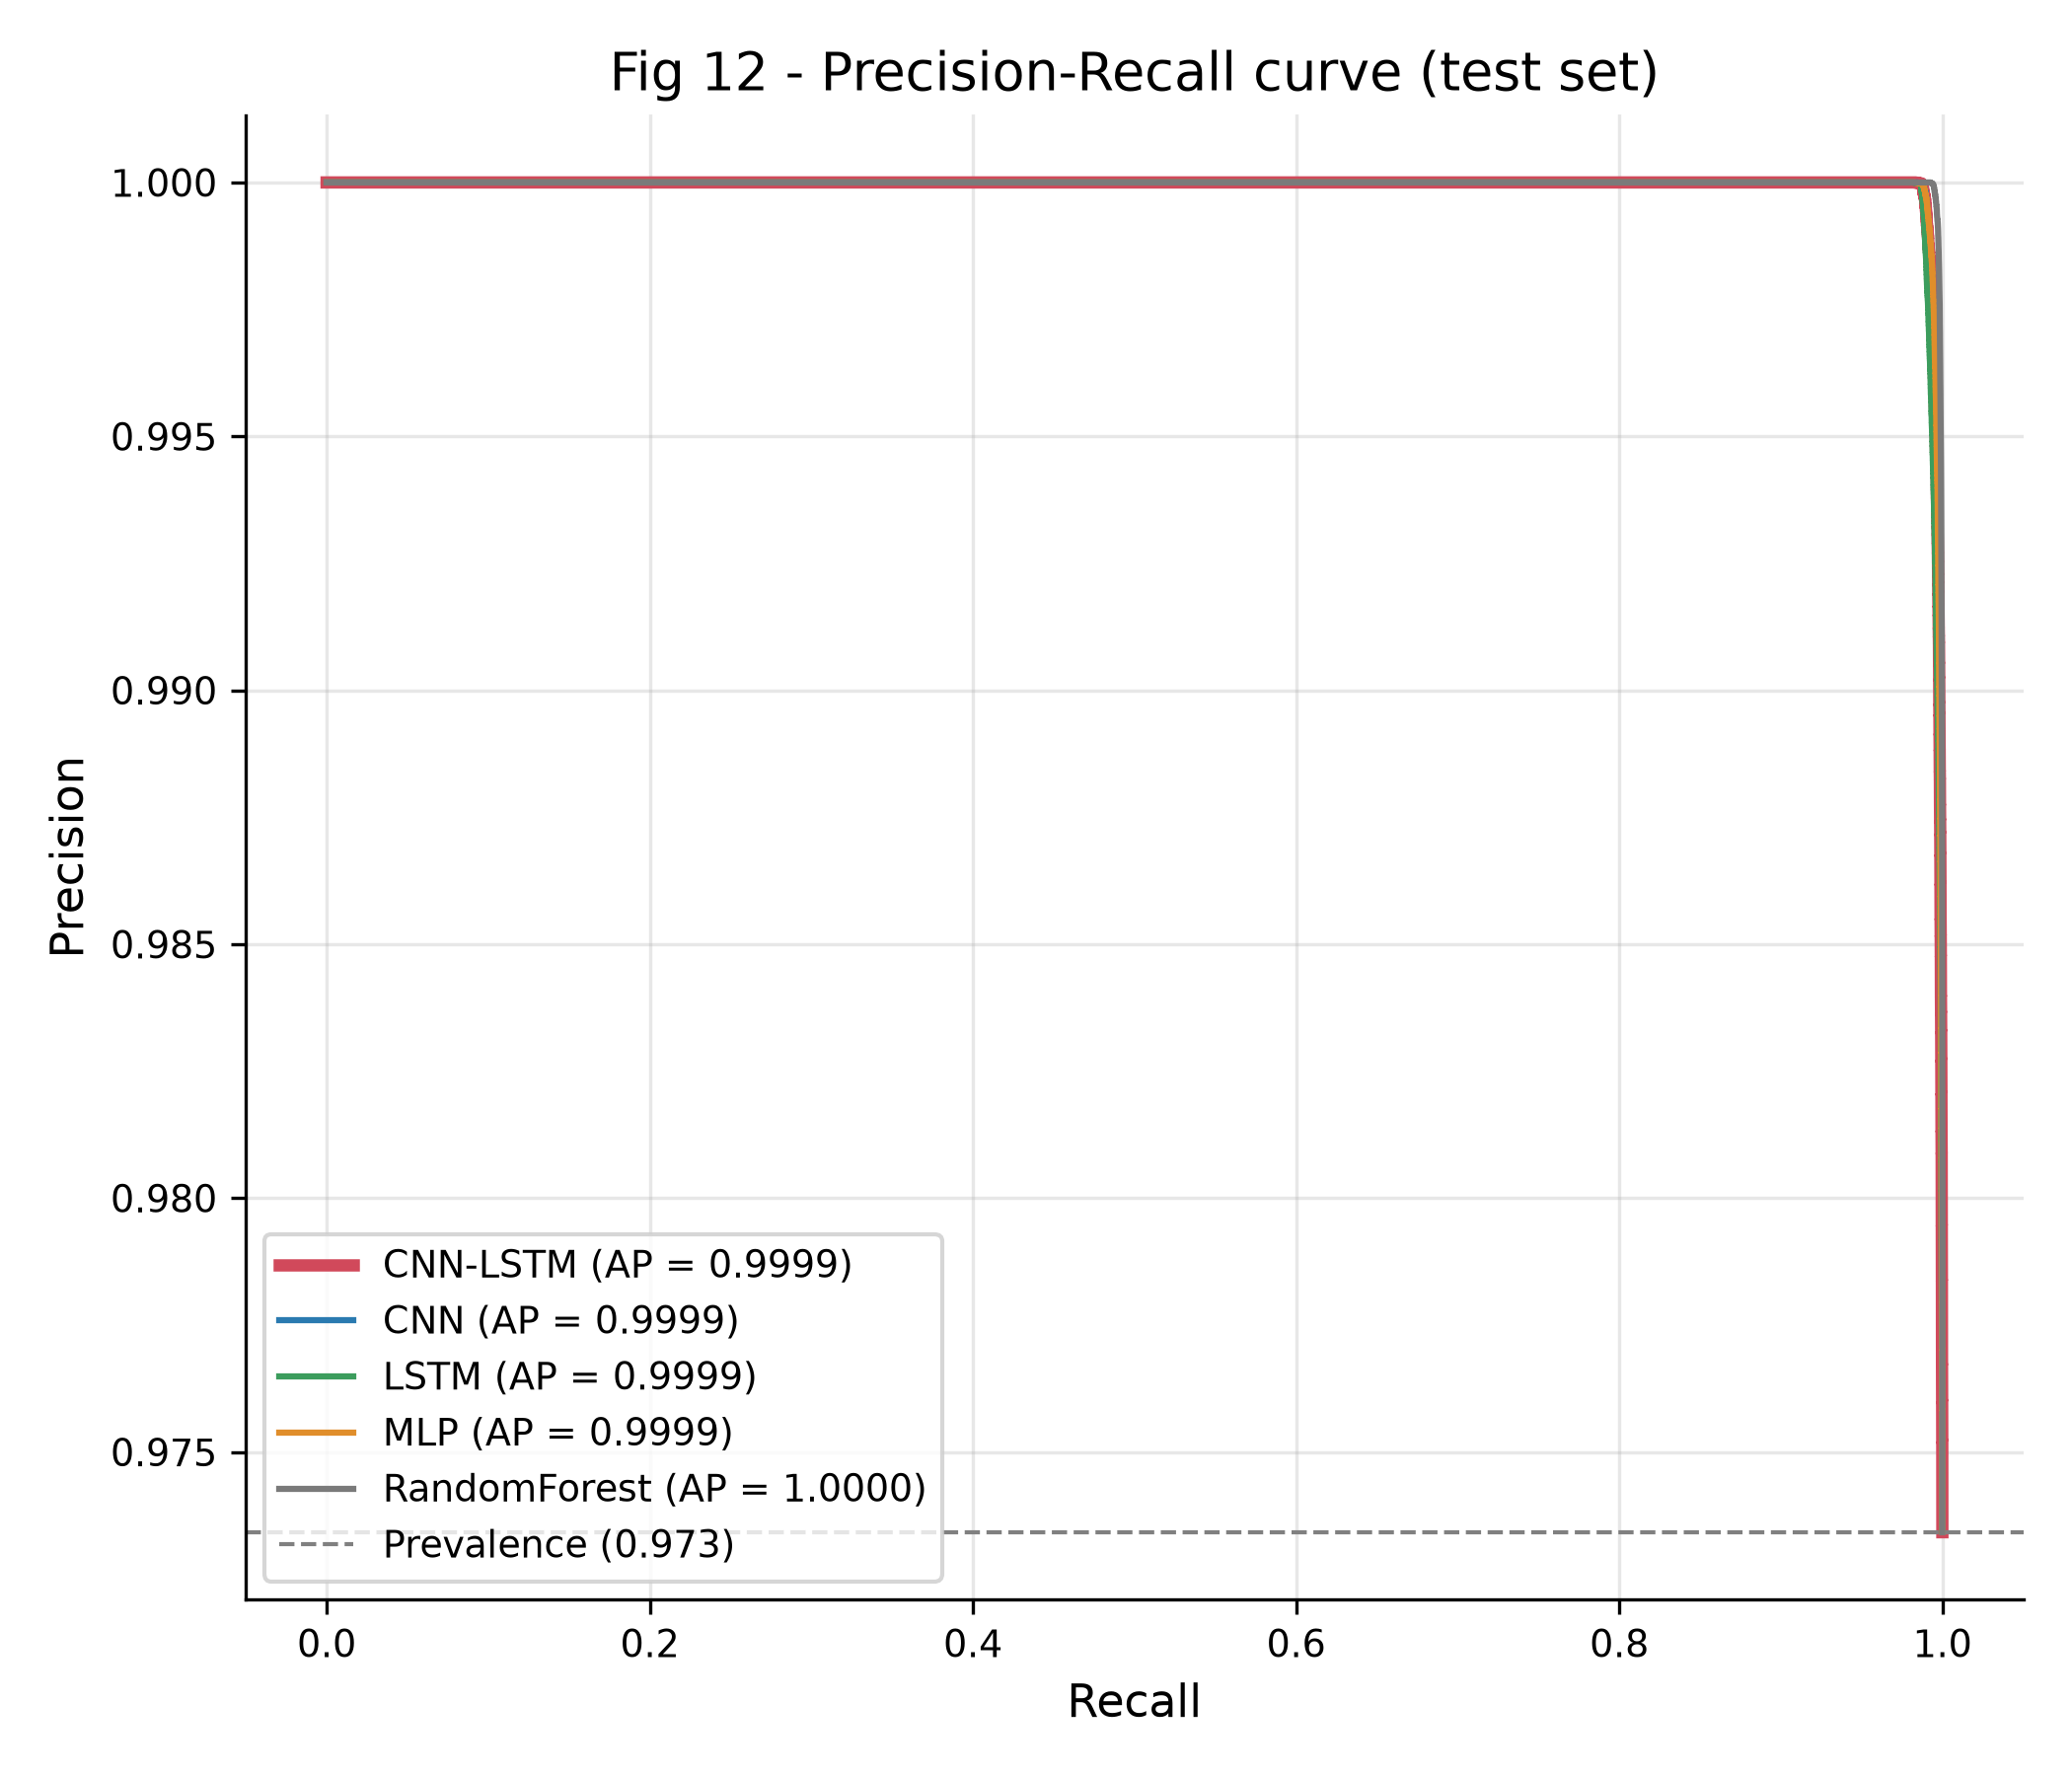

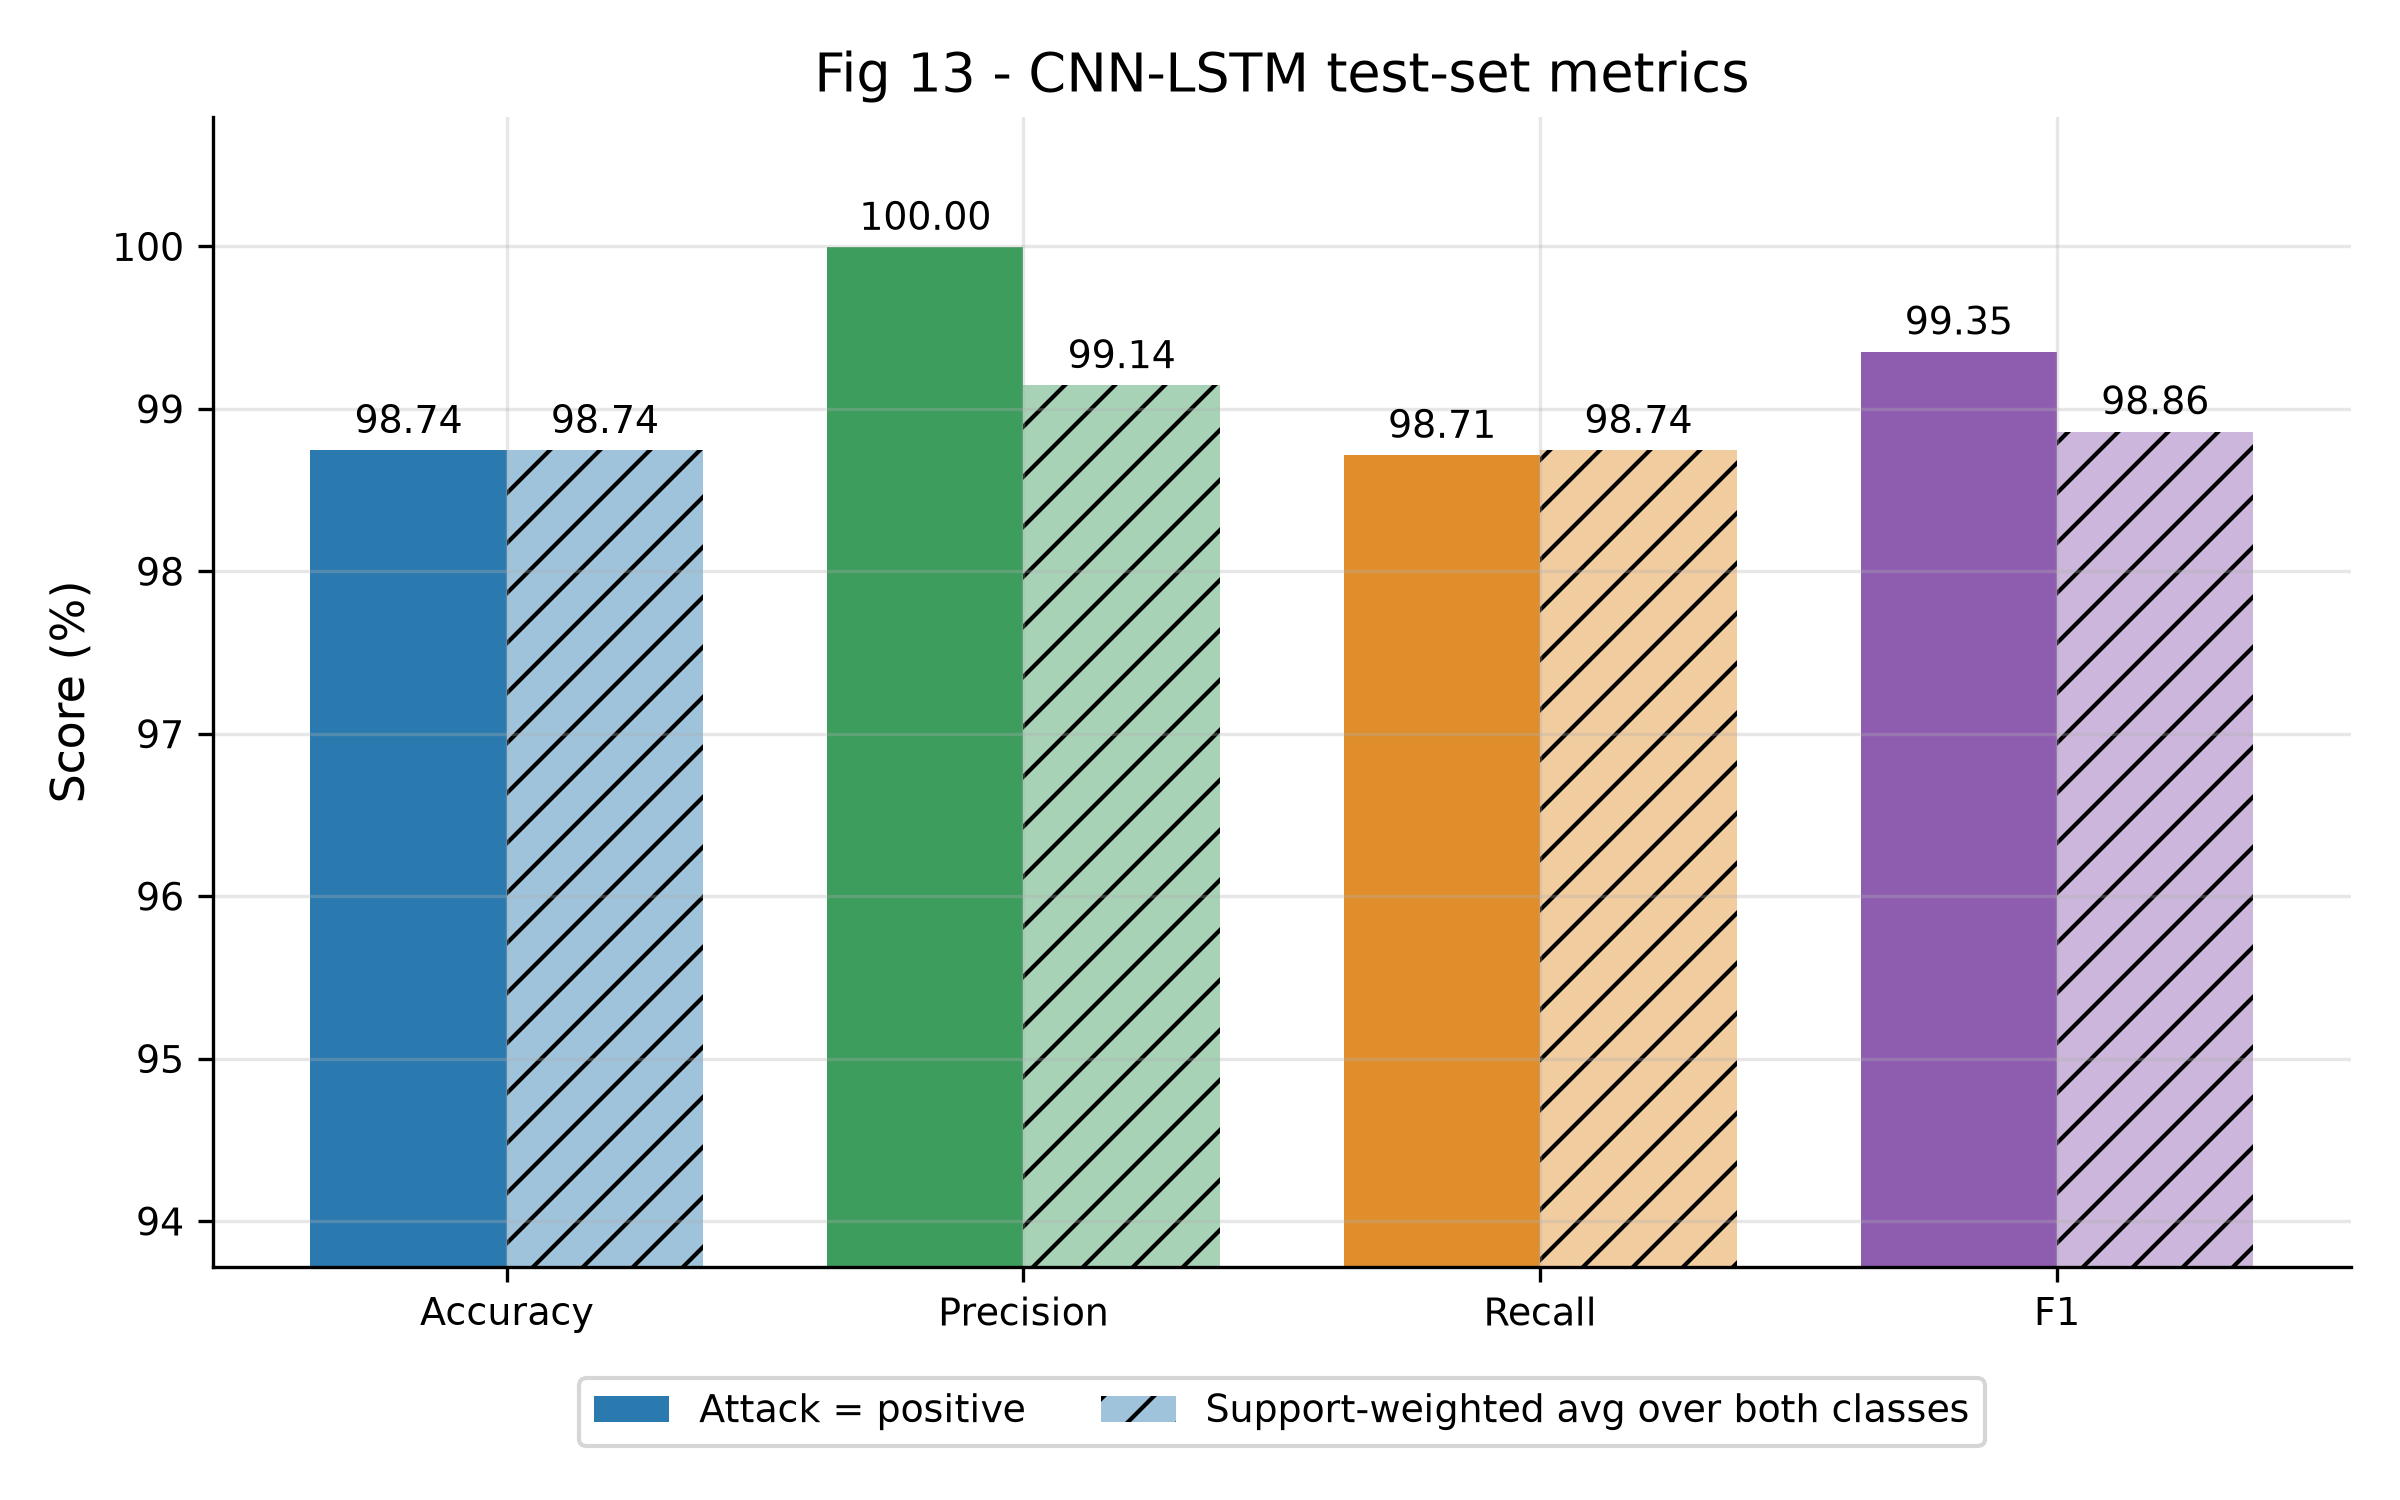

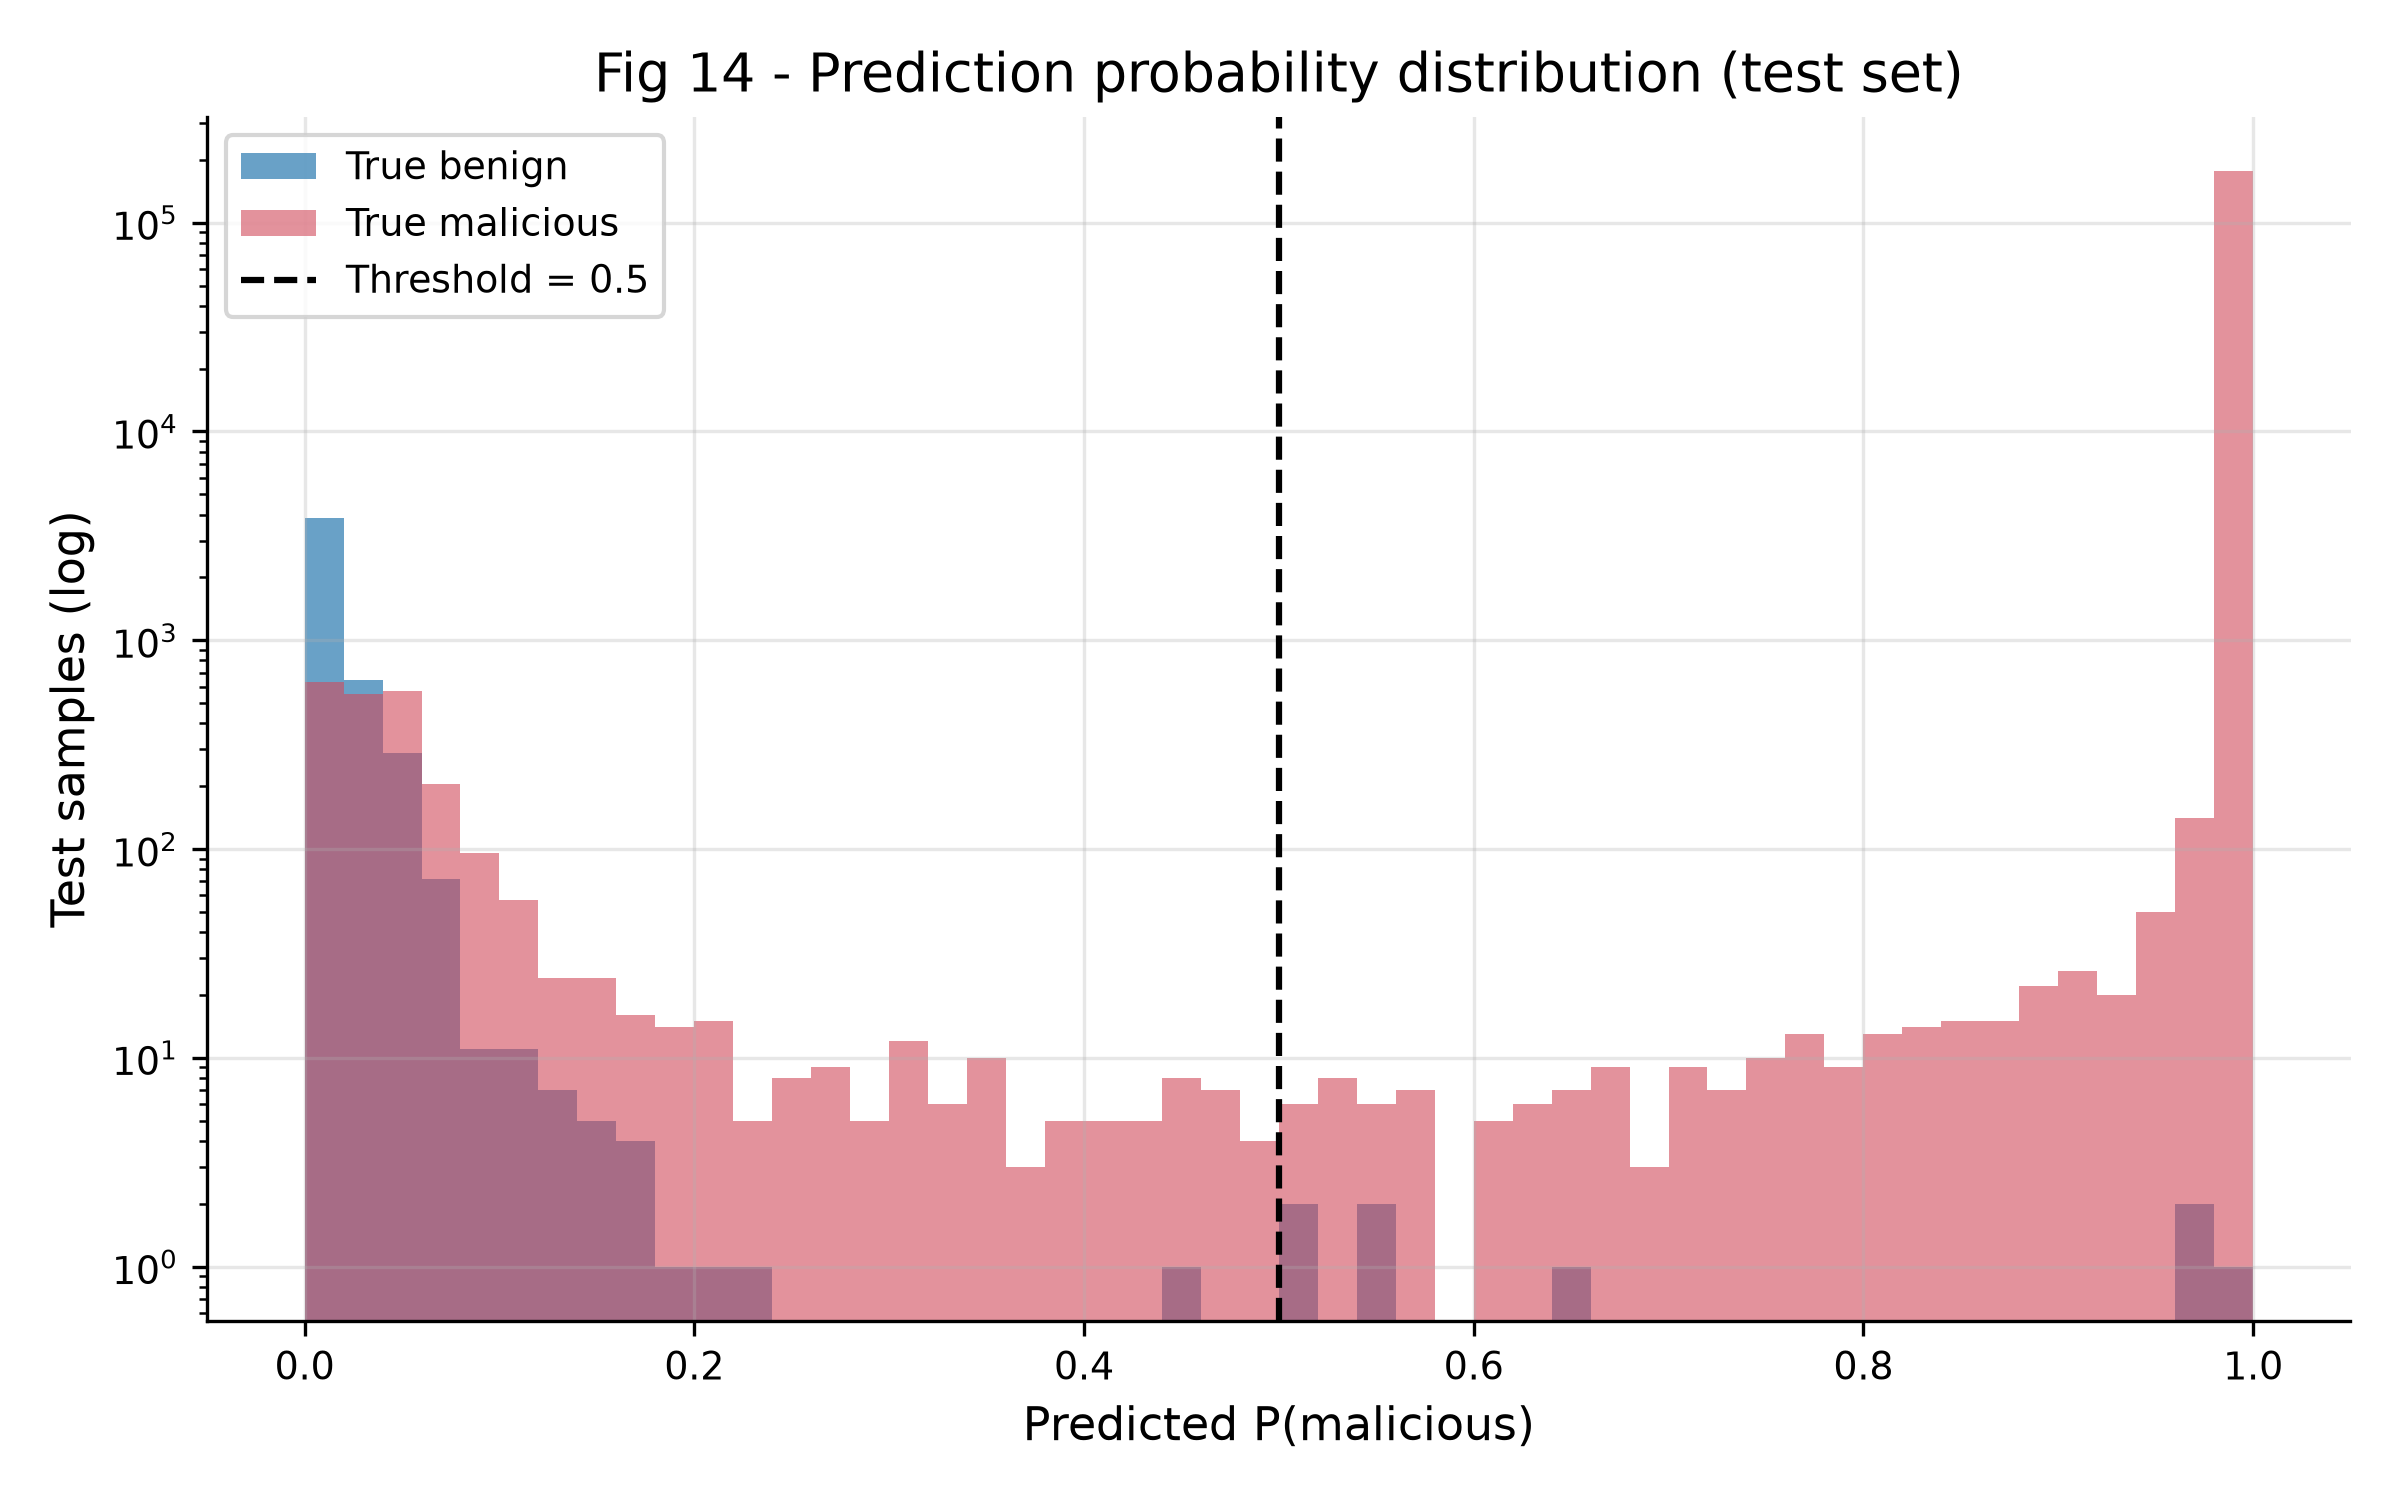

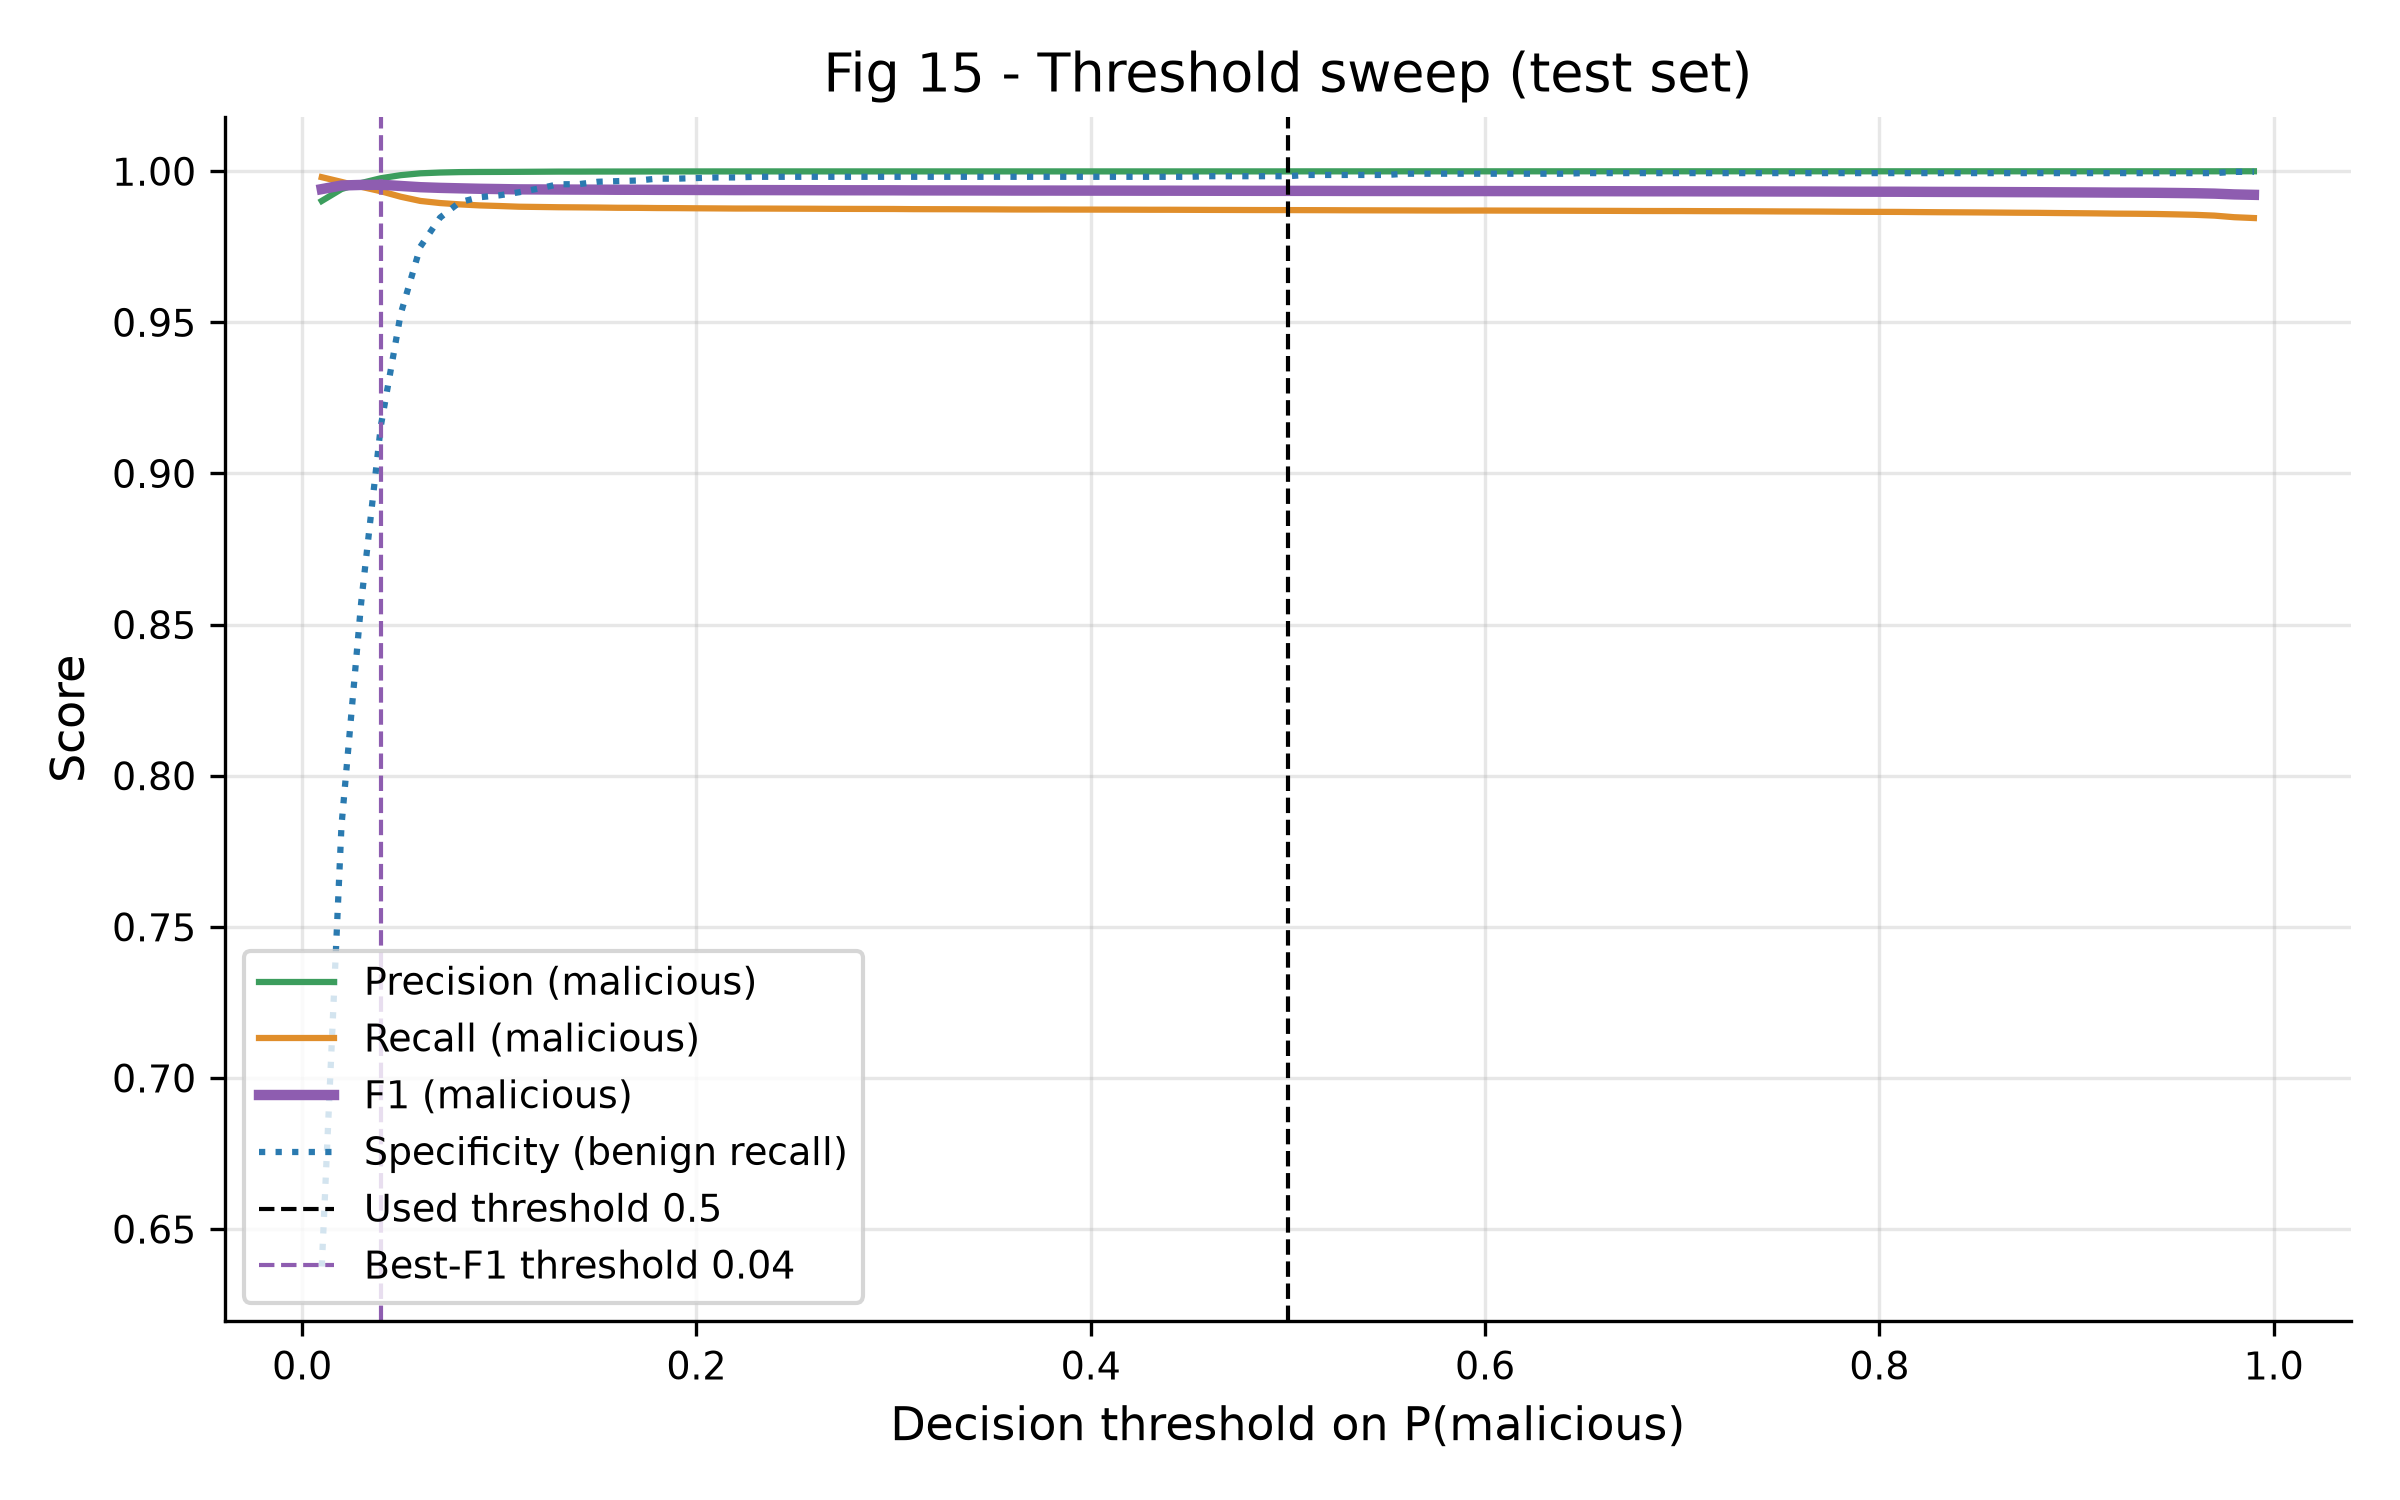

In [11]:
show('09_confusion_matrix_counts', '10_confusion_matrix_normalized', '11_roc_curve', '12_pr_curve', '13_metric_bars', '14_probability_histogram', '15_threshold_sweep')

## 8. Baselines and cost (Figs 17, 19)
CNN-only and LSTM-only are ablations of the same architecture; MLP and Random Forest (300k-row stratified train subsample) are references.

In [12]:
t = pd.read_csv(OUT / 'metrics' / 'results.csv').set_index('model')
t[['accuracy', 'f1', 'benign_recall', 'benign_f1', 'fpr', 'mcc', 'roc_auc', 'pr_auc',
   'inference_ms_per_sample', 'model_size_mb', 'train_time_s']].round(5)

,accuracy,f1,benign_recall,benign_f1,fpr,mcc,roc_auc,pr_auc,inference_ms_per_sample,model_size_mb,train_time_s
model,,,,,,,,,,,
CNN-LSTM,0.98745,0.99351,0.99836,0.80872,0.00164,0.81837,0.99775,0.99994,0.00478,1.04282,995.81299
Majority (always malicious),0.97342,0.98653,0.00000,0.00000,1.00000,0.00000,0.50000,0.97342,NaN,NaN,NaN
CNN,0.98817,0.99389,0.99836,0.81773,0.00164,0.82637,0.99805,0.99995,0.00458,0.40920,206.55150
LSTM,0.98640,0.99296,0.99918,0.79612,0.00082,0.80738,0.99688,0.99992,0.00385,0.63541,746.12019
MLP,0.98783,0.99371,0.99877,0.81350,0.00123,0.82266,0.99798,0.99995,0.00537,0.19542,104.51173
RandomForest,0.99612,0.99800,0.98077,0.93068,0.01923,0.92997,0.99946,0.99998,0.00047,4.37923,2.40306


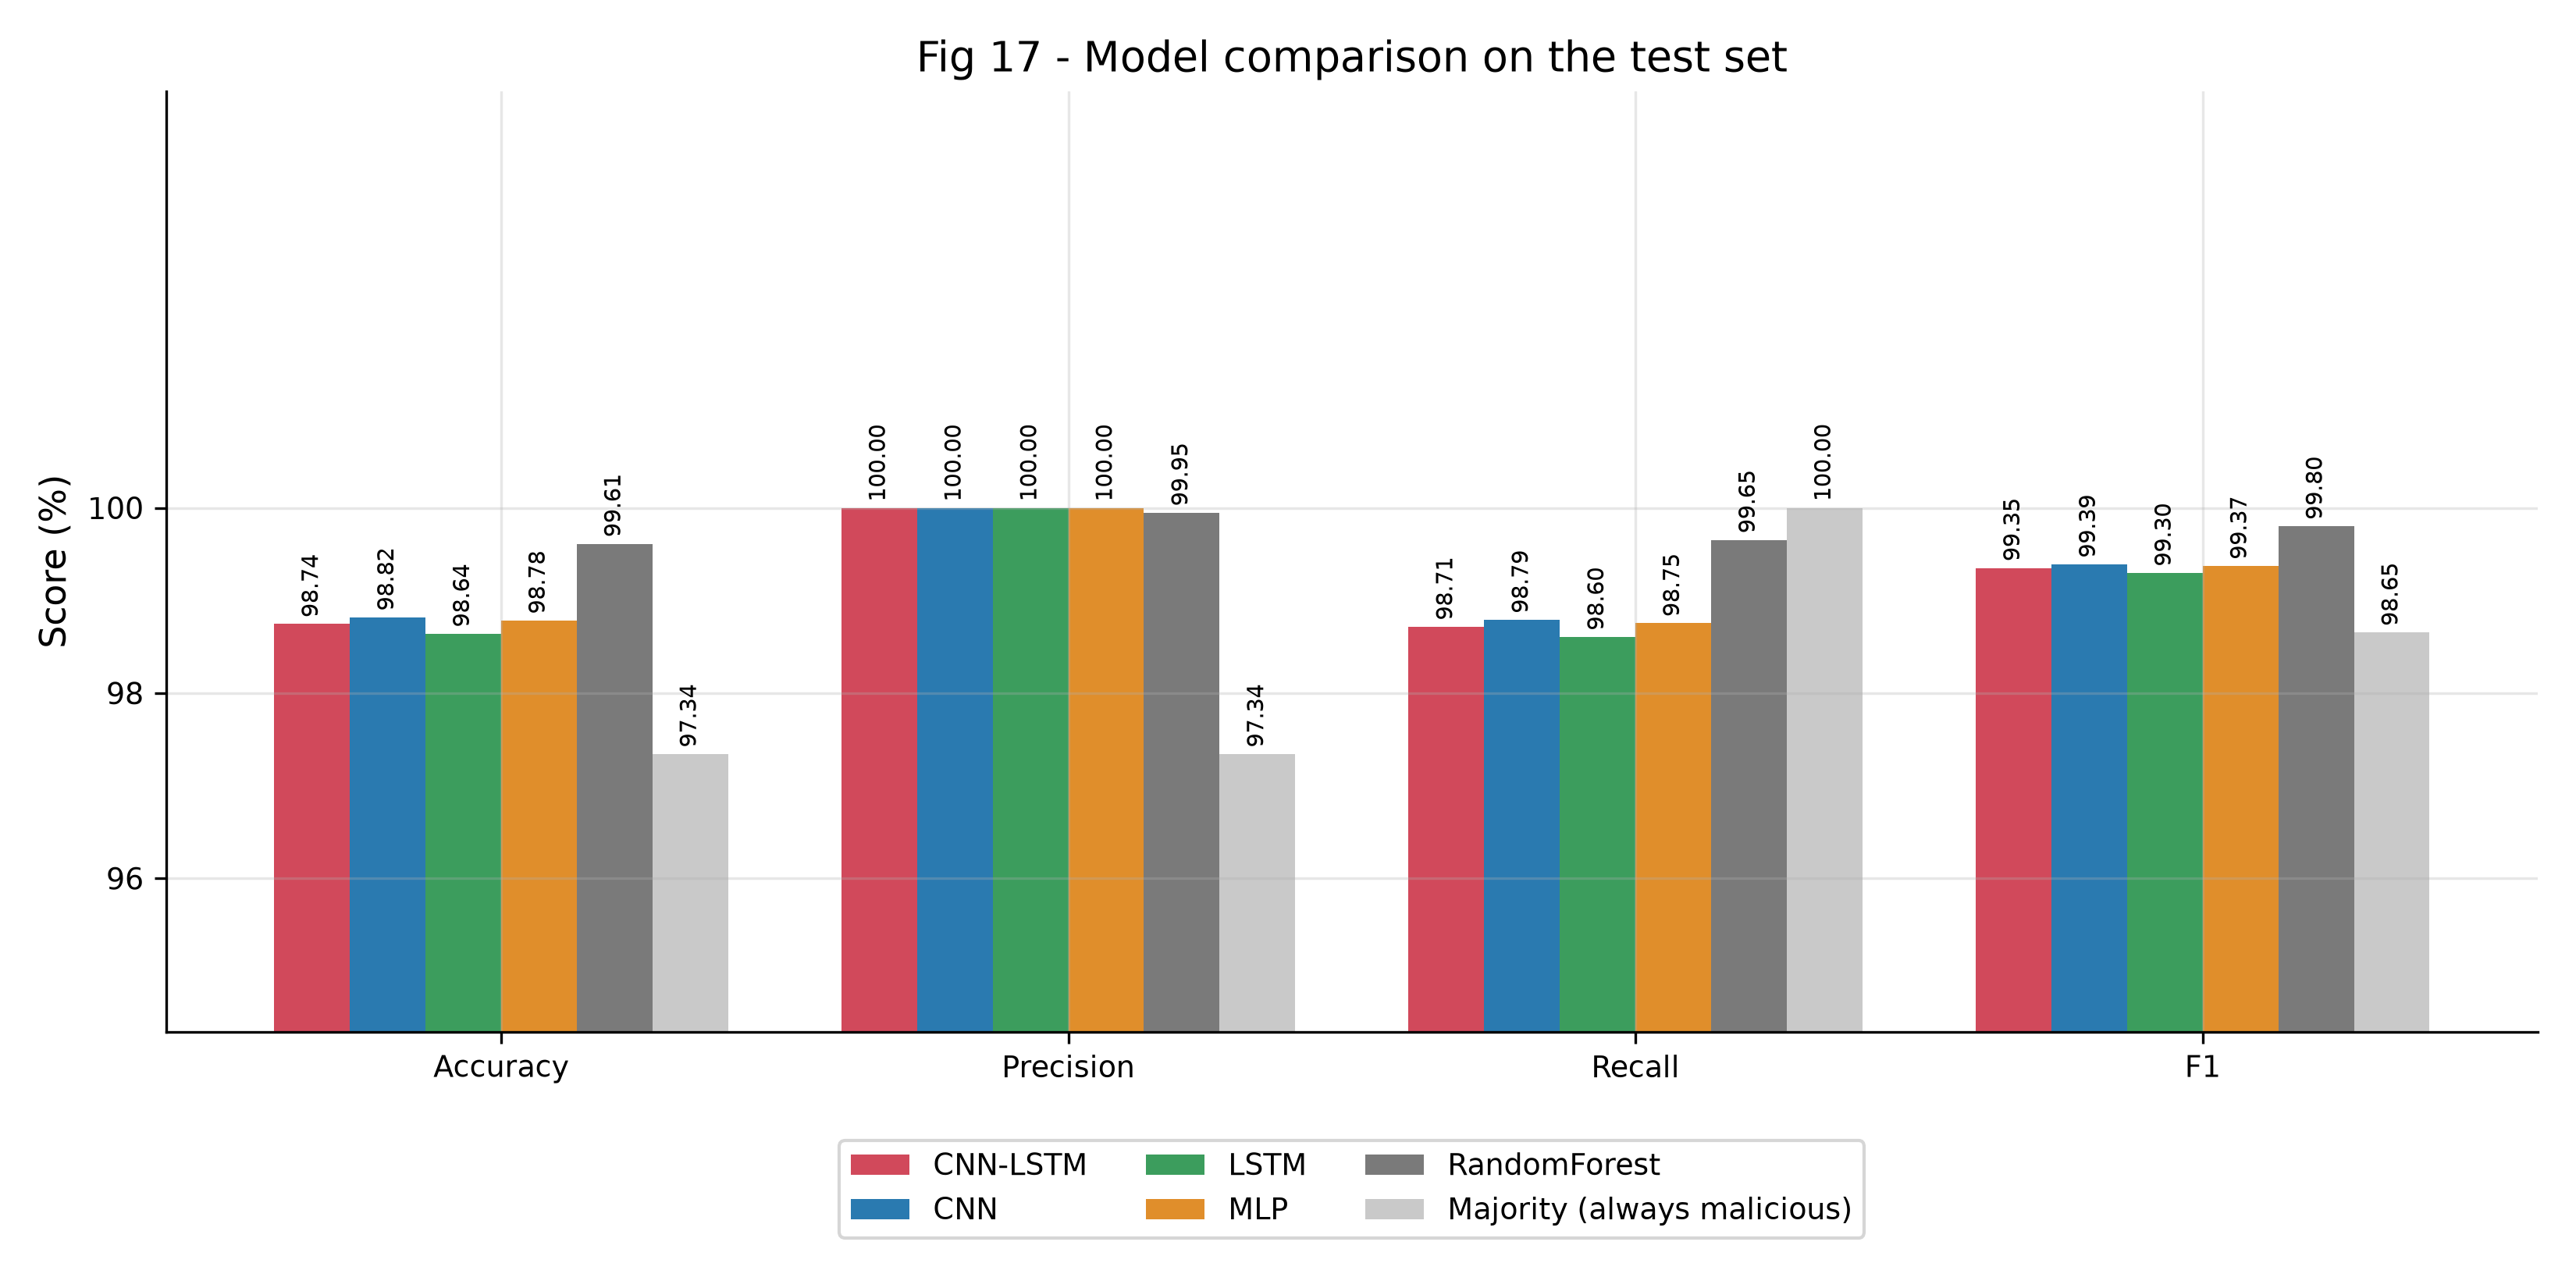

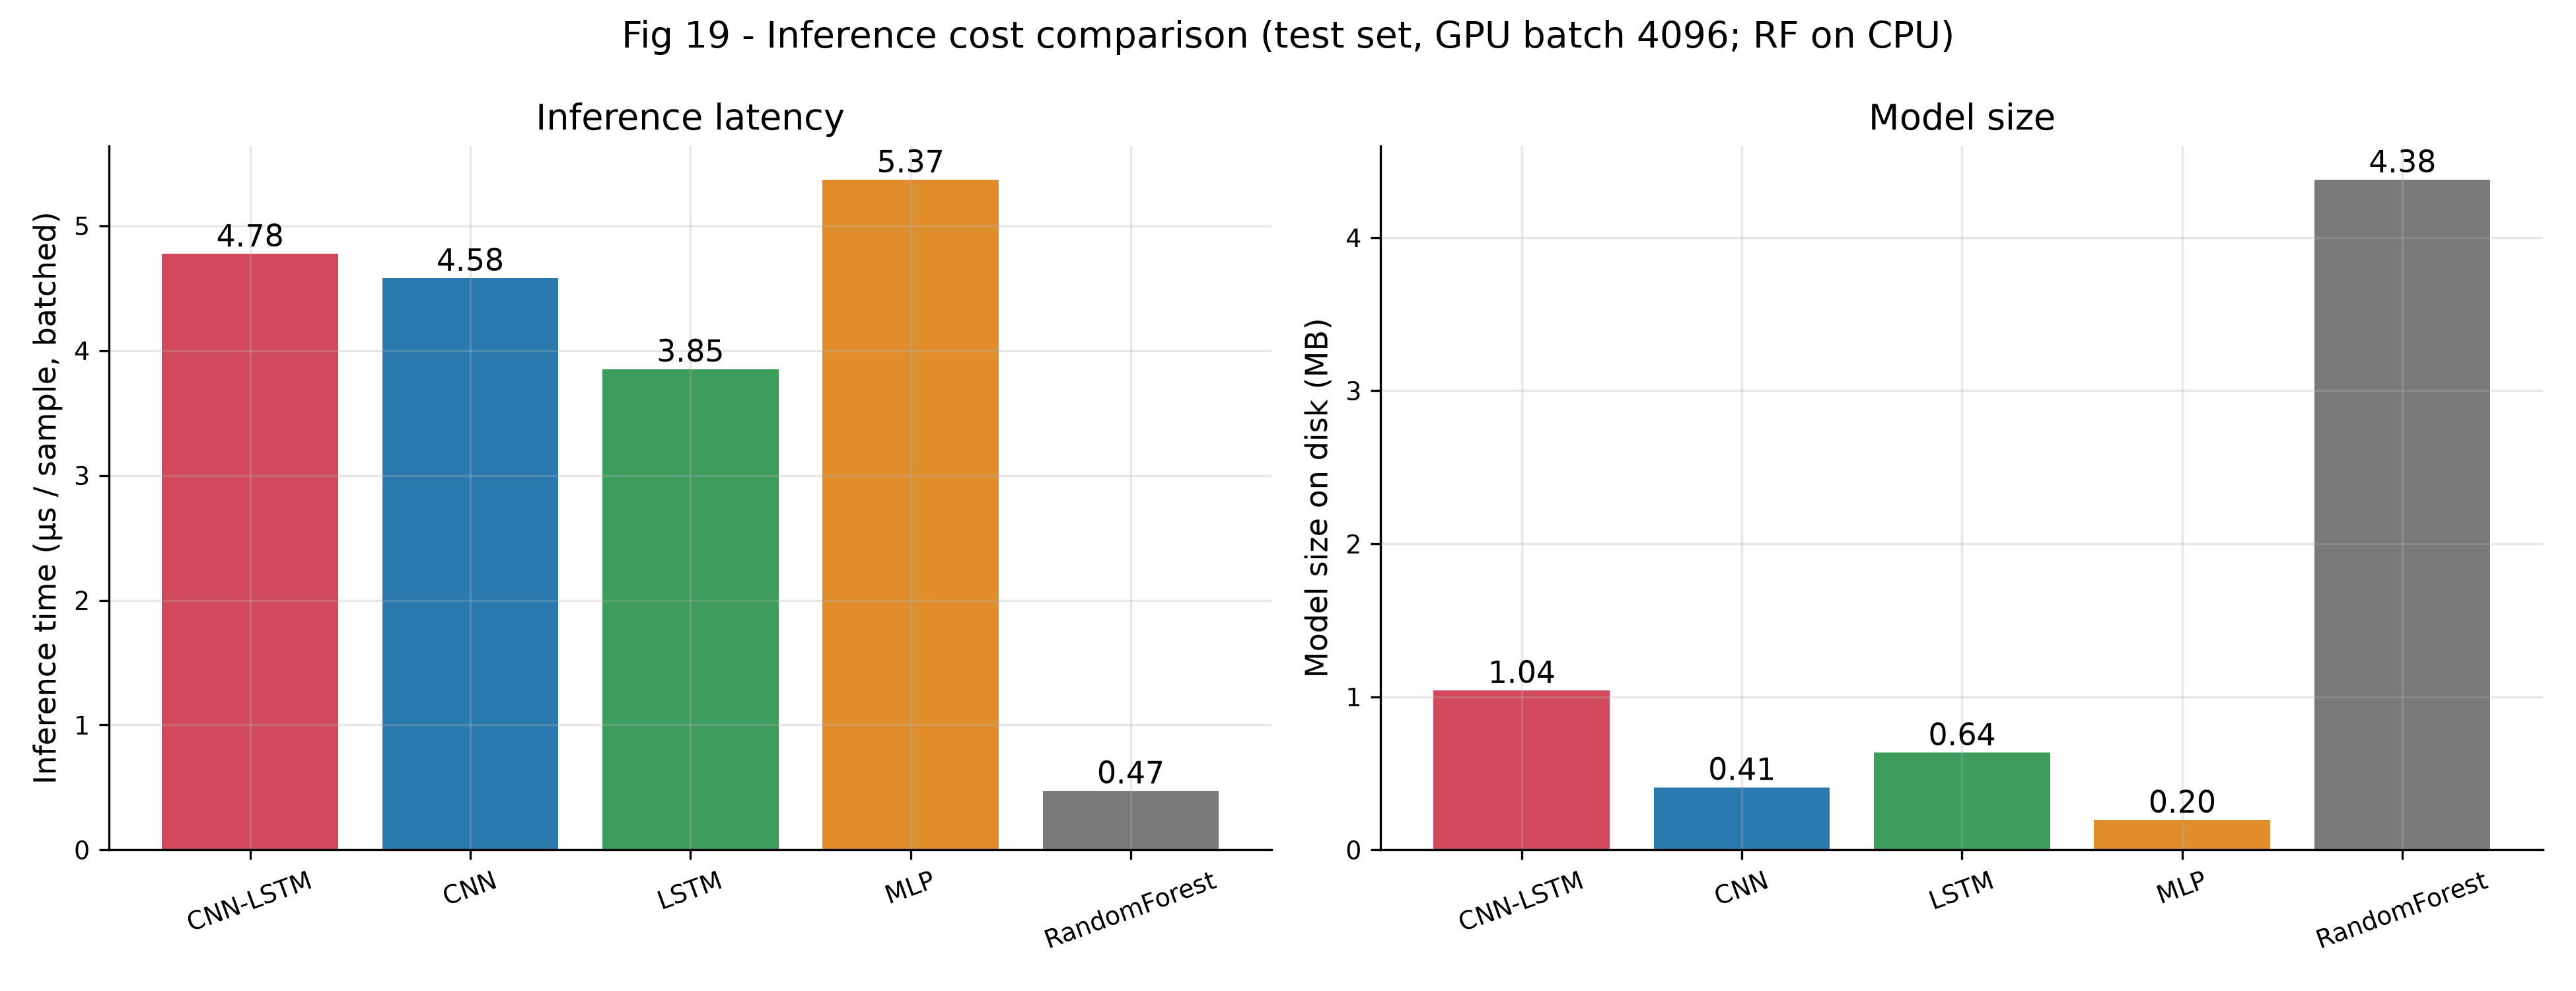

In [13]:
show('17_model_comparison', '19_inference_cost_comparison')

## 9. Comparison with the paper (Fig 18) and deviation analysis

In [14]:
display(Markdown((OUT / 'metrics' / 'paper_comparison.md').read_text()))

| metric                                 |   paper |   ours_cnn_lstm |   majority_baseline |   abs_diff_vs_paper |   rel_diff_vs_paper_% |
|:---------------------------------------|--------:|----------------:|--------------------:|--------------------:|----------------------:|
| Accuracy (%)                           |   98.42 |         98.7447 |             97.342  |              0.3247 |                  0.33 |
| Precision, support-weighted (%)        |  nan    |         99.144  |             94.7546 |            nan      |                nan    |
| Recall, support-weighted (%)           |  nan    |         98.7447 |             97.342  |            nan      |                nan    |
| F1, support-weighted (%)               |  nan    |         98.8599 |             96.0308 |            nan      |                nan    |
| Precision, malicious = positive (%)    |  nan    |         99.9955 |             97.342  |            nan      |                nan    |
| Recall / detection rate, malicious (%) |  nan    |         98.7149 |            100      |            nan      |                nan    |
| F1, malicious (%)                      |  nan    |         99.351  |             98.6531 |            nan      |                nan    |
| Benign precision (%)                   |  nan    |         67.9621 |              0      |            nan      |                nan    |
| Benign recall = specificity (%)        |  nan    |         99.8363 |              0      |            nan      |                nan    |
| Benign F1 (%)                          |  nan    |         80.8719 |              0      |            nan      |                nan    |
| False positive rate (%)                |  nan    |          0.1637 |            100      |            nan      |                nan    |
| False negative rate (%)                |  nan    |          1.2851 |              0      |            nan      |                nan    |
| Matthews corr. coef.                   |  nan    |          0.8184 |              0      |            nan      |                nan    |
| ROC-AUC                                |  nan    |          0.9977 |              0.5    |            nan      |                nan    |
| PR-AUC (average precision)             |  nan    |          0.9999 |              0.9734 |            nan      |                nan    |
| Cross-entropy loss                     |  nan    |          0.0443 |              0.4238 |            nan      |                nan    |

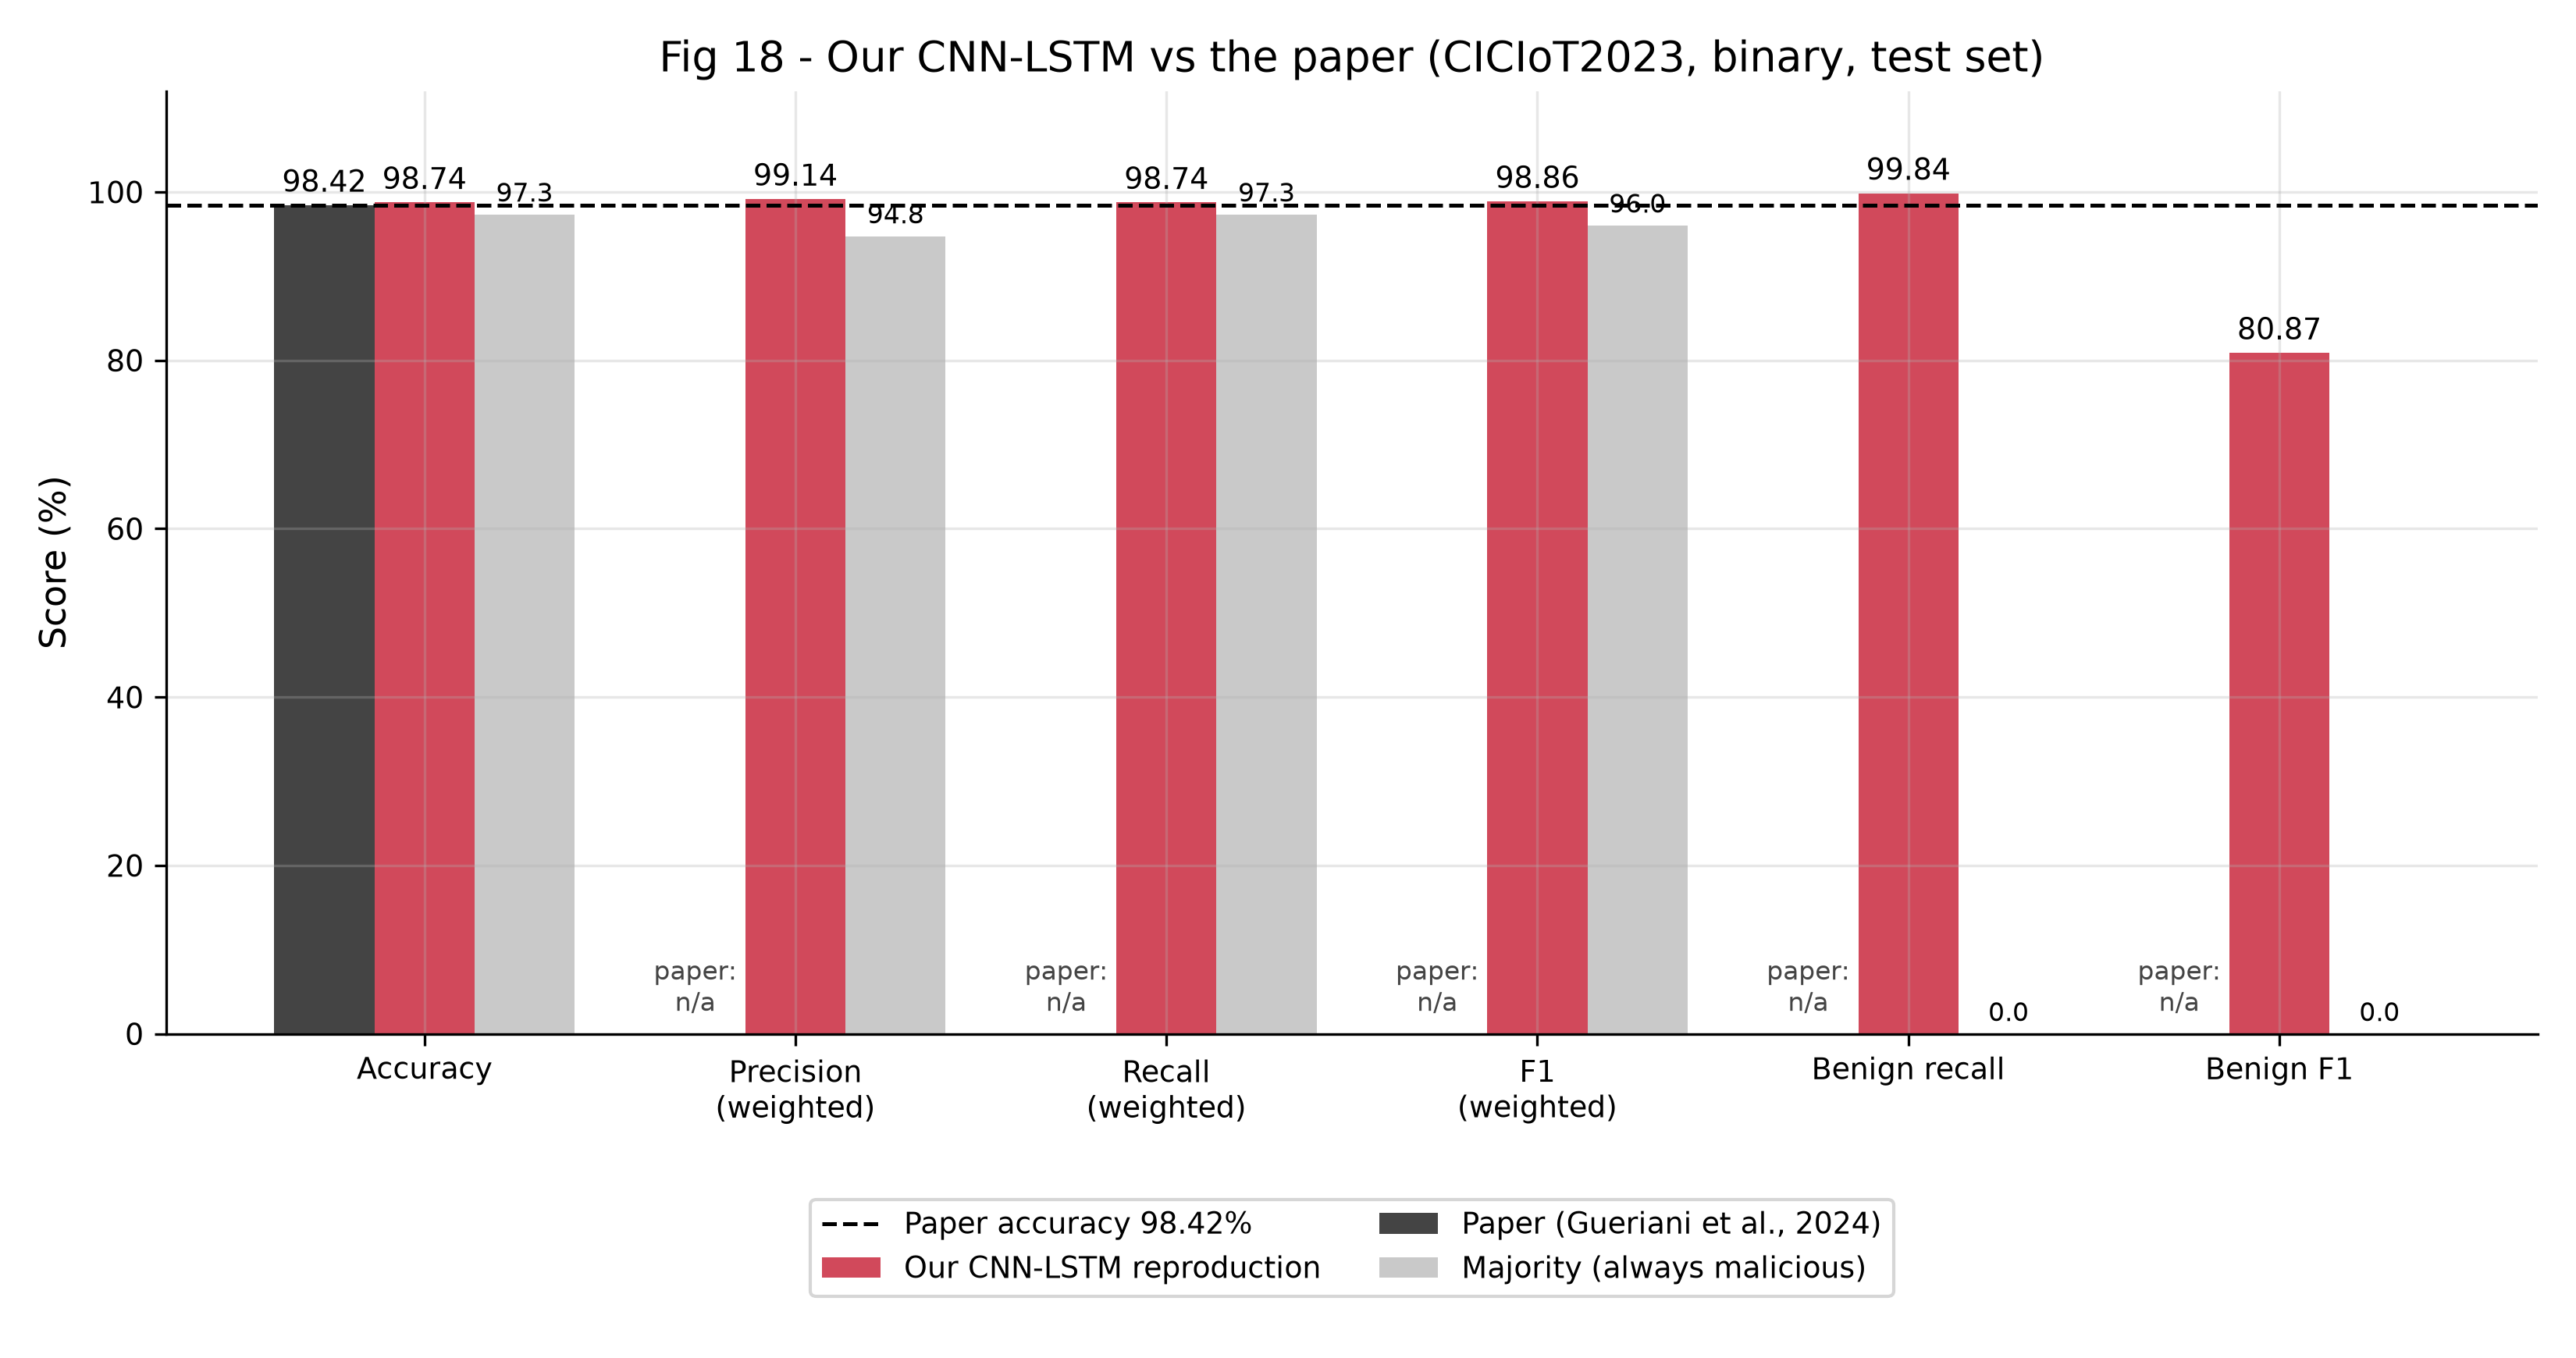

In [15]:
show('18_paper_comparison')

In [16]:
print((OUT / 'metrics' / 'deviation_analysis.txt').read_text())

DEVIATION ANALYSIS - CNN-LSTM reproduction of Gueriani, Kheddar & Mazari (IEEE PAIS 2024)
Accuracy: ours 98.74% vs paper 98.42% -> +0.32 percentage points (+0.33% relative).
Only the paper's accuracy is used as a reference; its other metrics are left as None in config.PAPER_RESULTS until checked against the published paper.
Context: always predicting 'malicious' already scores 97.34% accuracy on our test split (benign recall 0%, MCC 0). The model's real value shows in benign recall 99.84%, FPR 0.16%, MCC 0.8184.

Comparison table:
                                metric  paper  ours_cnn_lstm  majority_baseline  abs_diff_vs_paper  rel_diff_vs_paper_%
                          Accuracy (%)  98.42        98.7447            97.3420             0.3247                 0.33
       Precision, support-weighted (%)    NaN        99.1440            94.7546                NaN                  NaN
          Recall, support-weighted (%)    NaN        98.7447            97.3420                NaN     

## 10. Error analysis, embeddings and stability (Figs 20–22)

In [17]:
pd.read_csv(OUT / 'metrics' / 'error_by_attack_type.csv').head(15)

,sub,error_rate,errors,n
0,Backdoor_Malware,1.000000,17,17
1,BrowserHijacking,1.000000,27,27
2,Recon-PingSweep,1.000000,11,11
3,CommandInjection,1.000000,24,24
4,Uploading_Attack,1.000000,6,6
5,SqlInjection,1.000000,24,24
6,XSS,1.000000,17,17
7,DictionaryBruteForce,0.850000,51,60
8,Recon-OSScan,0.796840,353,443
9,DNS_Spoofing,0.745721,610,818


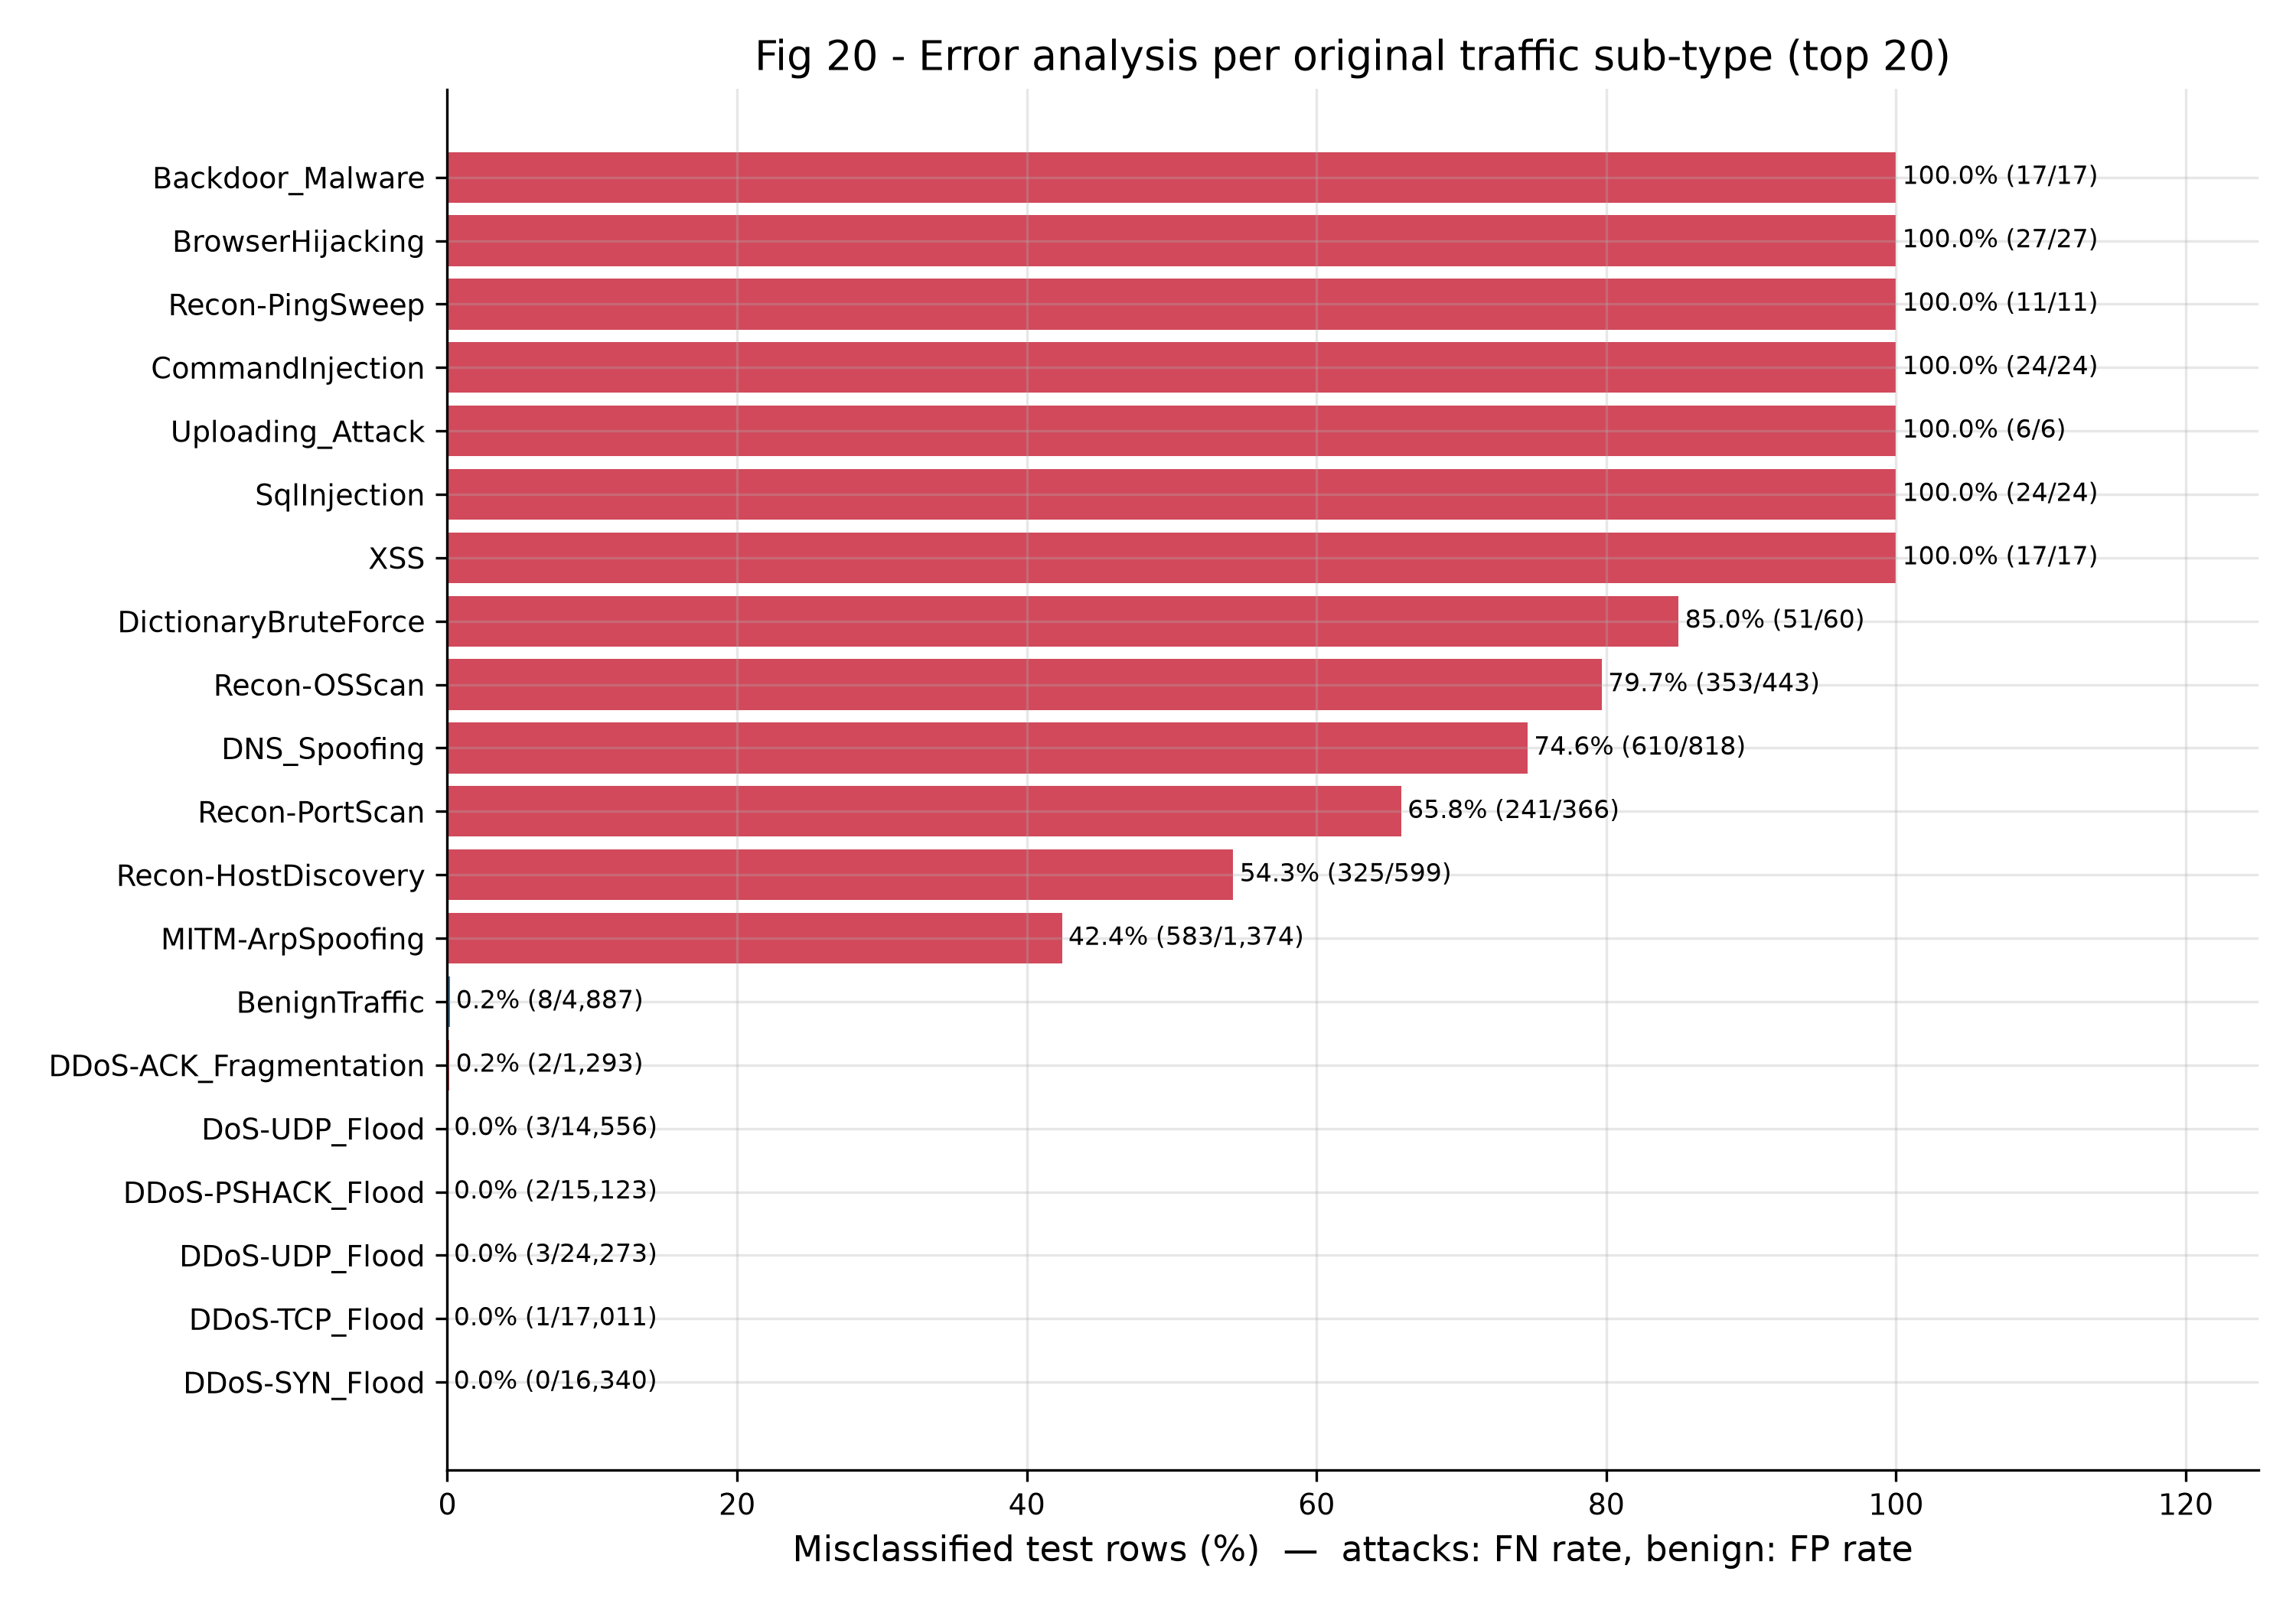

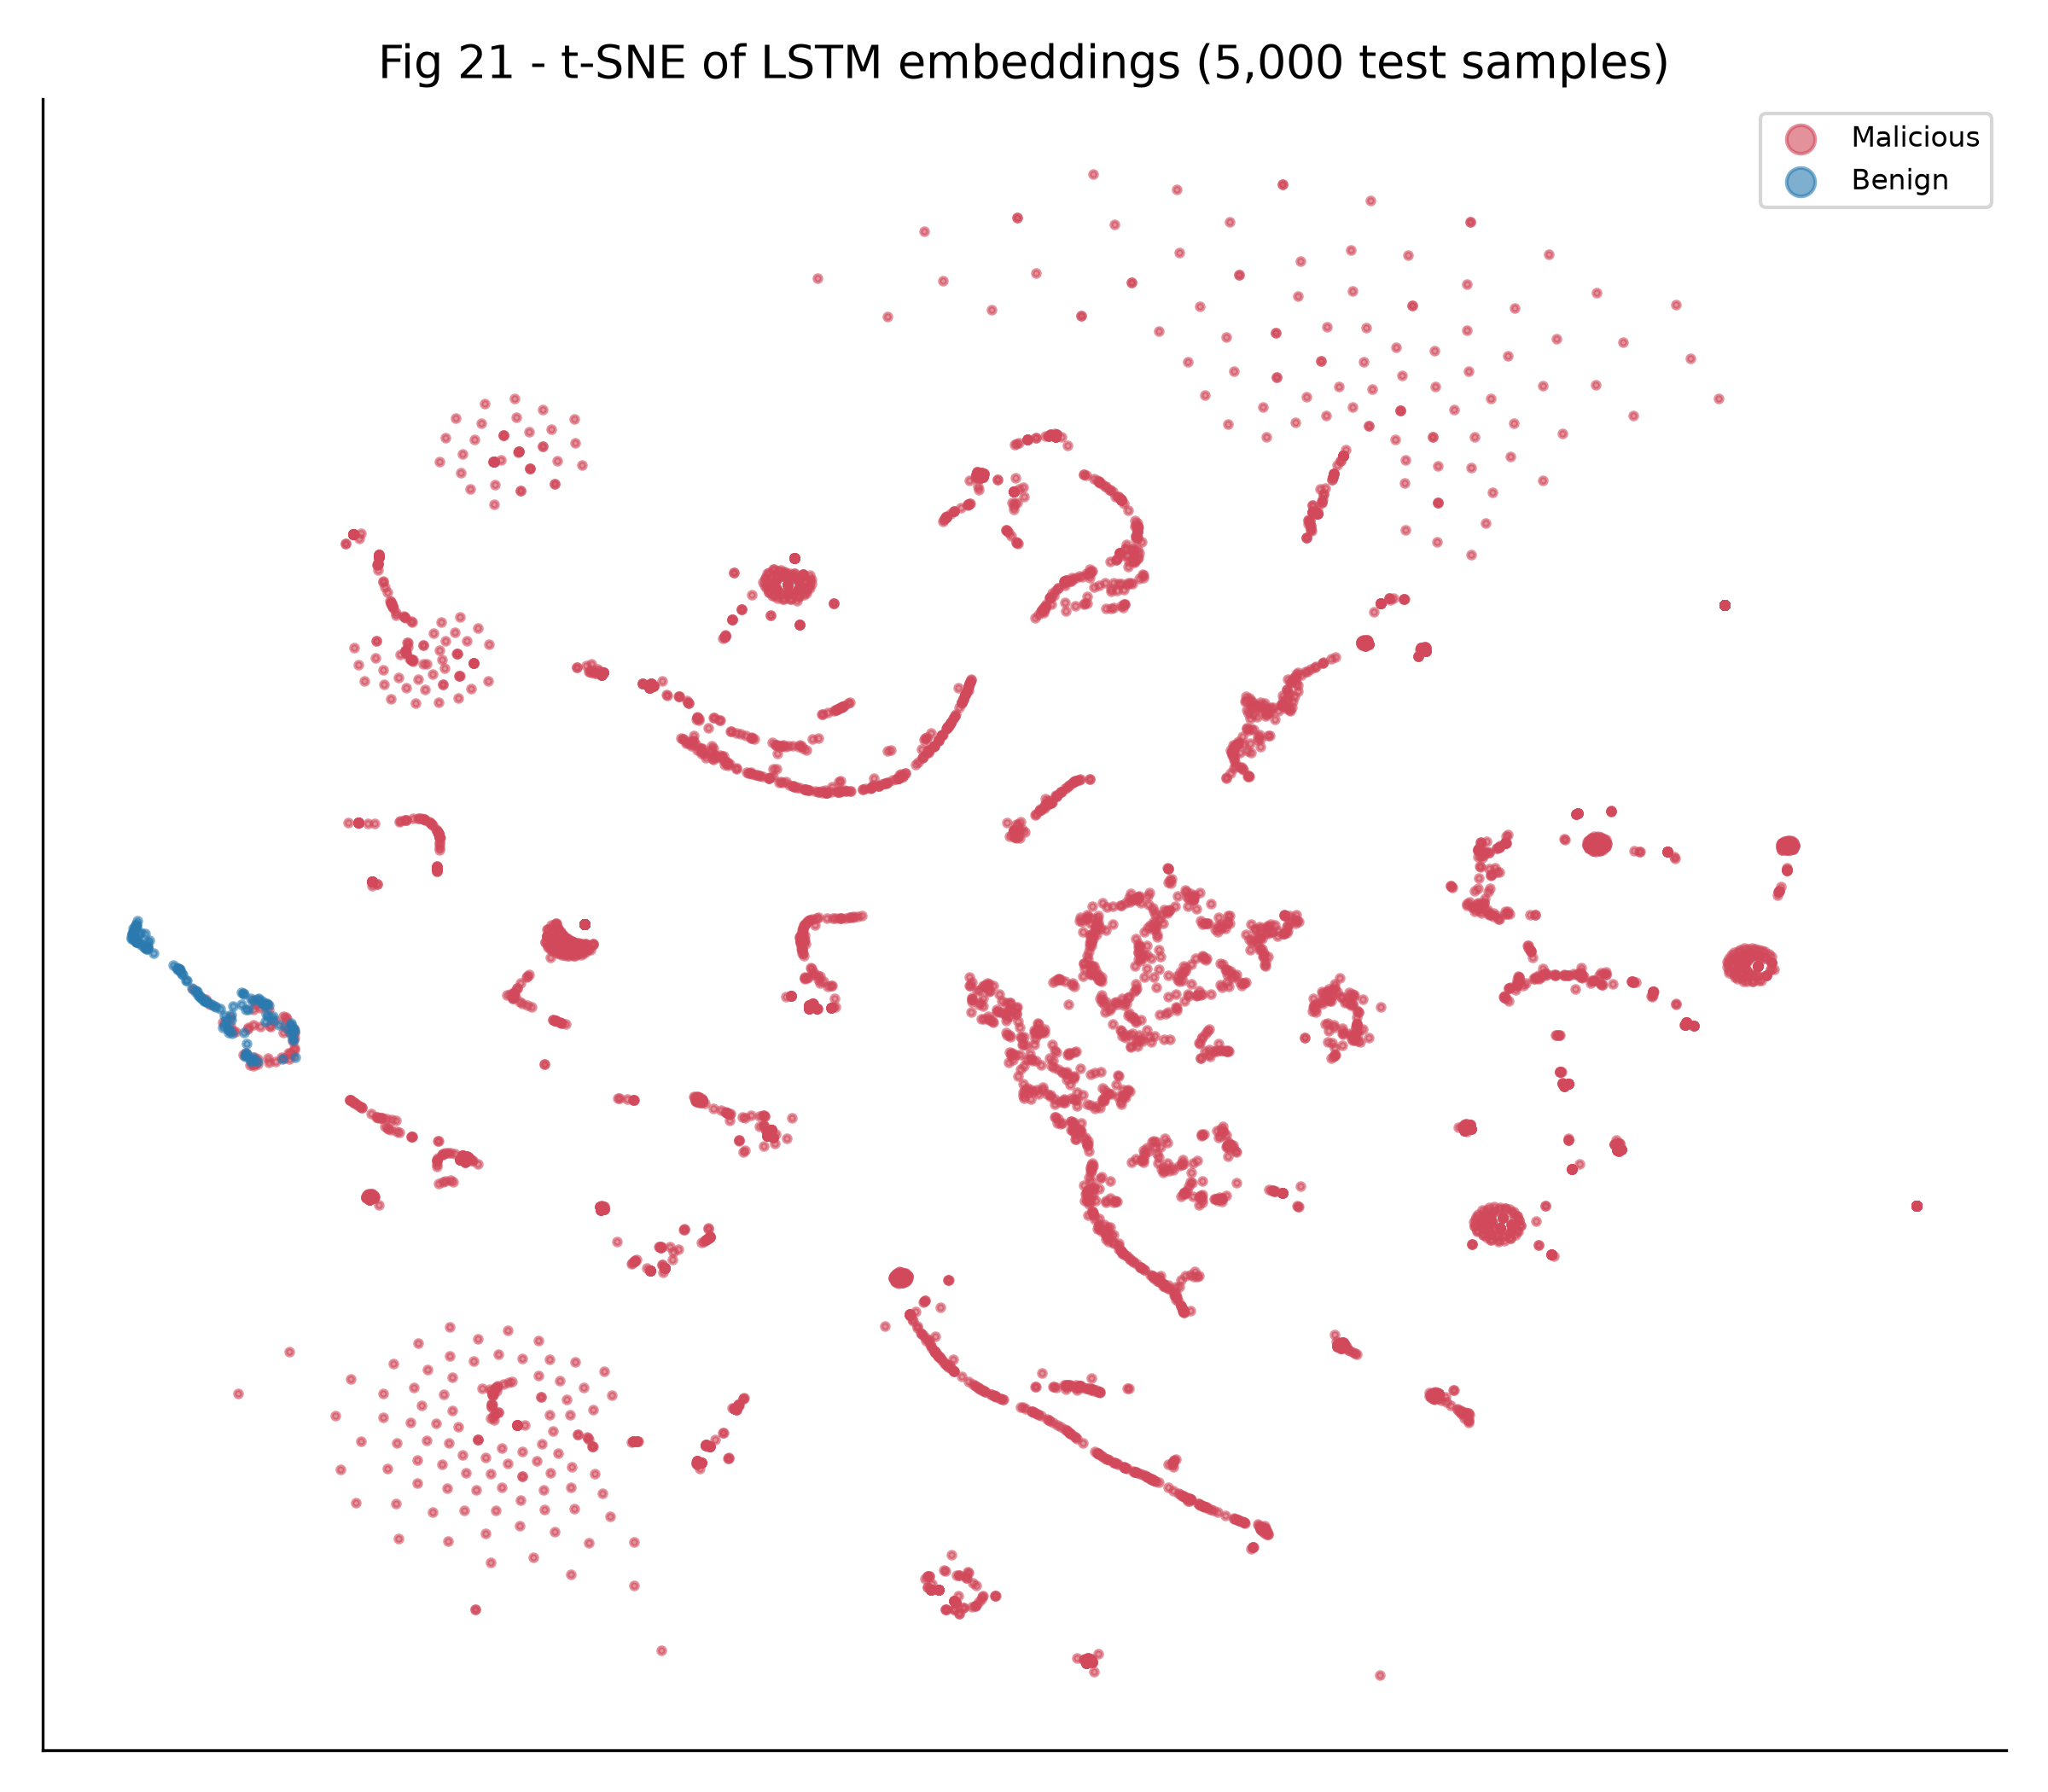

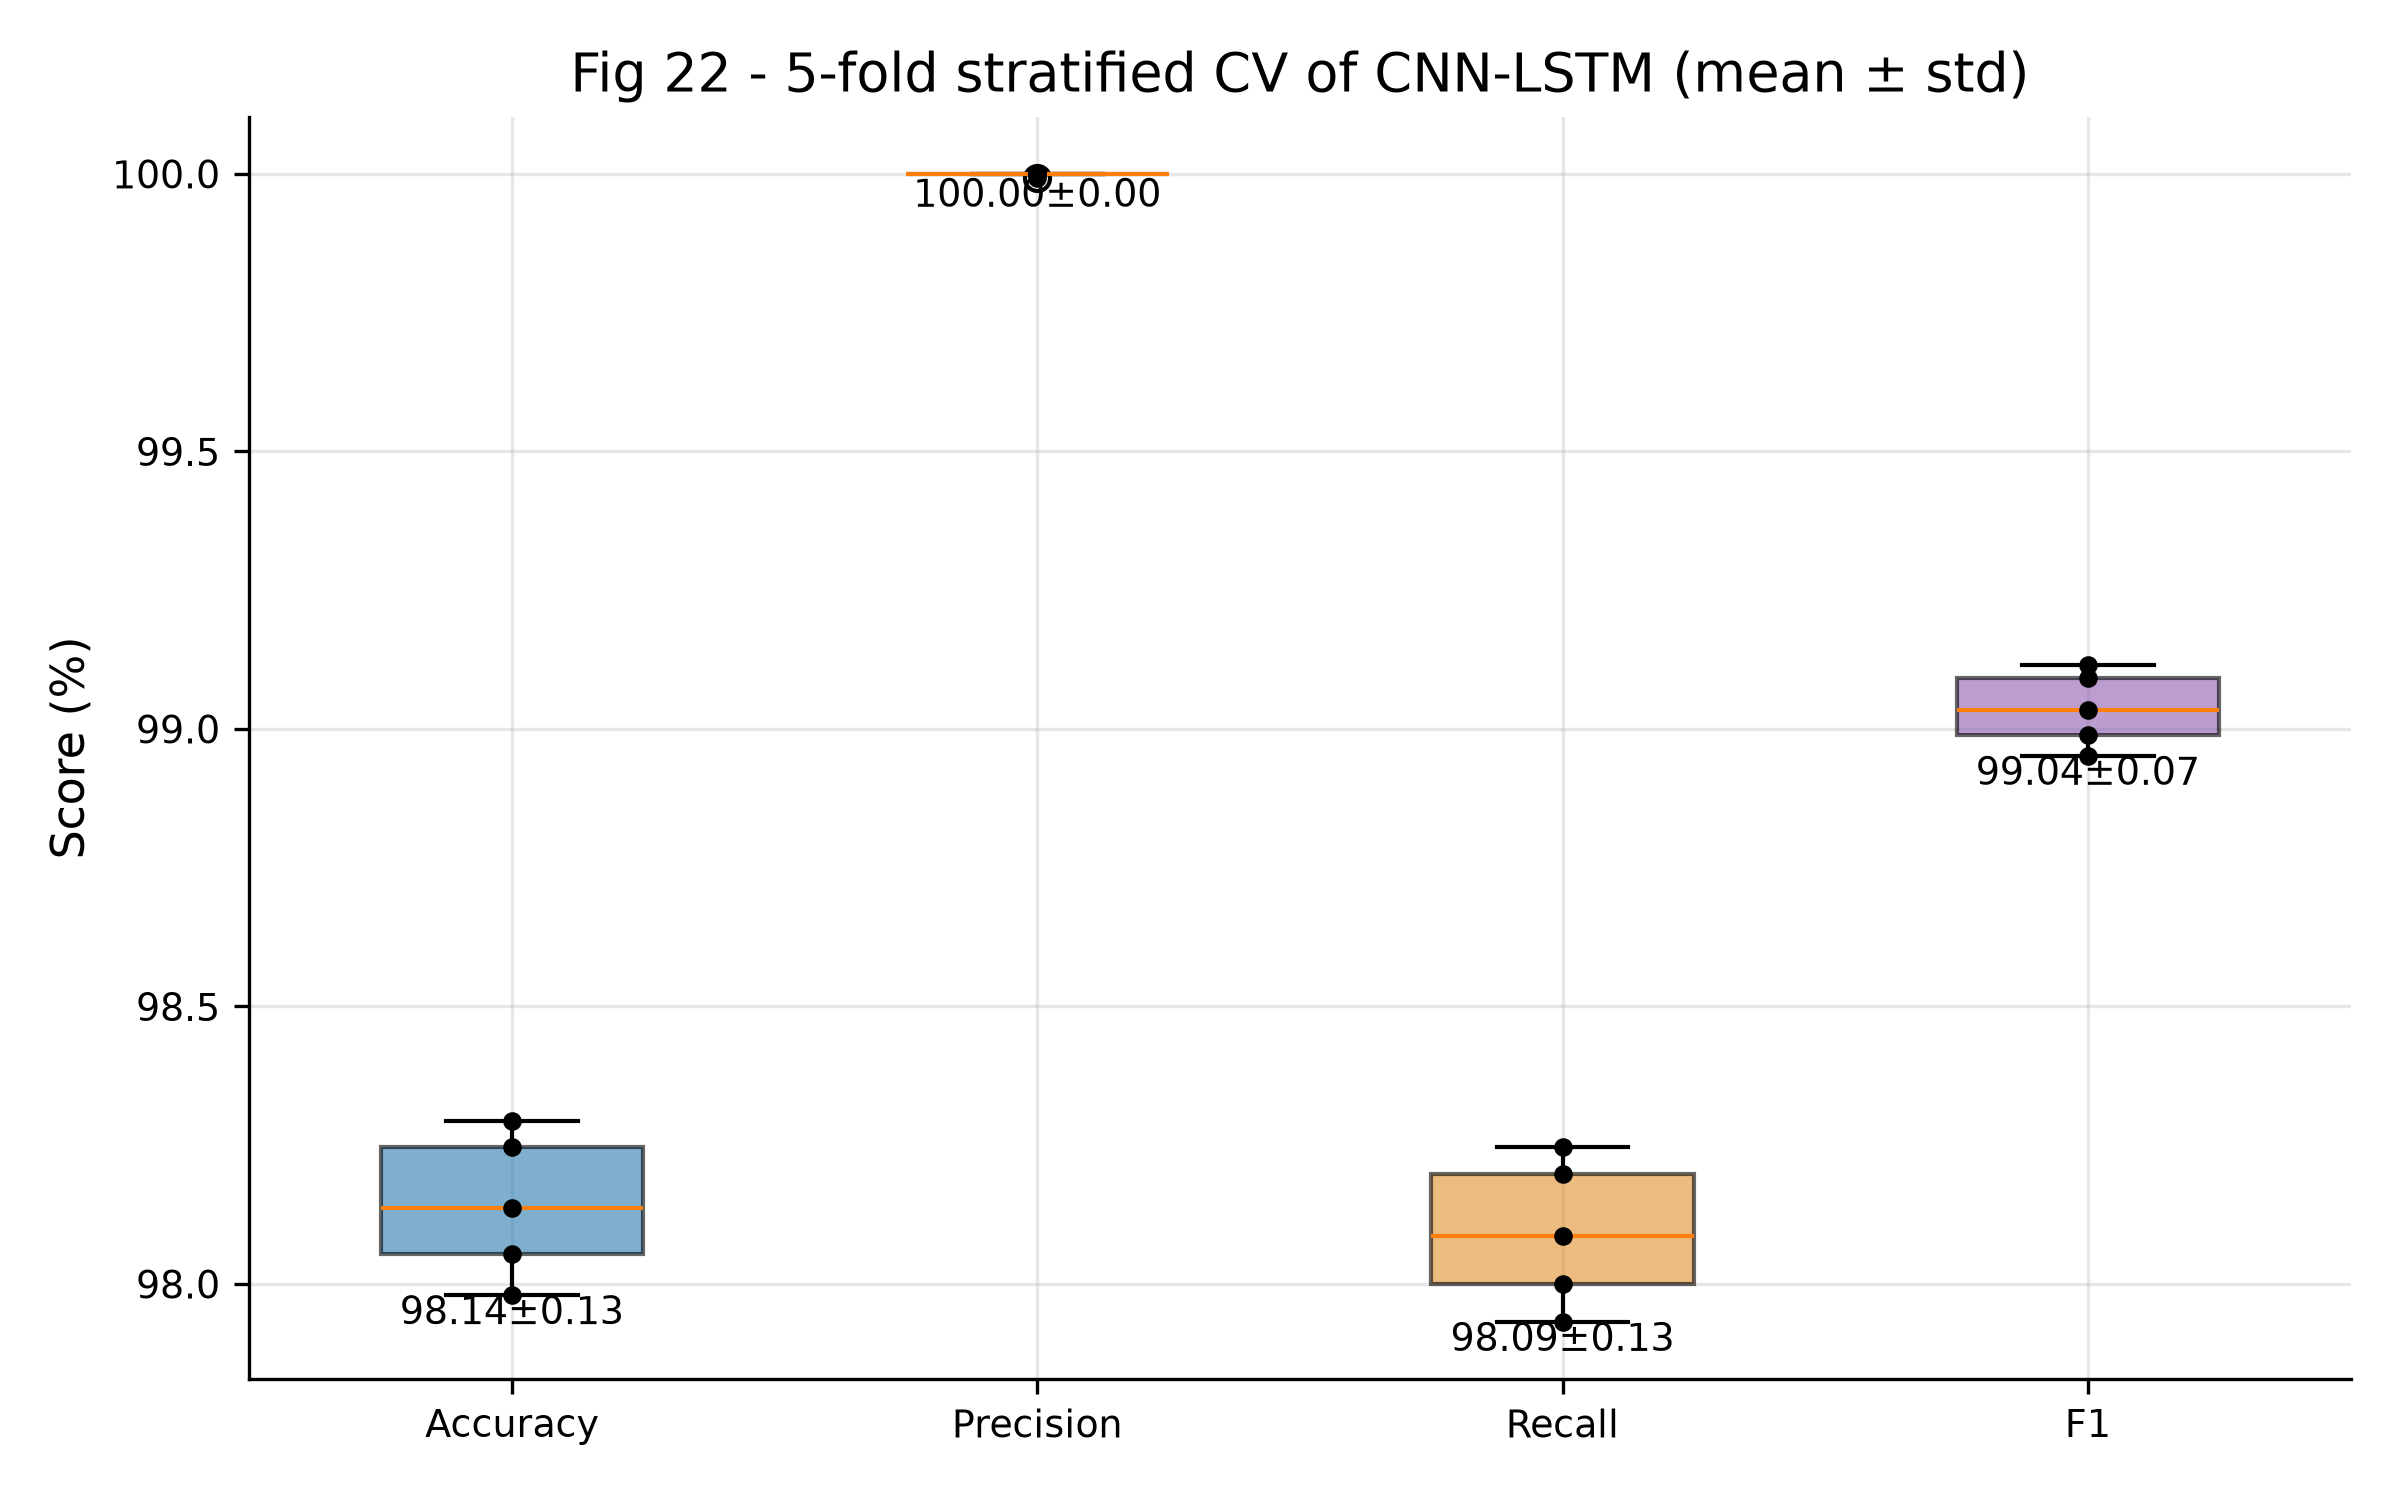

In [18]:
show('20_error_by_attack_type', '21_tsne_lstm_embeddings', '22_cross_validation')

In [19]:
pd.Series({k: v for k, v in results.get('cross_validation', {}).items()})

folds                                                              5
epochs_per_fold                                                    8
rows                                                          150000
accuracy             {'mean': 0.98142, 'std': 0.0013037552599233396}
precision          {'mean': 0.9999860144750183, 'std': 3.12725845...
recall             {'mean': 0.980926349065817, 'std': 0.001318375...
f1                 {'mean': 0.9903641423664677, 'std': 0.00068249...
benign_recall      {'mean': 0.9994981179422837, 'std': 0.00112224...
dtype: object

## 11. Edge deployment (bonus, Fig 23)

In [20]:
p = OUT / 'metrics' / 'edge_benchmark.md'
display(Markdown(p.read_text())) if p.exists() else print('edge stage not run')

| variant                   |   size_mb |   ms_per_sample |   accuracy |   accuracy_drop_pp |
|:--------------------------|----------:|----------------:|-----------:|-------------------:|
| Keras float32 (GPU)       |    1.0428 |         15.2625 |     0.9875 |             0.0000 |
| TFLite float32            |    0.4195 |          0.0844 |     0.9875 |             0.0000 |
| TFLite dynamic-range int8 |    0.1967 |          0.0374 |     0.9876 |            -0.0050 |

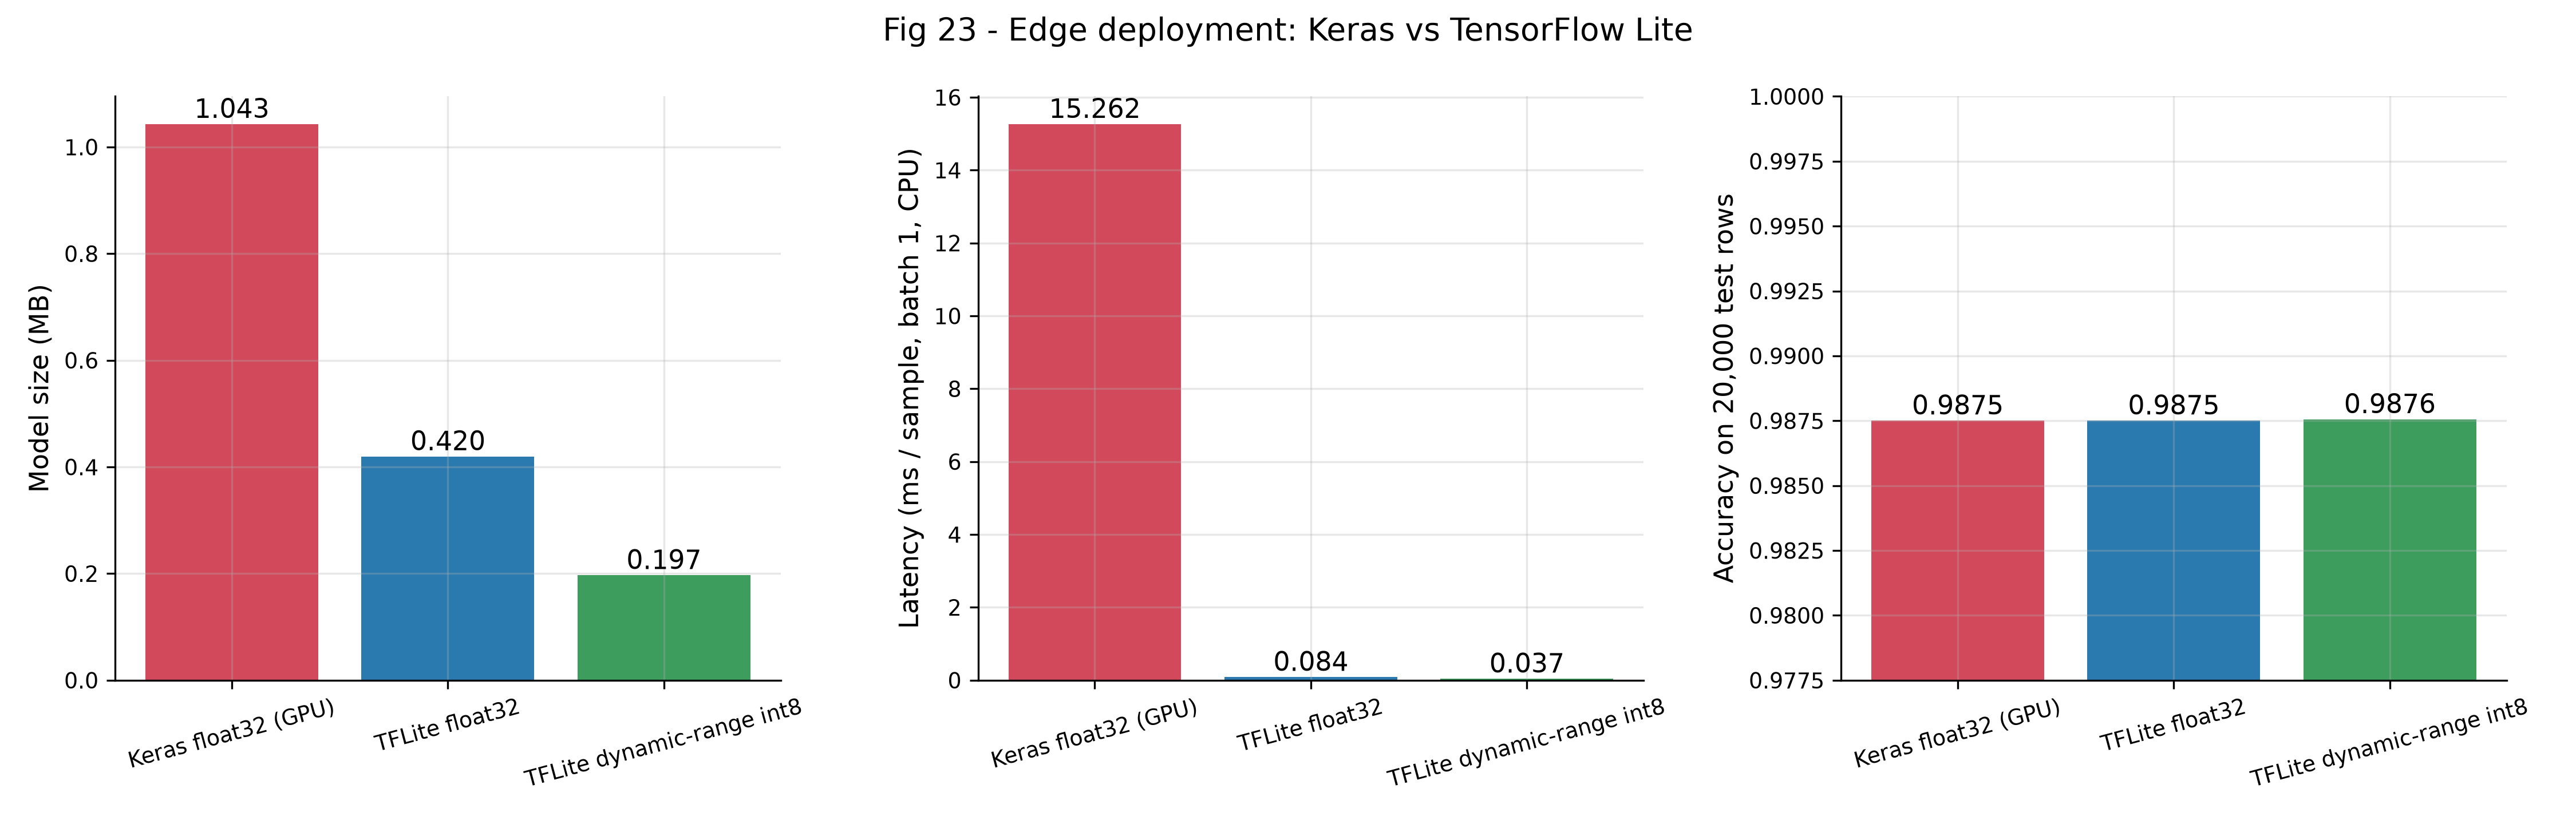

In [21]:
show('23_edge_tflite_benchmark')

## 12. Slide-ready figures (16:9)

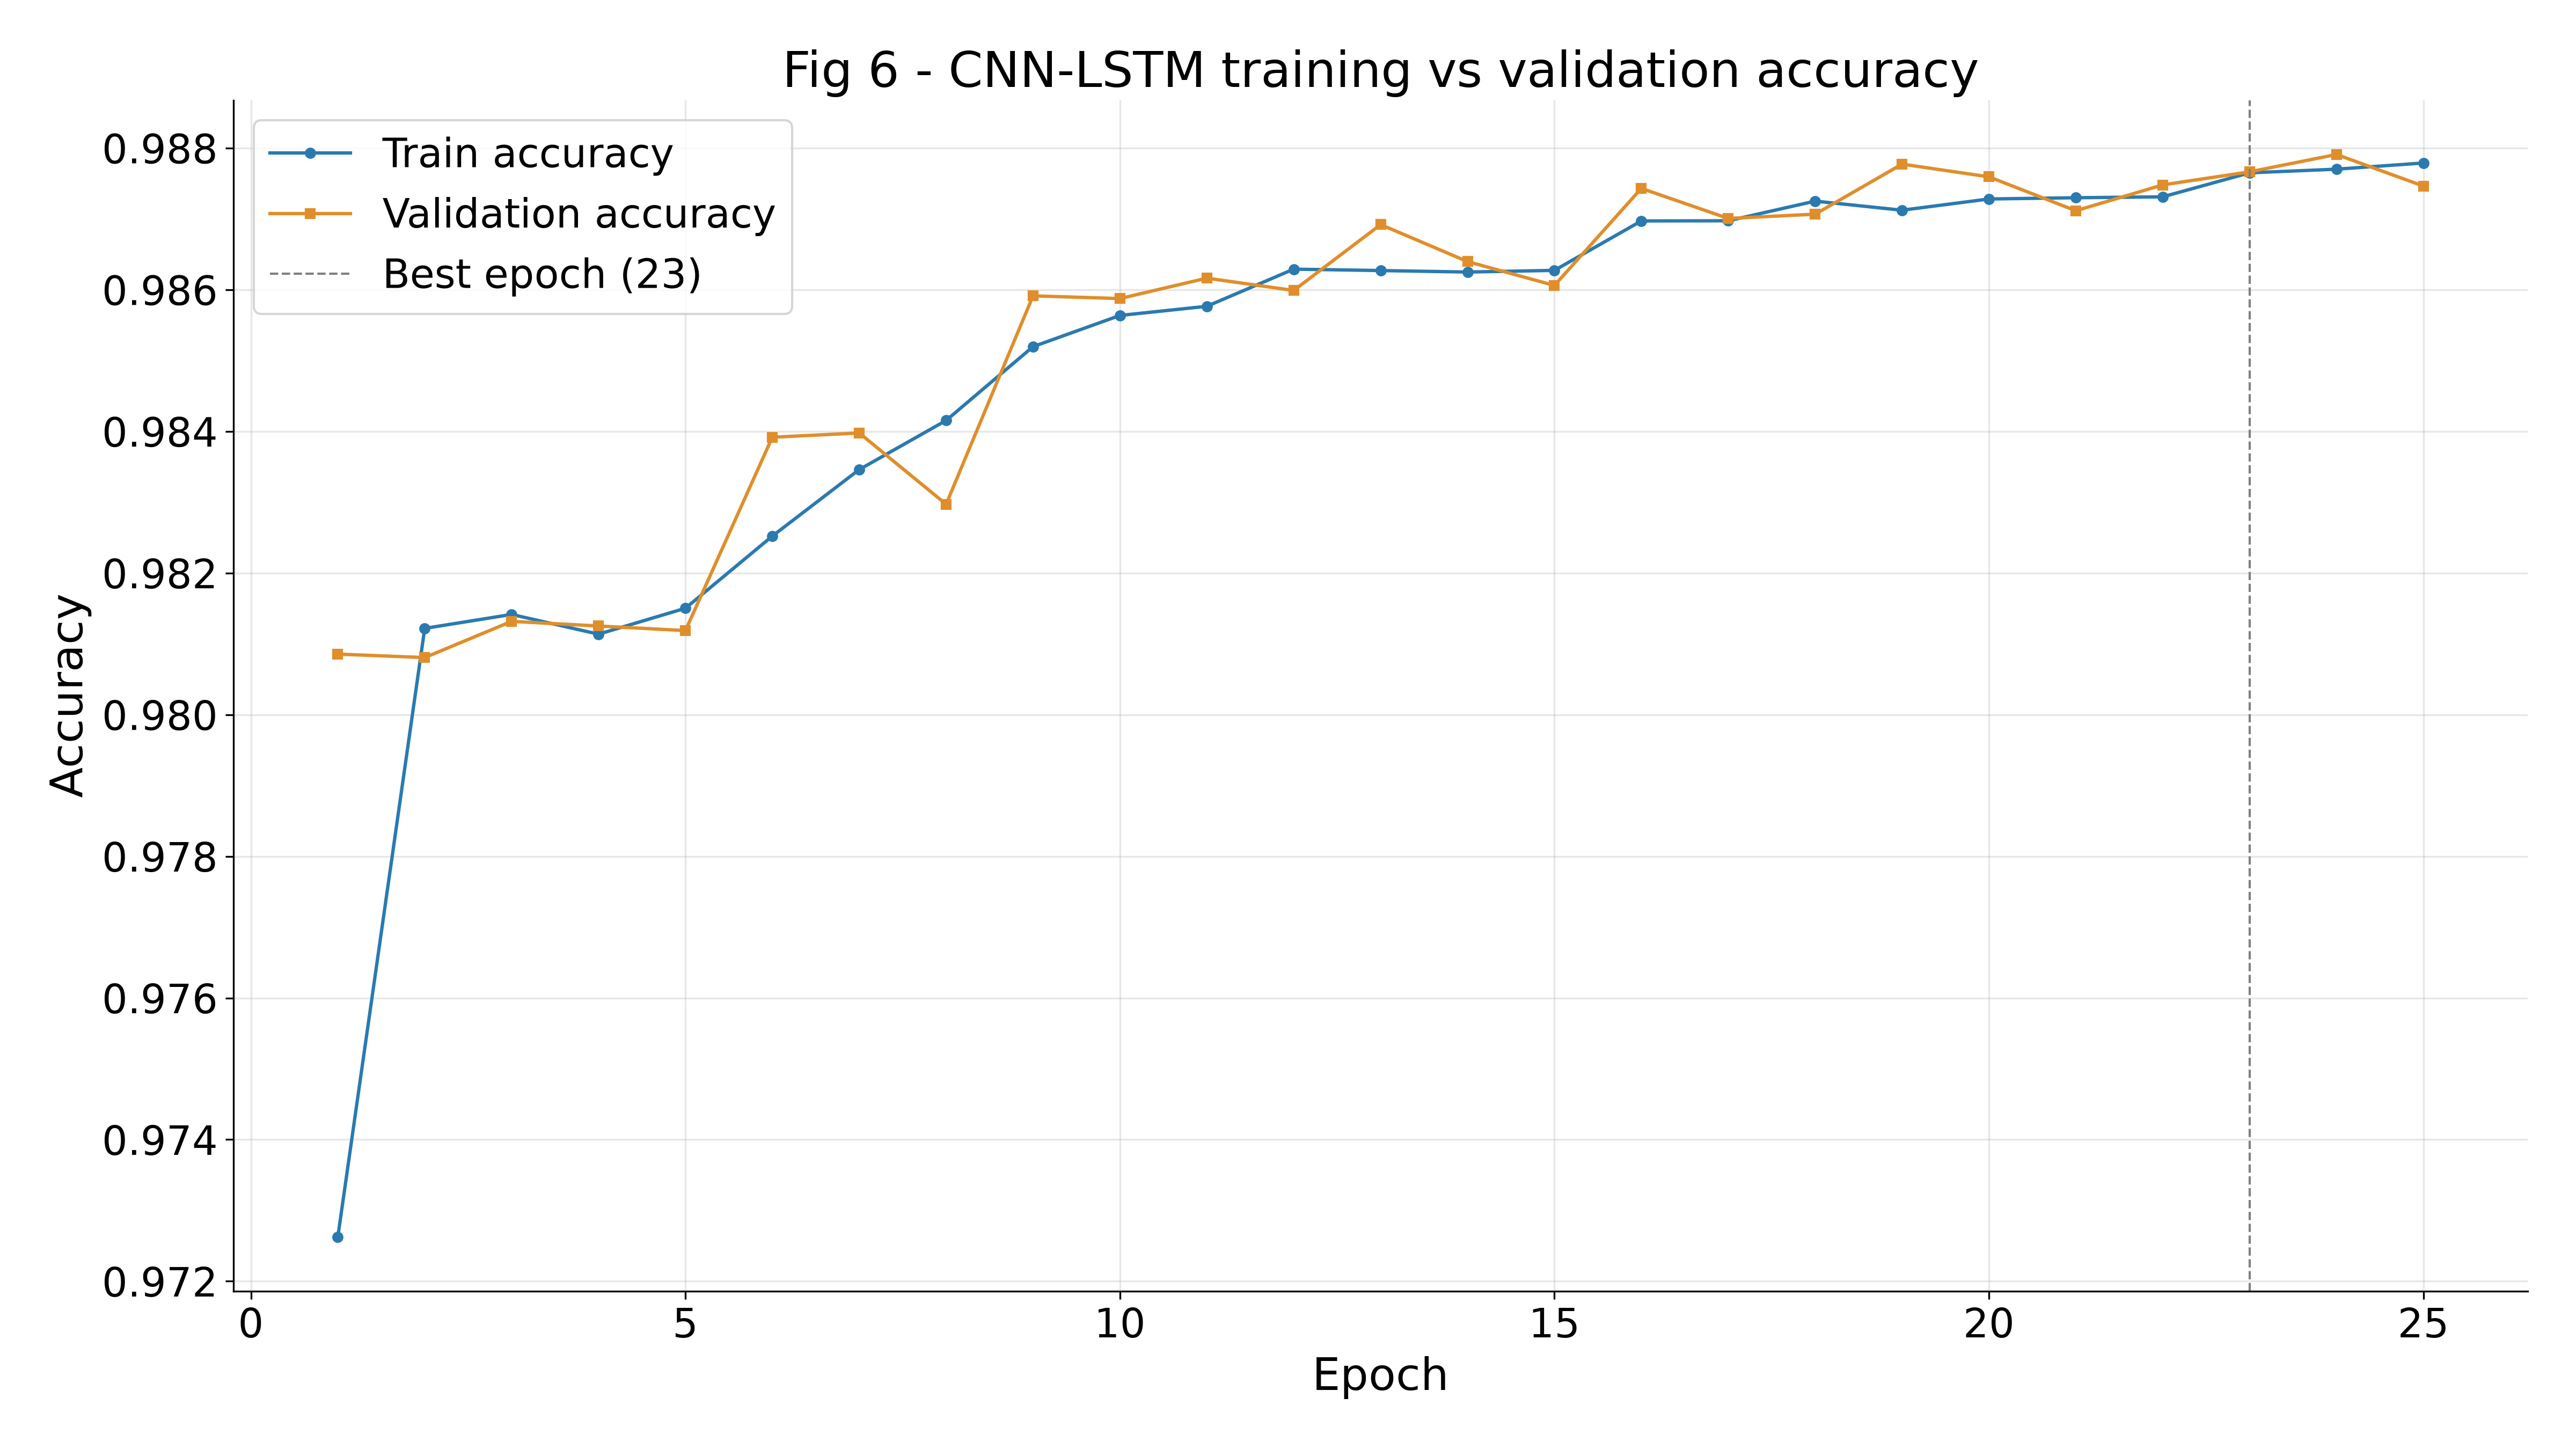

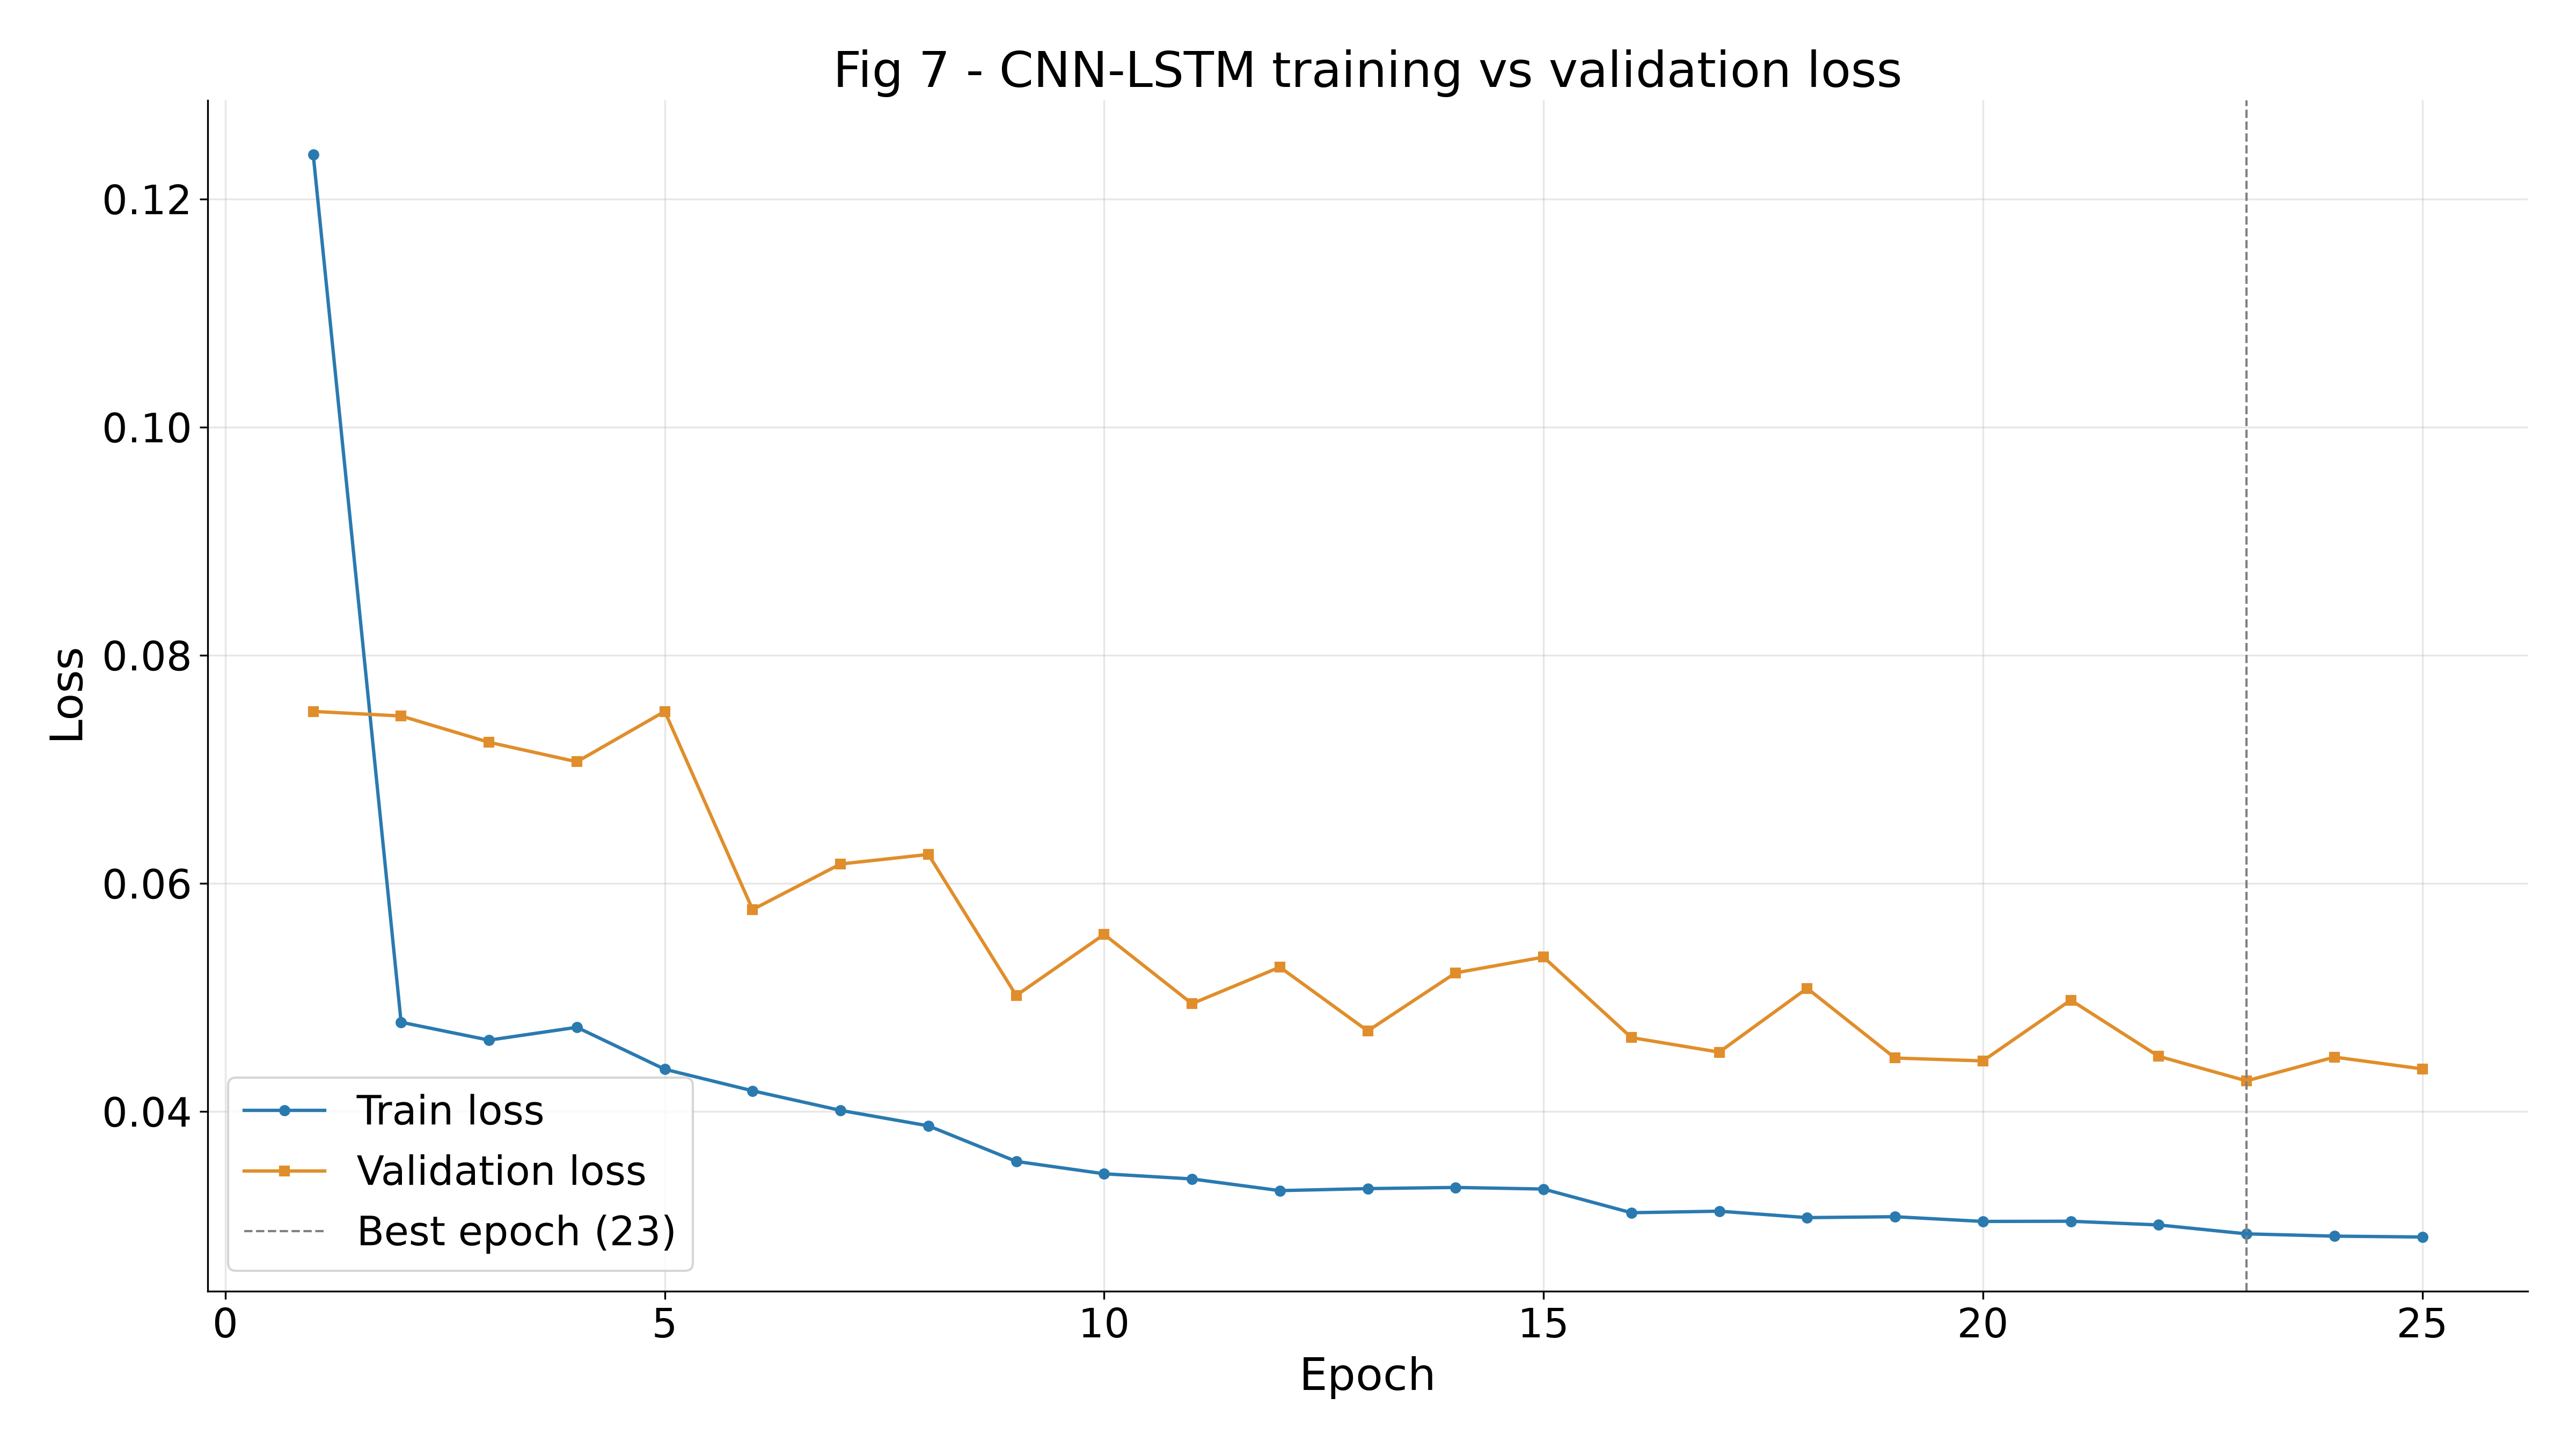

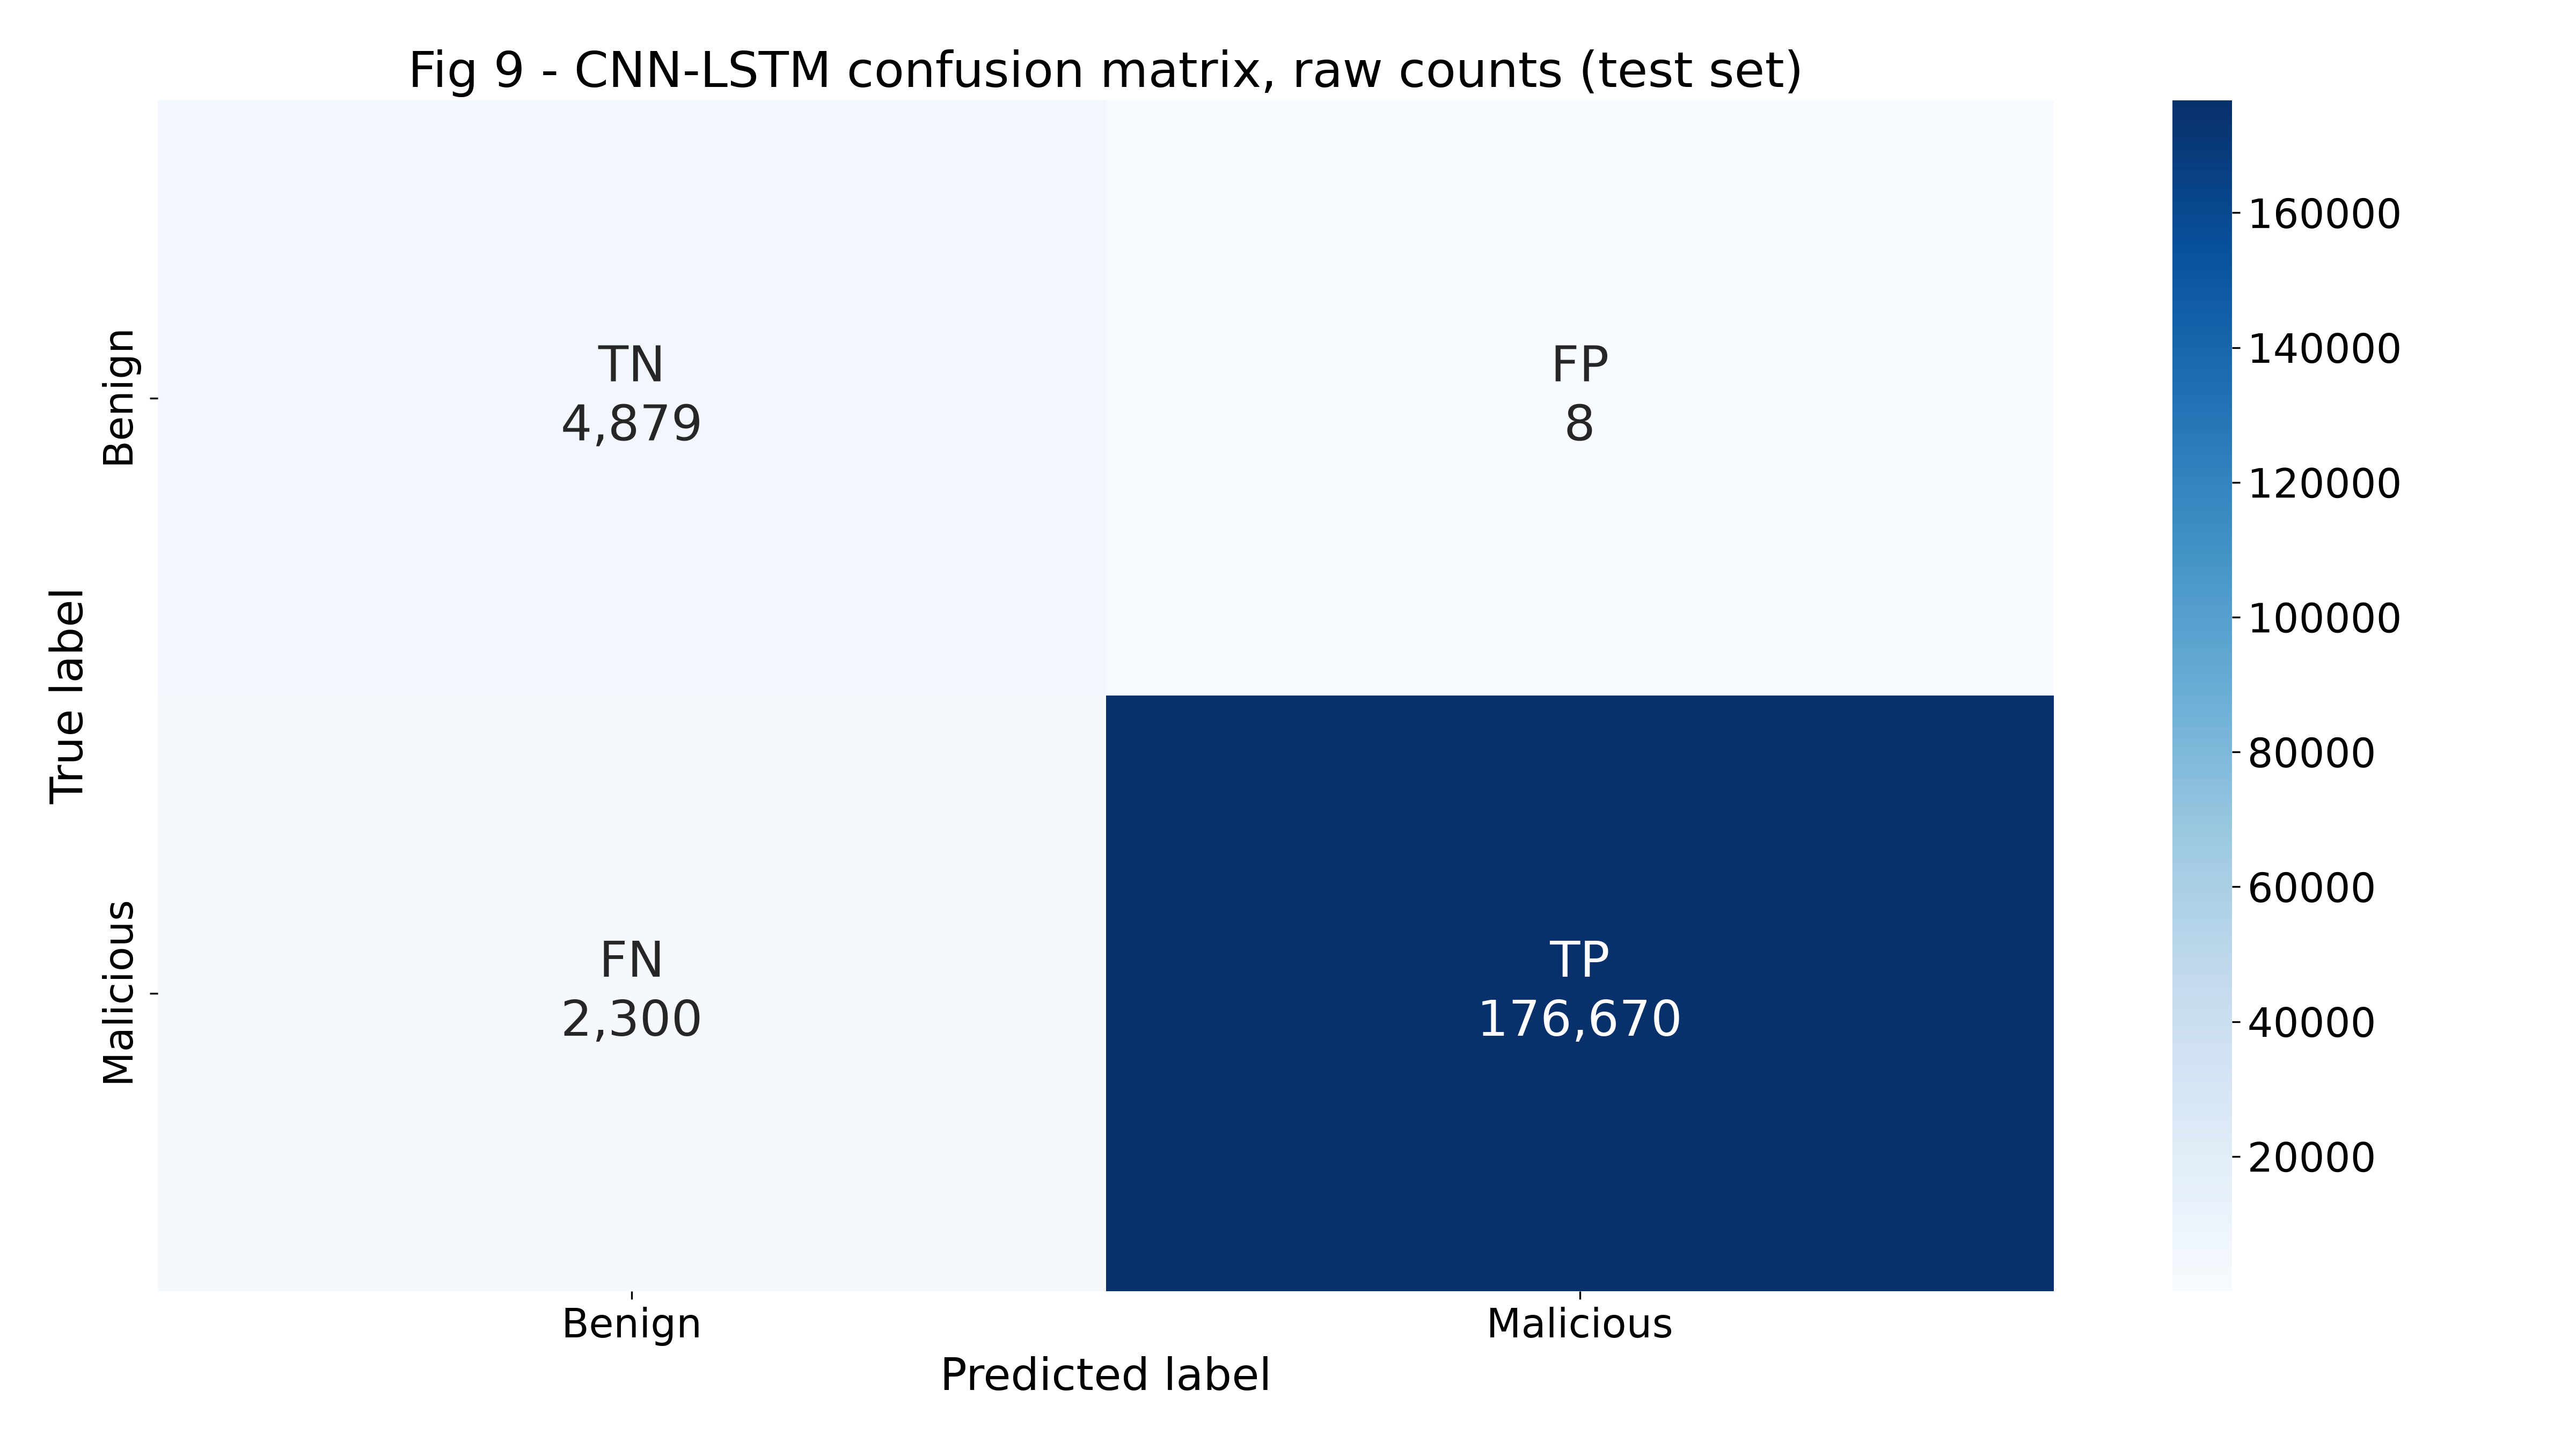

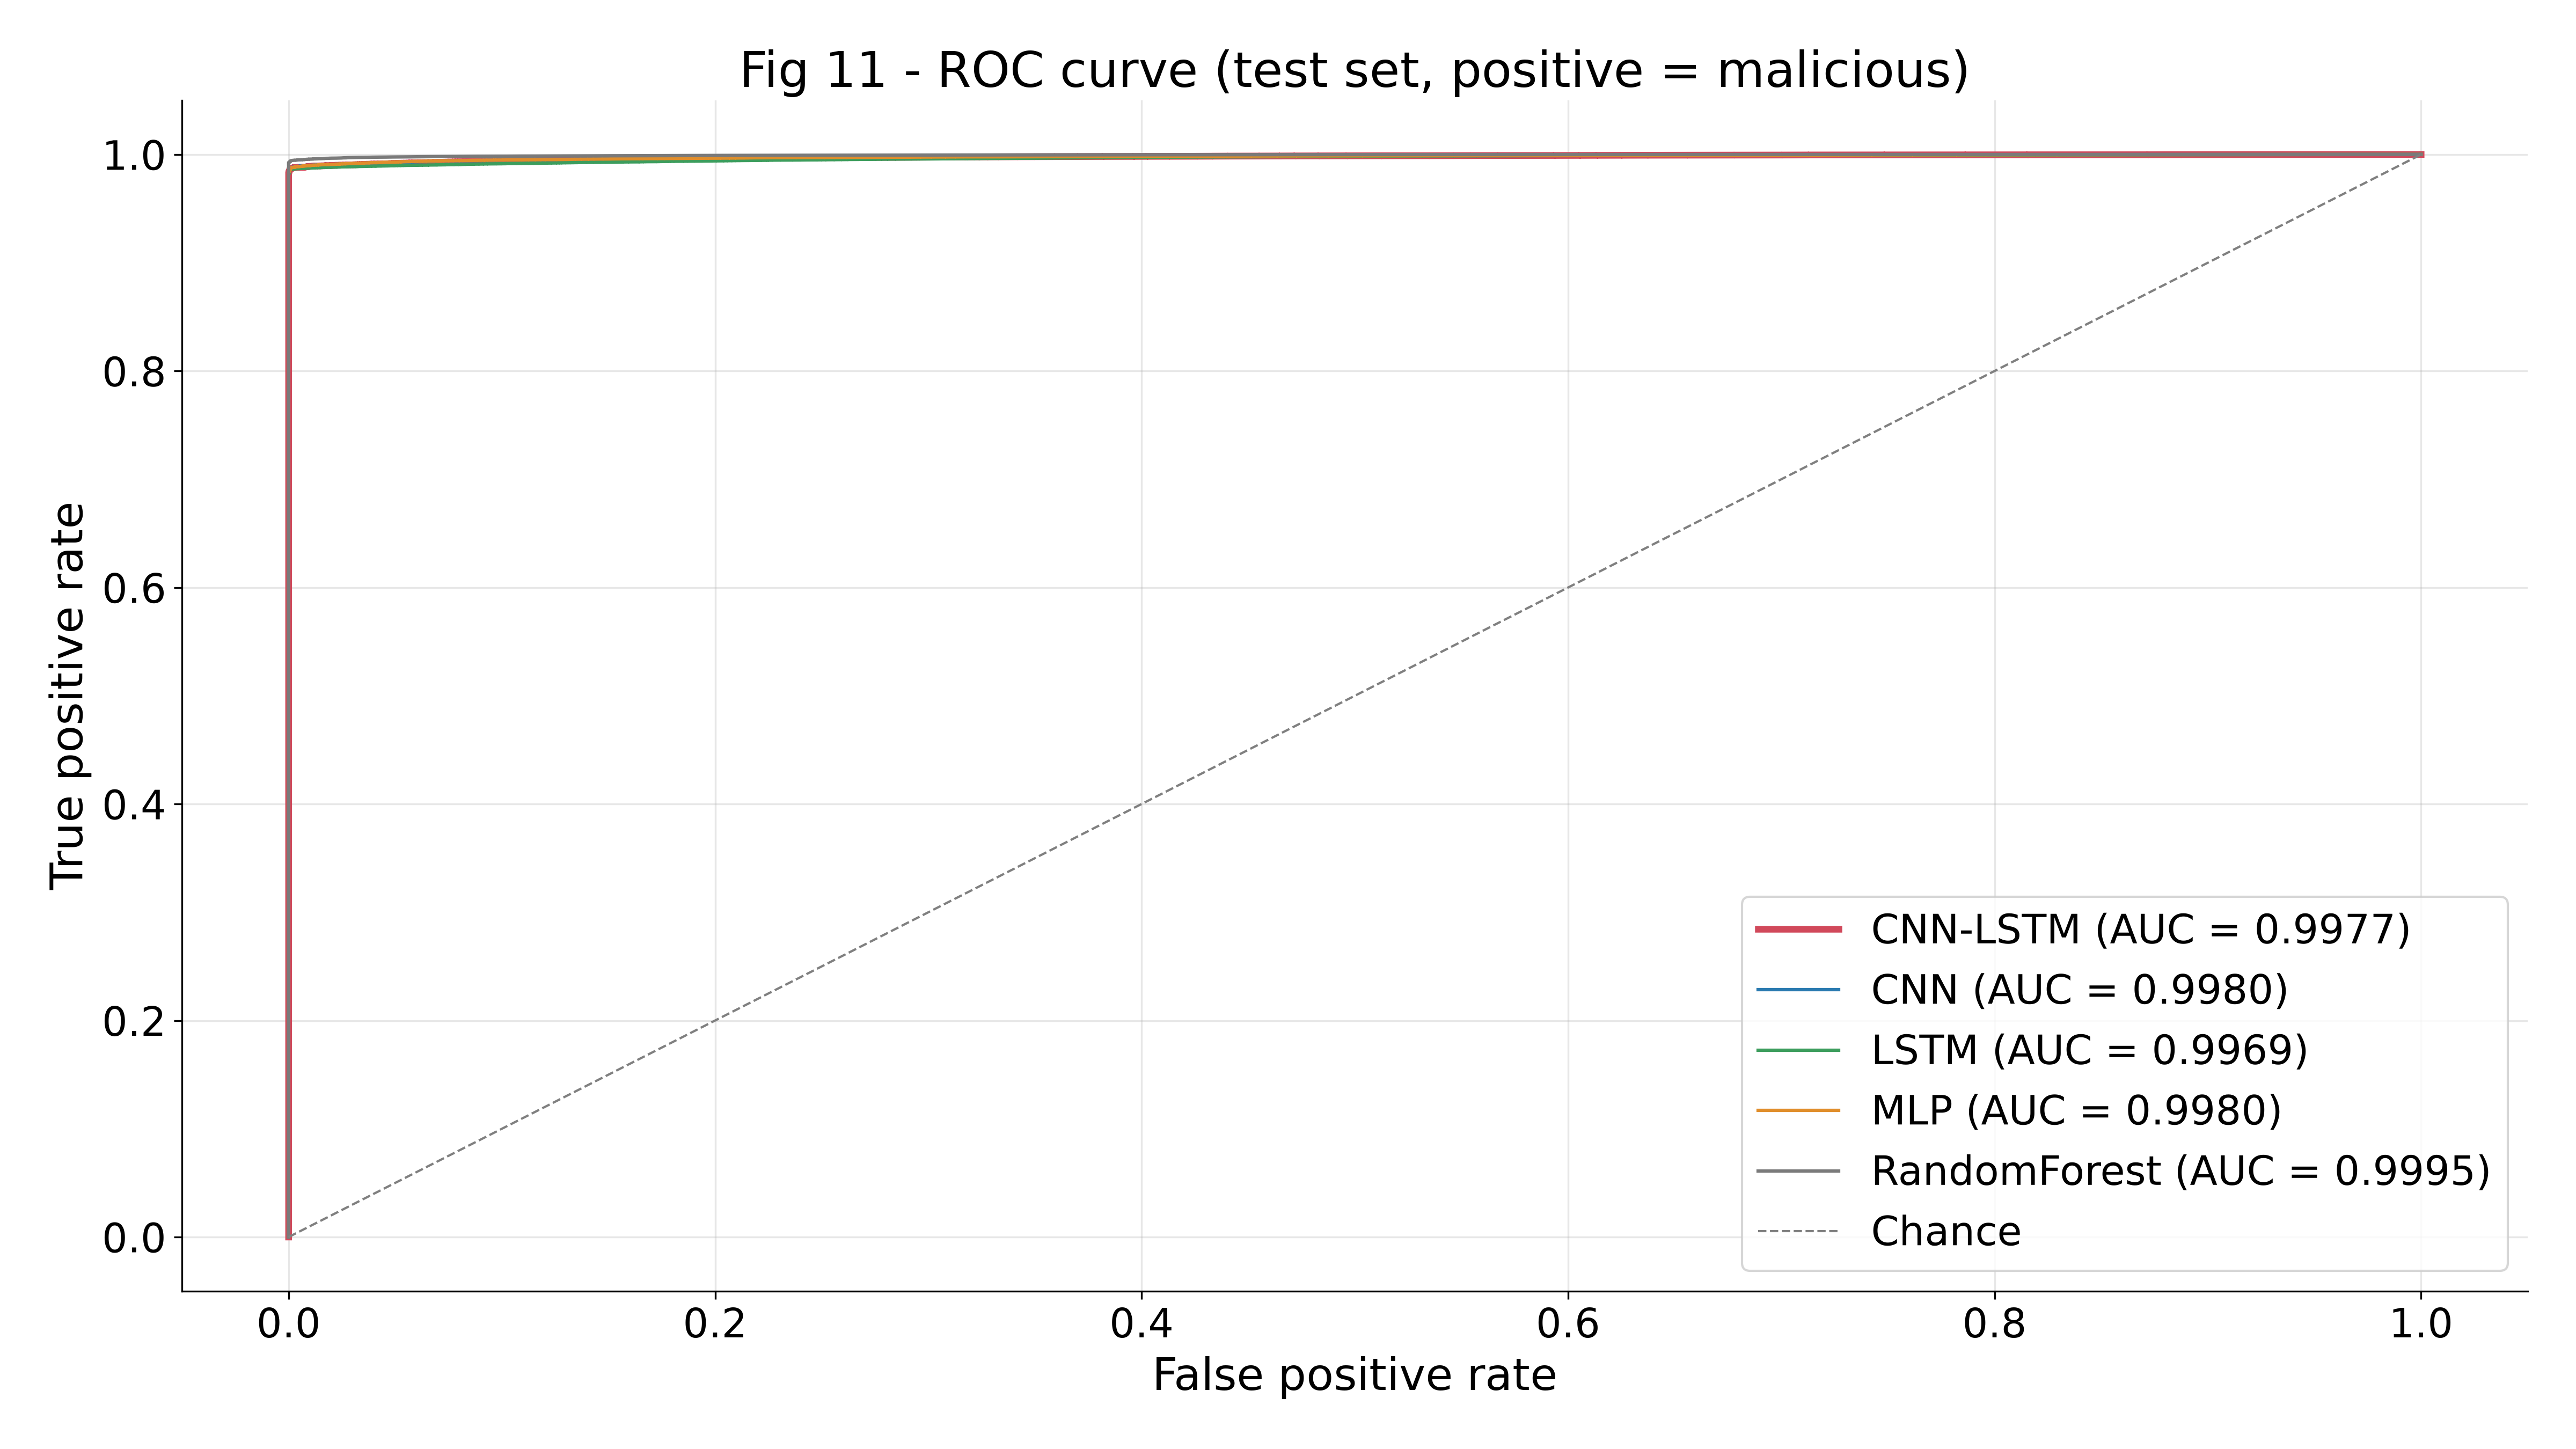

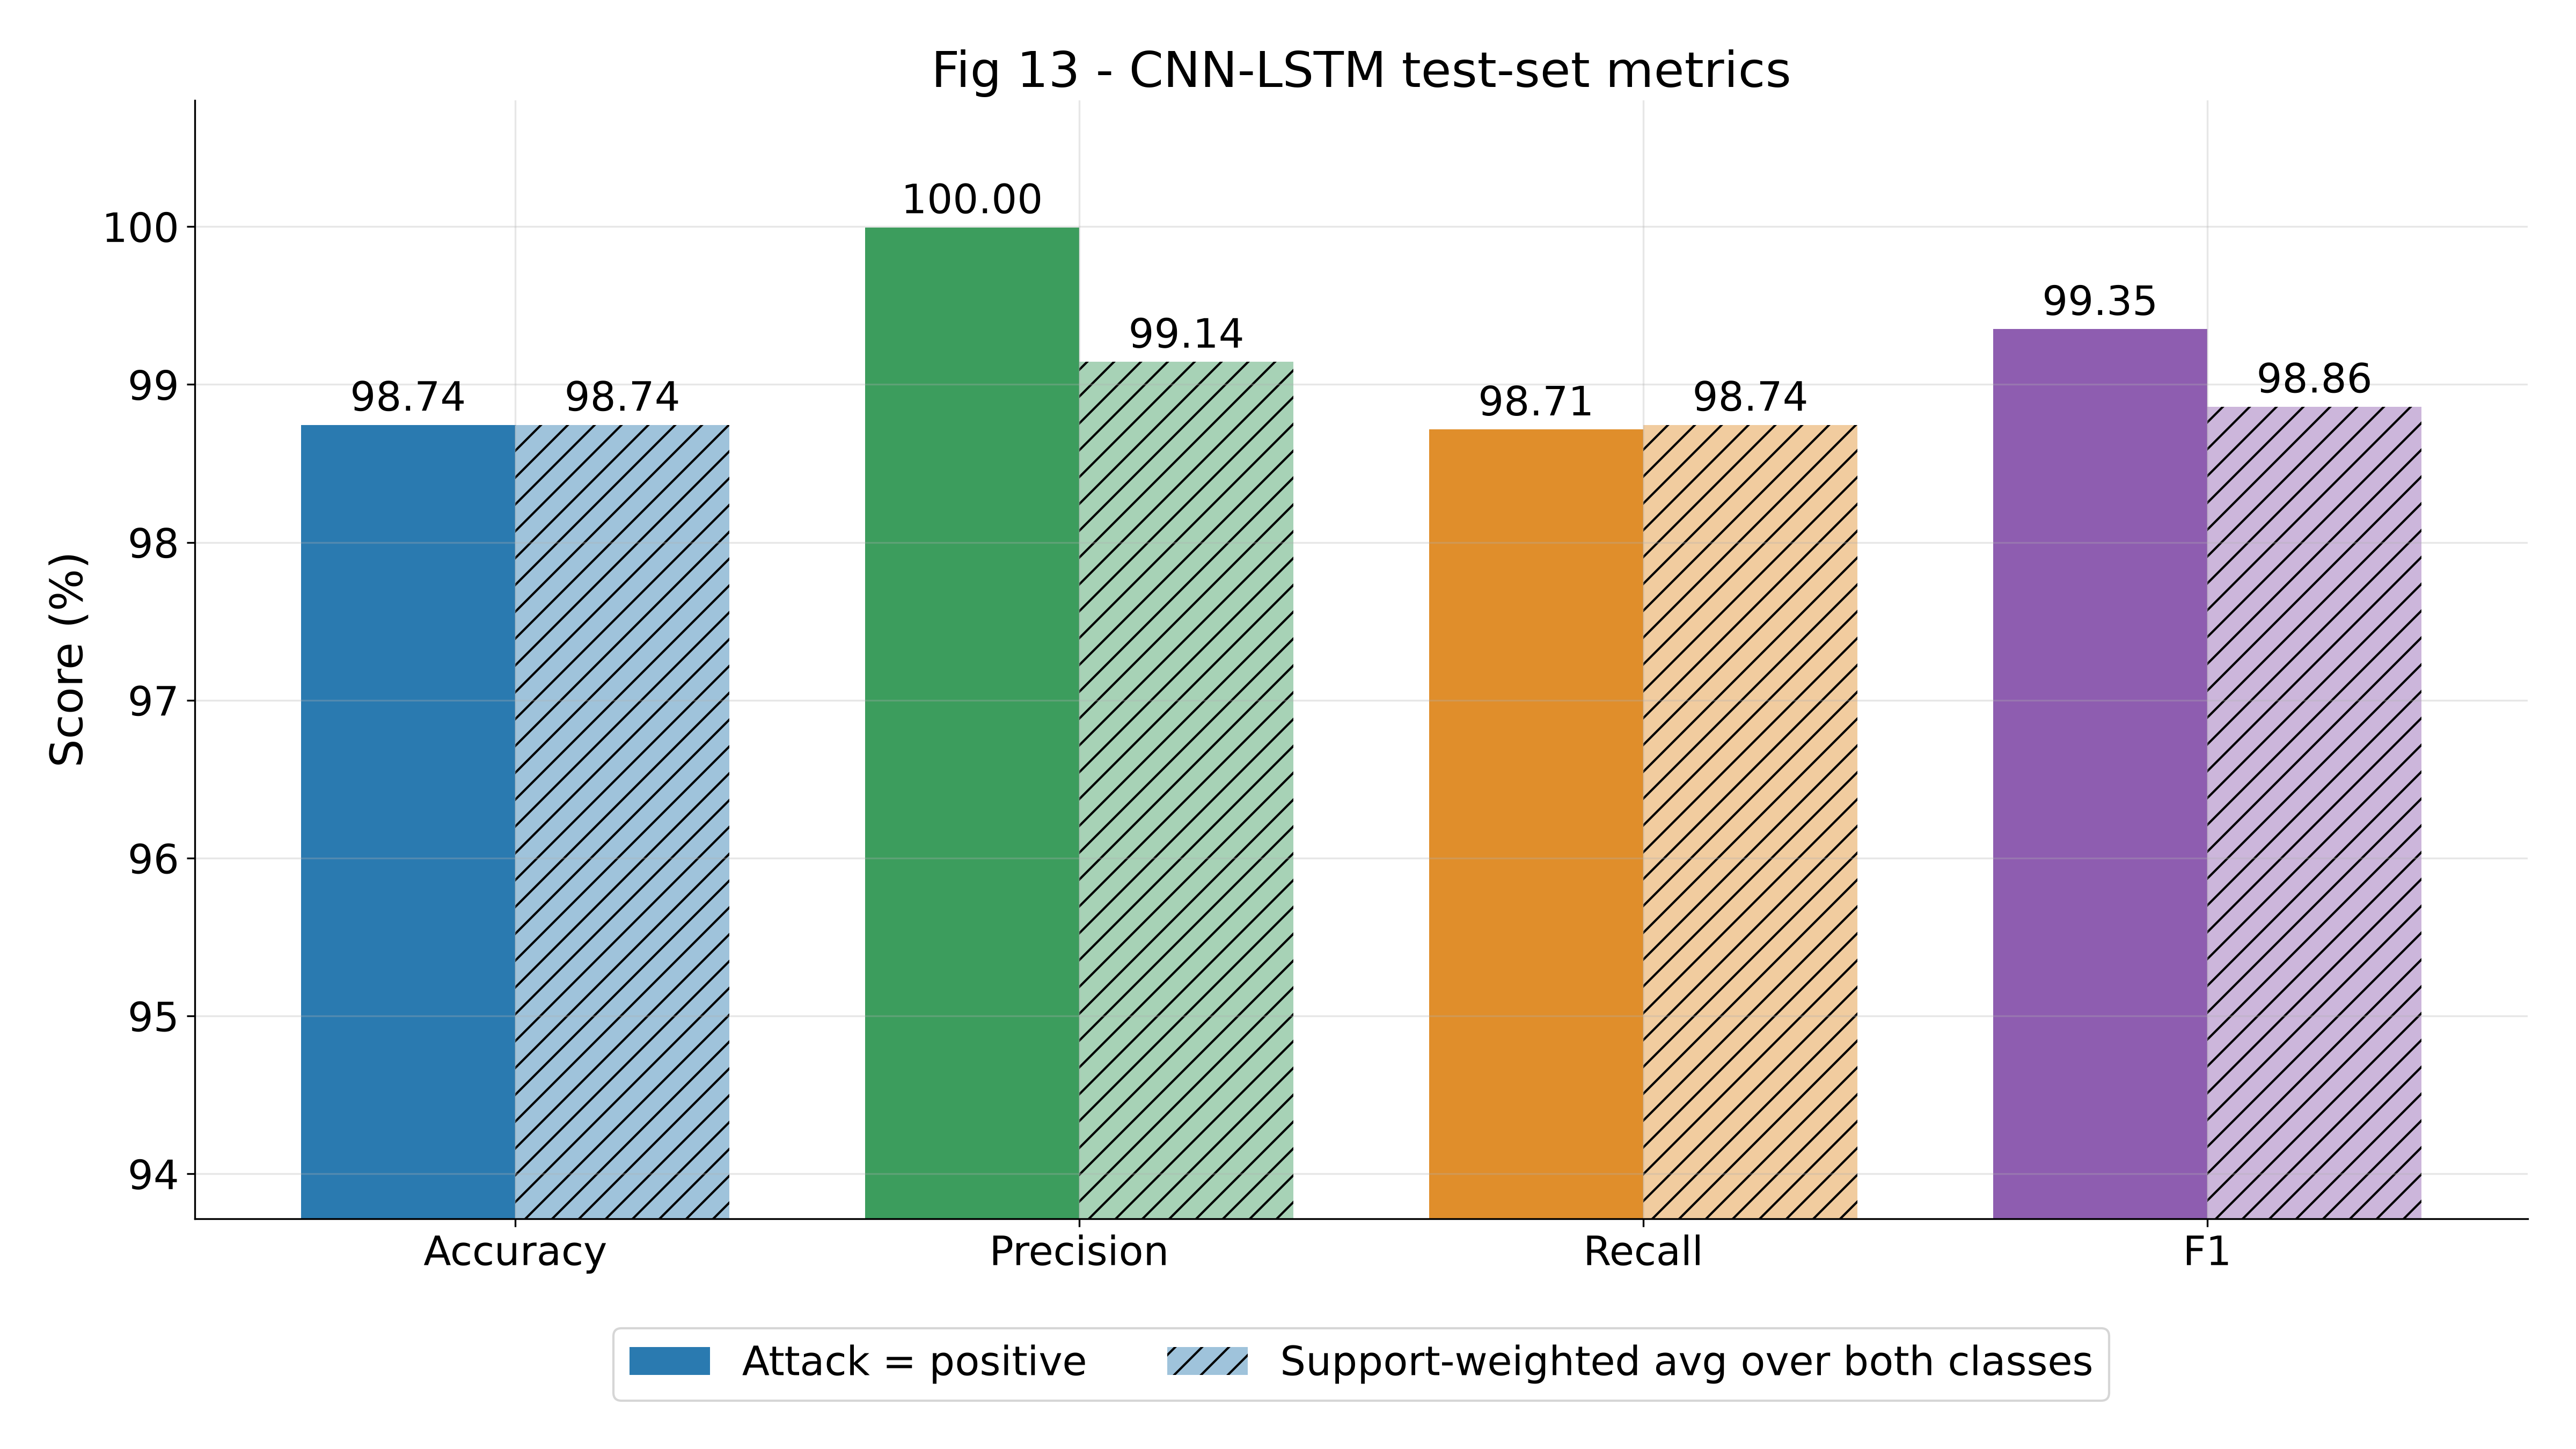

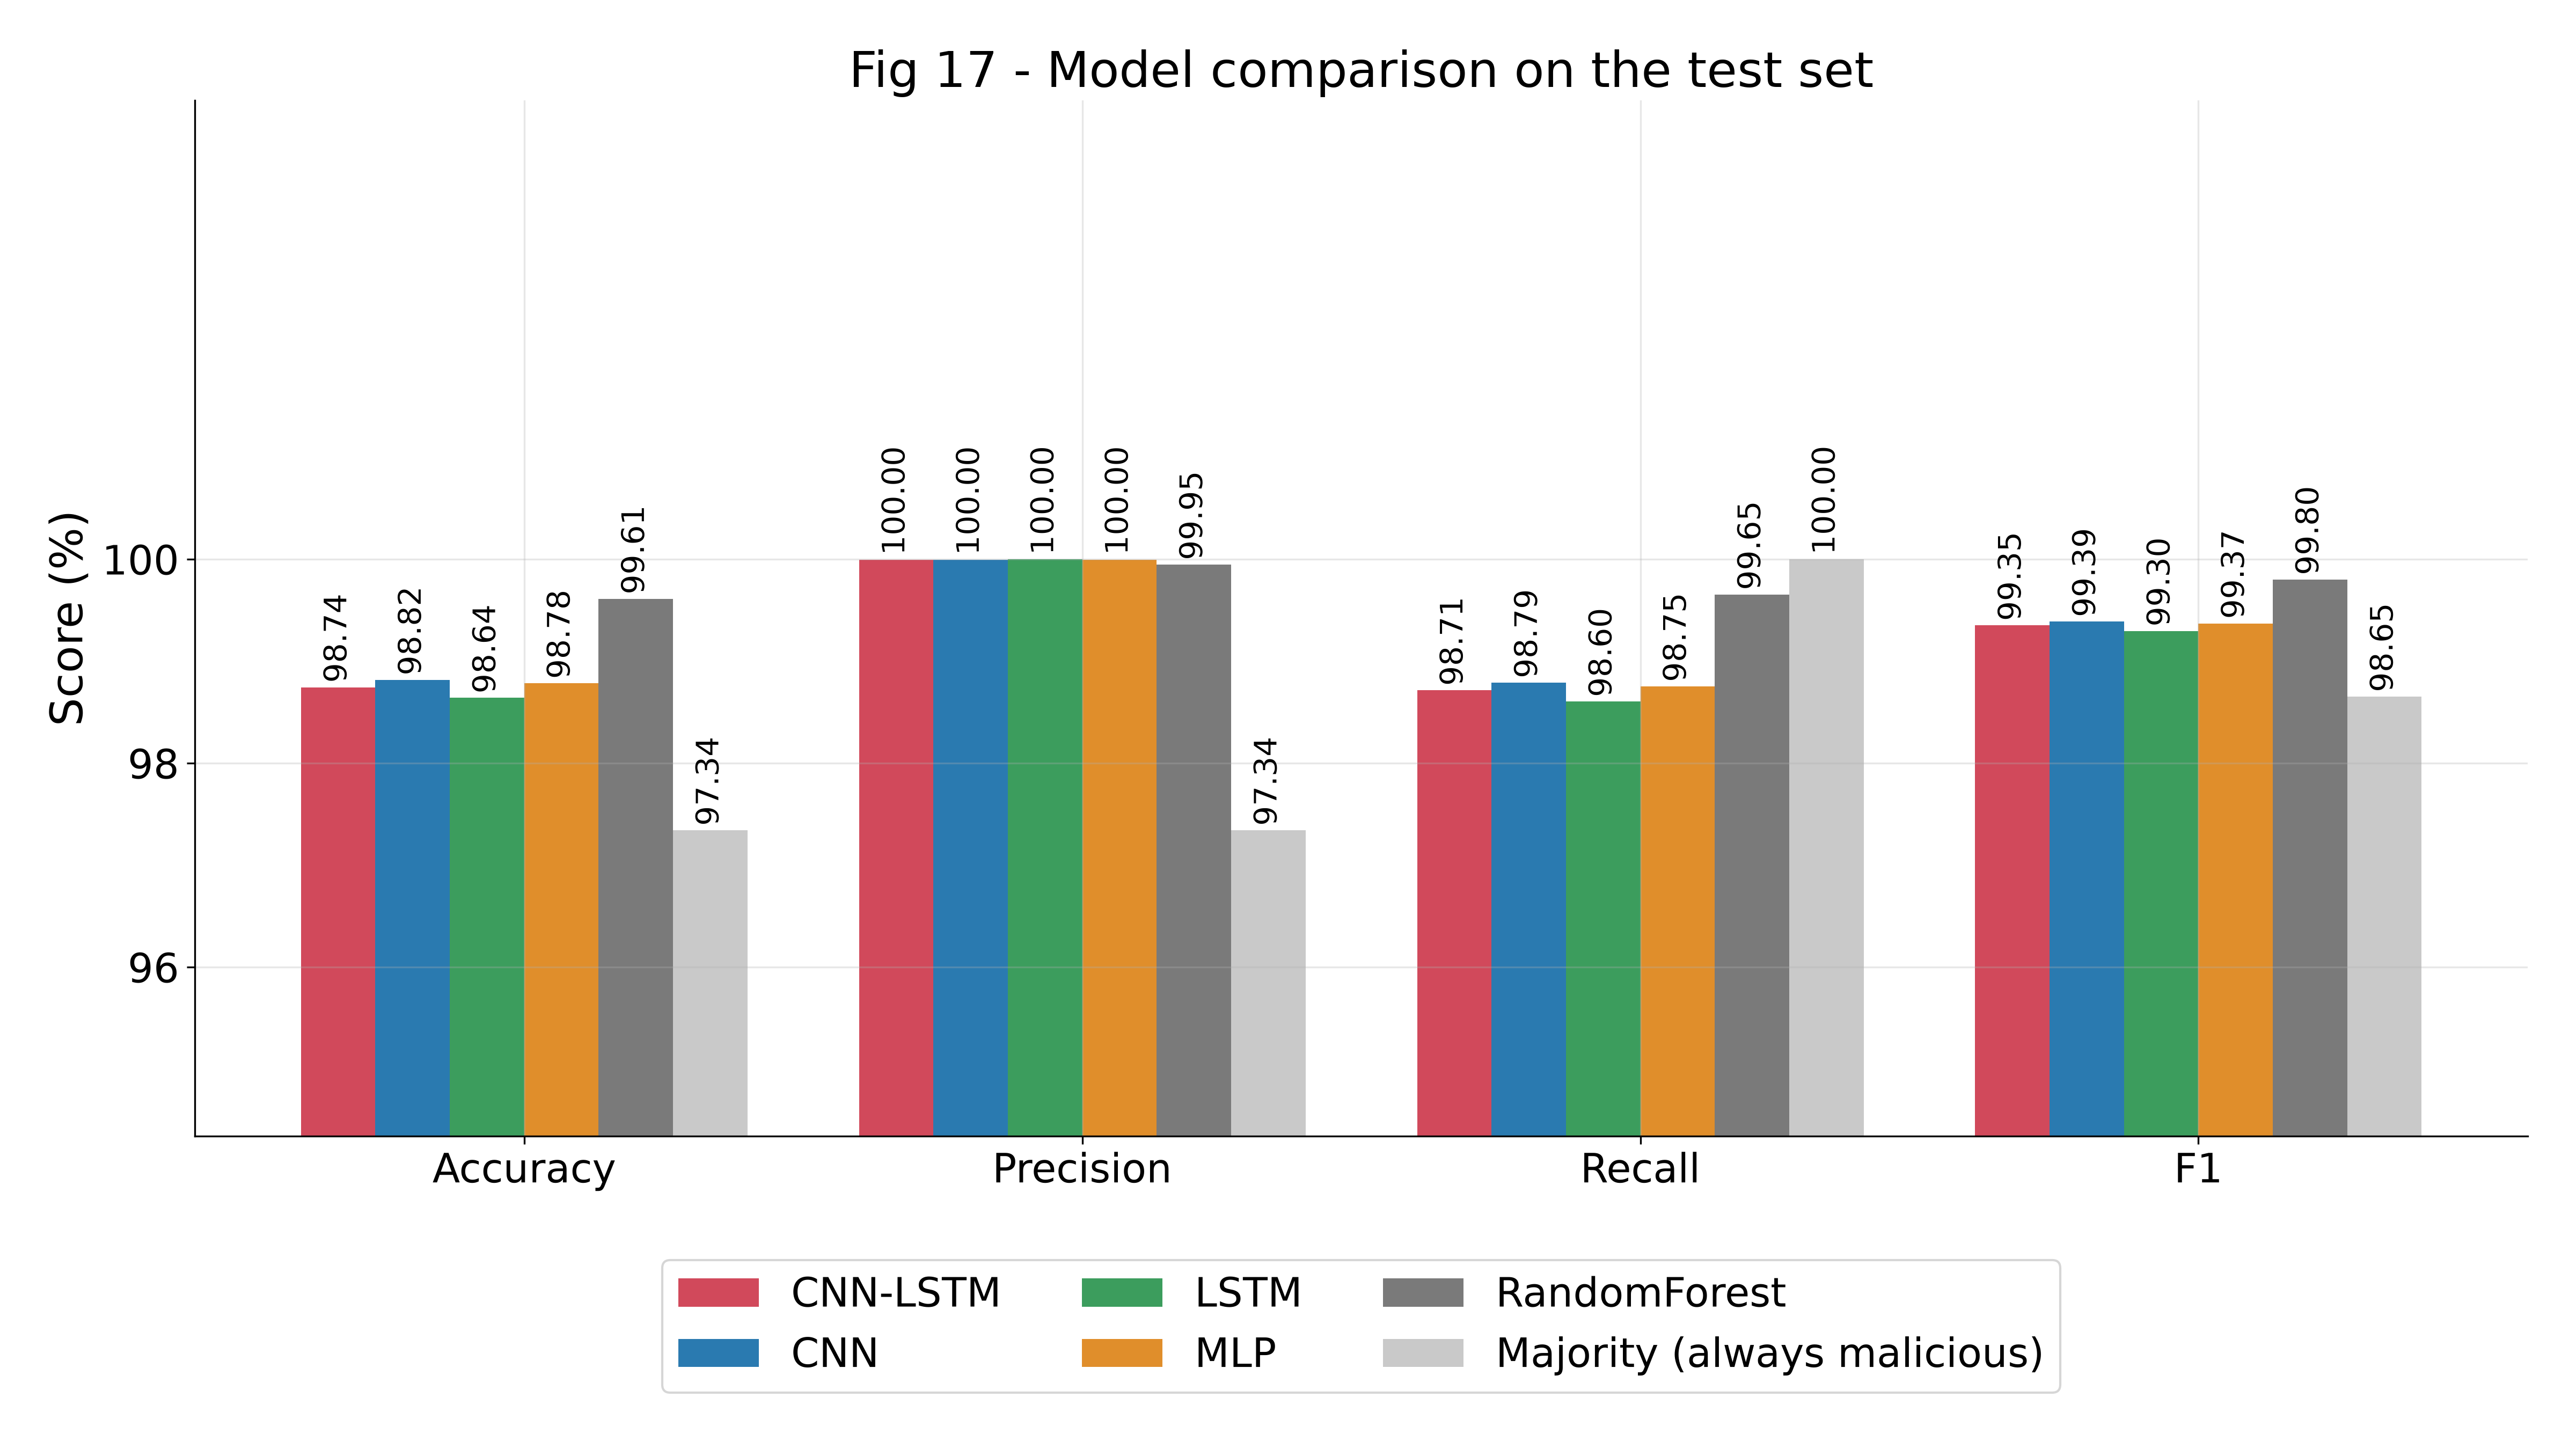

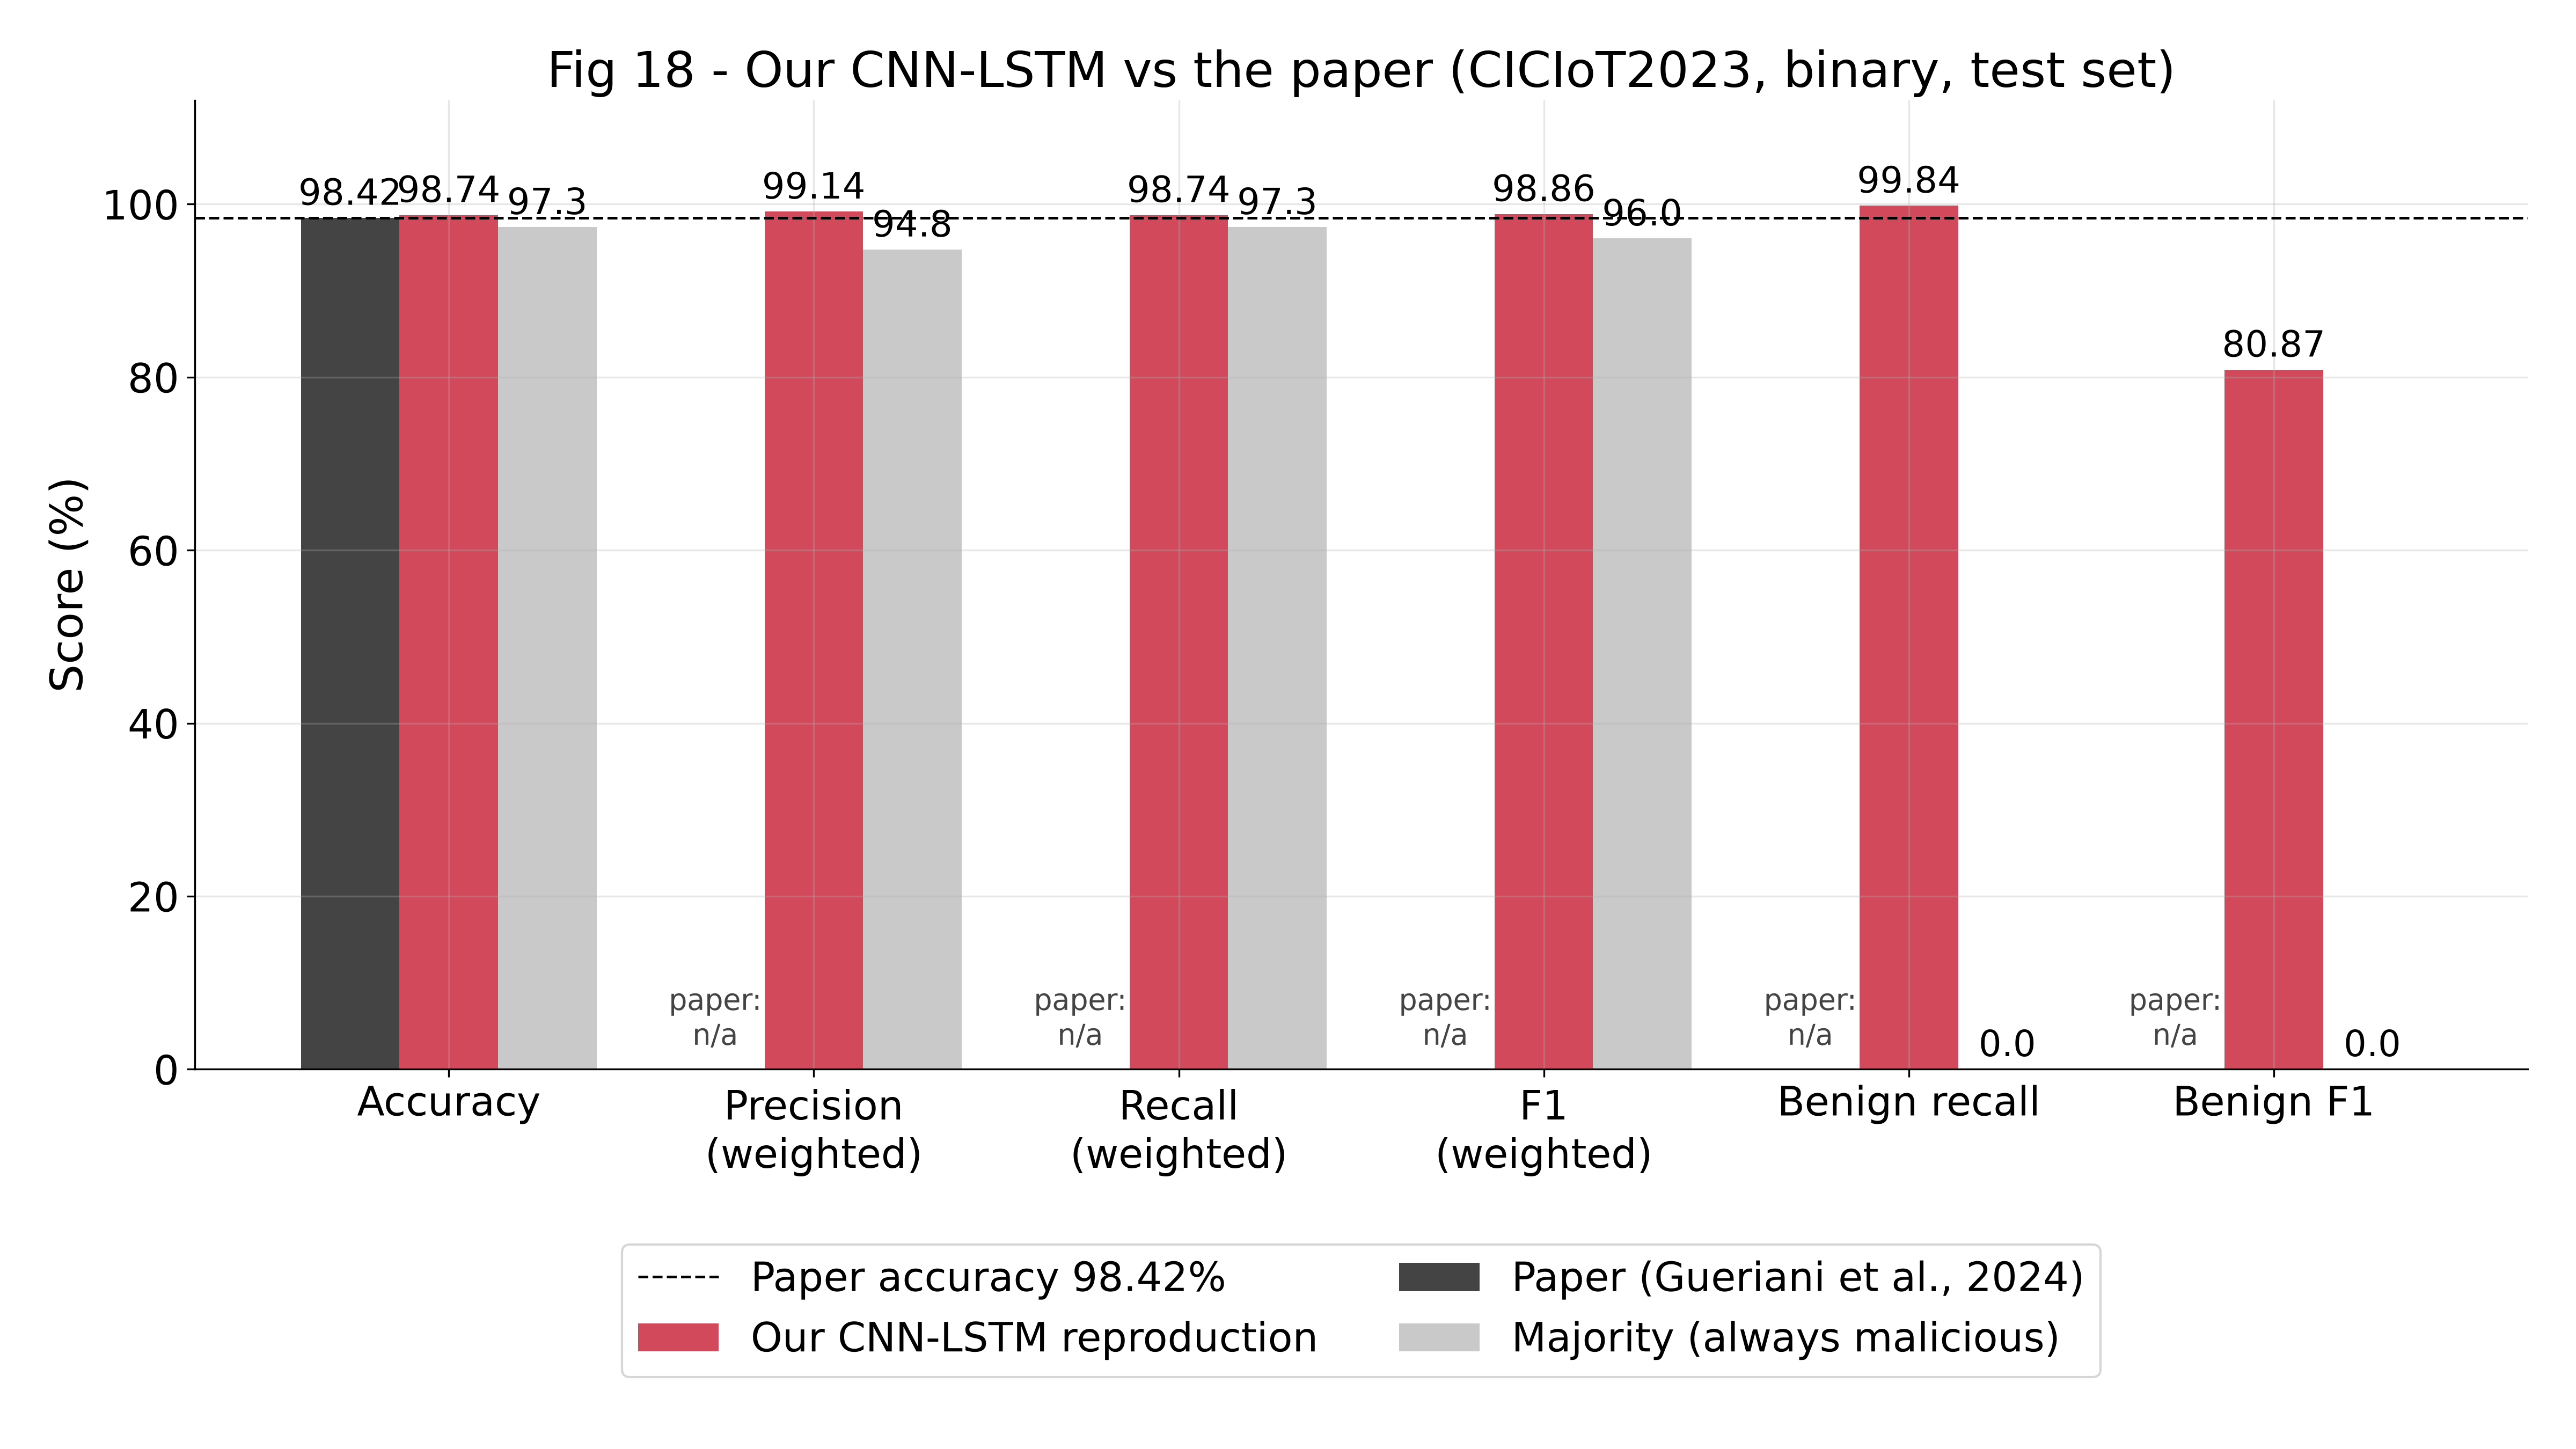

In [22]:
for p in sorted((OUT / 'figures' / 'slides').glob('*.png')):
    display(Image(filename=str(p), width=700))